# LSE | Insight Nexus x Bank of England | Employer Project | Final Notebook

This notebook contains all of the code used to conduct the full end to end analysis of the project. It includes visualisations and describes the justifications behind them with clear markdowns in-between code blocks. Each group of blocks is defined with headings and sub-headings and cover the following topics:
- Preliminary sentiment analysis using the Loughran McDonald (LM) dictionary
- VADER sentiment analysis of speeches dataset for all Central Banks
- FinBERT sentiment analysis of BoE speeches dataset
- Full regression analysis of Sentiment vs Key Variables
- Financial Stability, Inflation and Monetary Policy Report sentiment analysis using LM and VADER
- MPC Voting Analysis
- LDA (Latent Dirichlet Allocation) Topic Modelling for communications during GFC and COVID

Link to GitHub repo: https://github.com/tobiajenifuja/BoE-Group-6

<div class="alert alert-block alert-danger">
Need to import all necessary libraries in one block. Will combine later.

In [ ]:
# Import necessary libraries.
# Creating the linear regression
import numpy as np
import pandas as pd
import pylab as py
import sklearn
from datetime import datetime
import re
import os

# Visualise the linear regression.
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scipy
from scipy import stats
from sklearn import metrics
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from statsmodels.graphics.gofplots import qqplot
import matplotlib.dates as mdates

# Import the statsmodels.
import statsmodels.api as sm 
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Tests for Normality (Jarque-Bera & Shapiro Wilks)
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import shapiro

# Import nltk libraries
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
stop_words = set(stopwords.words('english'))

# Import for FinBERT
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Import libraries for LDA
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models
from pathlib import Path
from collections import Counter

## **1. VADER sentiment analysis with LM Dictionary**

***

#### Outputs from this section:
- Financial sentiment analysis of all Central Bank speeches (.csv and .xlsx)
    - Containing negative, positive and neutral scores
    - Compound, polarity, subjectivity, LM scores and LM label (e.g. negative)

### **UK Speeches Vader Sentiment Analysis with LM Dictionary**

In [5]:
# Load dataset. Change directory as required.
ukspeeches_df = pd.read_csv('../data_clean/uk_speeches.csv')

*Updated 'df' variable name here to 'ukspeeches_df' to make it unique*

In [6]:
ukspeeches_df.head()

,reference,country,date,title,author,is_gov,text
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,0,"Thank you, Chairman. I'm actually very pleased..."
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,0,It's a great pleasure to be here in the beauti...
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,1,Few industries have suffered more from volatil...
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,0,My topic this evening is the use of forecasts ...
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,0,"Six years ago this week, sterling left the exc..."


In [7]:
ukspeeches_df.country.value_counts()

country
united kingdom    1190
Name: count, dtype: int64

In [8]:
# Add a column to calculate the string length per speech.
ukspeeches_df['len'] = ukspeeches_df['text'].str.len()
ukspeeches_df

,reference,country,date,title,author,is_gov,text,len
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,0,"Thank you, Chairman. I'm actually very pleased...",13731
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,0,It's a great pleasure to be here in the beauti...,24263
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,1,Few industries have suffered more from volatil...,13678
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,0,My topic this evening is the use of forecasts ...,27679
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,0,"Six years ago this week, sterling left the exc...",27693
...,...,...,...,...,...,...,...,...
1185,r221007a_BOE,united kingdom,07/10/2022,"Shocks, inflation, and the policy response",ramsden,0,Thank you very much for the invitation to spea...,24773
1186,r221012a_BOE,united kingdom,12/10/2022,Monetary policy: an anchor in challenging times,pill,0,Huw Pill talks about how we will bring inflati...,22398
1187,r221015a_BOE,united kingdom,15/10/2022,Monetary policy and financial stability interv...,bailey,1,We are meeting in the most difficult of times....,10270
1188,r221019a_BOE,united kingdom,19/10/2022,"Governance of “Decentralised” Finance: Get up,...",wilkins,0,"These are divided into seven categories, suffr...",32759


In [10]:
# Text cleaning
ukspeeches_df['text'] = ukspeeches_df['text'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

In [11]:
# VADER sentiment
sia = SentimentIntensityAnalyzer()
ukspeeches_df[['neg', 'neu', 'pos', 'compound']] = ukspeeches_df['text'].apply(lambda x: pd.Series(sia.polarity_scores(x)))

<div class="alert alert-block alert-warning">
^ Code block runtime on M1 MacBook Air (2020): 4m 5s

In [15]:
# TextBlob sentiment
ukspeeches_df[['polarity','subjectivity']] = ukspeeches_df['text'].apply(lambda x: pd.Series(TextBlob(x).sentiment))

In [16]:
# Load Loughran–McDonald Dictionary
lm_dict = pd.read_csv("../data_clean/LM_dictionary.csv")  
print("LM Columns:", lm_dict.columns)  # check columns

LM Columns: Index(['Word', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong',
       'Weak', 'Constraining'],
      dtype='object')


In [17]:
# Create a mapping: Word -> list of categories
lm_dict_map = {}
for _, row in lm_dict.iterrows():
    word = row['Word'].upper()
    categories = [col for col in lm_dict.columns[1:] if row[col] > 0]  # skip 'Word' column
    lm_dict_map[word] = categories

In [18]:
# Function to compute LM sentiment
def lm_sentiment(text, lm_dict_map):
    words = re.findall(r'\b\w+\b', text.upper())
    pos = sum(1 for w in words if 'Positive' in lm_dict_map.get(w, []))
    neg = sum(1 for w in words if 'Negative' in lm_dict_map.get(w, []))
    total = pos + neg
    return 0 if total == 0 else (pos - neg)/total

In [19]:
# Apply LM sentiment
ukspeeches_df['lm_score'] = ukspeeches_df['text'].apply(lambda x: lm_sentiment(x, lm_dict_map))

In [20]:
# Combined Score (simple average)
ukspeeches_df['combined_score'] = (ukspeeches_df['compound'] + ukspeeches_df['polarity'] + ukspeeches_df['lm_score']) / 3

In [21]:
# LM Label Thresholds
def lm_label(score, pos_thresh=0.05, neg_thresh=-0.05):
    """
    Assigns a sentiment label based on LM score thresholds.
    
    Parameters:
        score: LM sentiment score ([-1,1])
        pos_thresh: threshold above which text is Positive
        neg_thresh: threshold below which text is Negative
        
    Returns:
        'Positive', 'Negative', or 'Neutral'
    """
    if score > pos_thresh:
        return "Positive"
    elif score < neg_thresh:
        return "Negative"
    else:
        return "Neutral"
    
ukspeeches_df['lm_label'] = ukspeeches_df['lm_score'].apply(lambda x: lm_label(x))    

# Export Selected Columns
columns_to_export = [
    'reference','date','text', 
    'neg', 'neu', 'pos', 'compound', 
    'polarity', 'subjectivity', 
    'lm_score', 
    'combined_score', 
    'lm_label'
]

In [22]:
# Export CSV
ukspeeches_df.to_csv("../data_output/financial_sentiment_labeled.csv", columns=columns_to_export, index=False, encoding='utf-8')

In [23]:
# Export Excel
ukspeeches_df.to_excel("../data_output/financial_sentiment_labeled.xlsx", columns=columns_to_export, index=False, sheet_name="Sentiment")

### **Euro Speeches Vader Sentiment Analysis with LM Dictionary**

In [2]:
# Load dataset. Change directory as required.
df = pd.read_csv('euro_speeches.csv')

In [3]:
df.head()

,reference,country,date,title,author,is_gov,text
0,r970207a_ECB,euro area,07/02/1997,Conference organised by the Hungarian Banking ...,lamfalussy,0,"For at least three reasons, I have accepted wi..."
1,r970310a_ECB,euro area,10/03/1997,Securing the benefits of EMU,lamfalussy,0,It is a great pleasure to be with you today he...
2,r970422a_ECB,euro area,22/04/1997,Convergence and the role of the European Centr...,lamfalussy,0,These remarks will touch on the following topi...
3,r970430a_ECB,euro area,30/04/1997,The operation of monetary policy in stage thre...,lamfalussy,0,"I am delighted to be here today in New York, i..."
4,r970513a_ECB,euro area,13/05/1997,The European Central Bank: independent and acc...,lamfalussy,0,Against a background of both historical experi...


In [4]:
df.country.value_counts()

euro area    2478
Name: country, dtype: int64

In [5]:
# Add a column to calculate the string length per speech.
df['len'] = df['text'].str.len()
df

,reference,country,date,title,author,is_gov,text,len
0,r970207a_ECB,euro area,07/02/1997,Conference organised by the Hungarian Banking ...,lamfalussy,0,"For at least three reasons, I have accepted wi...",22216
1,r970310a_ECB,euro area,10/03/1997,Securing the benefits of EMU,lamfalussy,0,It is a great pleasure to be with you today he...,22112
2,r970422a_ECB,euro area,22/04/1997,Convergence and the role of the European Centr...,lamfalussy,0,These remarks will touch on the following topi...,16025
3,r970430a_ECB,euro area,30/04/1997,The operation of monetary policy in stage thre...,lamfalussy,0,"I am delighted to be here today in New York, i...",23073
4,r970513a_ECB,euro area,13/05/1997,The European Central Bank: independent and acc...,lamfalussy,0,Against a background of both historical experi...,17384
...,...,...,...,...,...,...,...,...
2473,r221014a_ECB,euro area,14/10/2022,IMFC Statement,lagarde,1,Global growth momentum has slowed since our pr...,11192
2474,r221031a_ECB,euro area,31/10/2022,NO_INFO,lane,0,Notes: The standard deviation of monthly perce...,5729
2475,r221103a_ECB,euro area,03/11/2022,Mind the step: calibrating monetary policy in ...,panetta,0,The euro area is facing a sequence of unpreced...,24075
2476,r221104b_ECB,euro area,04/11/2022,The euro area economy and the energy transition,guindos,0,I am very pleased to be taking part in this ev...,10989


In [6]:
# Text cleaning (Convert to lower case and remove punctuation)
df['text'] = df['text'].str.lower().str.replace('[^\w\s]', '', regex=True)

In [7]:
# VADER sentiment (Calculate Sentiment intensity analysis using Vadar sentiment)
sia = SentimentIntensityAnalyzer()
df[['neg', 'neu', 'pos', 'compound']] = df['text'].apply(lambda x: pd.Series(sia.polarity_scores(x)))

In [8]:
# TextBlob sentiment (Calculate polarity and subjectivity using TextBlob)
df[['polarity','subjectivity']] = df['text'].apply(lambda x: pd.Series(TextBlob(x).sentiment))

In [9]:
# Load Loughran–McDonald Dictionary
lm_dict = pd.read_csv("LM_dictionary.csv")  
print("LM Columns:", lm_dict.columns)  # check columns

LM Columns: Index(['Word', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong',
       'Weak', 'Constraining'],
      dtype='object')


In [10]:
# Create a mapping: Word -> list of categories
lm_dict_map = {}
for _, row in lm_dict.iterrows():
    word = row['Word'].upper()
    categories = [col for col in lm_dict.columns[1:] if row[col] > 0]  # skip 'Word' column
    lm_dict_map[word] = categories

In [11]:
# Function to compute LM sentiment
def lm_sentiment(text, lm_dict_map):
    words = re.findall(r'\b\w+\b', text.upper())
    pos = sum(1 for w in words if 'Positive' in lm_dict_map.get(w, []))
    neg = sum(1 for w in words if 'Negative' in lm_dict_map.get(w, []))
    total = pos + neg
    return 0 if total == 0 else (pos - neg)/total

In [12]:
#import re
# Apply LM sentiment
df['lm_score'] = df['text'].apply(lambda x: lm_sentiment(x, lm_dict_map))

In [13]:
# Combined Score (simple average)
df['combined_score'] = (df['compound'] + df['polarity'] + df['lm_score']) / 3

In [14]:
# LM Label Thresholds
def lm_label(score, pos_thresh=0.05, neg_thresh=-0.05):
    """
    Assigns a sentiment label based on LM score thresholds.
    
    Parameters:
        score: LM sentiment score ([-1,1])
        pos_thresh: threshold above which text is Positive
        neg_thresh: threshold below which text is Negative
        
    Returns:
        'Positive', 'Negative', or 'Neutral'
    """
    if score > pos_thresh:
        return "Positive"
    elif score < neg_thresh:
        return "Negative"
    else:
        return "Neutral"
    
df['lm_label'] = df['lm_score'].apply(lambda x: lm_label(x))    

# Export Selected Columns
columns_to_export = [
    'reference','date','text', 
    'neg', 'neu', 'pos', 'compound', 
    'polarity', 'subjectivity', 
    'lm_score', 
    'combined_score', 
    'lm_label'
]

In [15]:
# Export CSV
df.to_csv("euro_sentiment_labeled.csv", columns=columns_to_export, index=False, encoding='utf-8')

In [16]:
# Export Excel
df.to_excel("Euro_sentiment_labeled.xlsx", columns=columns_to_export, index=False, sheet_name="Euro_Sentiment")

### **USA Speeches Vader Sentiment Analysis with LM Dictionary**

In [2]:
# Load dataset. Change directory as required.
df = pd.read_csv('us_speeches.csv')

In [3]:
df.head()

,reference,country,date,title,author,is_gov,text
0,r970105a_FOMC,united states,05/01/1997,I. Structural Models and Monetary Policy Analysis,meyer,0,I am in the middle of my third interesting and...
1,r970114a_FOMC,united states,14/01/1997,National Bank of Belgium,greenspan,1,"Mr. Prime Minister, Minister of Finance, Minis..."
2,r970116a_FOMC,united states,16/01/1997,Balanced Risks Going Forward,meyer,0,Measured on a fourth quarter to fourth quarter...
3,r970124a_FOMC,united states,24/01/1997,Activities,meyer,0,My topic this morning is financial modernizati...
4,r970128a_FOMC,united states,28/01/1997,should,phillips,0,Good afternoon. It is a pleasure to be here to...


In [4]:
df.country.value_counts()

united states    1550
Name: country, dtype: int64

In [5]:
# Add a column to calculate the string length per speech.
df['len'] = df['text'].str.len()
df

,reference,country,date,title,author,is_gov,text,len
0,r970105a_FOMC,united states,05/01/1997,I. Structural Models and Monetary Policy Analysis,meyer,0,I am in the middle of my third interesting and...,20327
1,r970114a_FOMC,united states,14/01/1997,National Bank of Belgium,greenspan,1,"Mr. Prime Minister, Minister of Finance, Minis...",31719
2,r970116a_FOMC,united states,16/01/1997,Balanced Risks Going Forward,meyer,0,Measured on a fourth quarter to fourth quarter...,25746
3,r970124a_FOMC,united states,24/01/1997,Activities,meyer,0,My topic this morning is financial modernizati...,30376
4,r970128a_FOMC,united states,28/01/1997,should,phillips,0,Good afternoon. It is a pleasure to be here to...,18196
...,...,...,...,...,...,...,...,...
1545,r221010a_FOMC,united states,10/10/2022,Restoring Price Stability in an Uncertain Econ...,brainard,0,It is a pleasure to join this discussion today...,11505
1546,r221012b_FOMC,united states,12/10/2022,Managing the Promise and Risk of Financial Inn...,barr,0,"Thank you, Chris, and thank you for the invita...",12816
1547,r221012a_FOMC,united states,12/10/2022,Forward Guidance as a Monetary Policy Tool: Co...,bowman,0,Thanks to the Money Marketeers for inviting me...,18600
1548,r221014a_FOMC,united states,14/10/2022,The U.S. Dollar and Central Bank Digital Curre...,waller,0,"Thank you, Professor Jackson, and thank you to...",14060


In [6]:
# Text cleaning (Convert to lower case and remove punctuation)
df['text'] = df['text'].str.lower().str.replace('[^\w\s]', '', regex=True)

In [7]:
# VADER sentiment (Calculate Sentiment intensity analysis using Vadar sentiment)
sia = SentimentIntensityAnalyzer()
df[['neg', 'neu', 'pos', 'compound']] = df['text'].apply(lambda x: pd.Series(sia.polarity_scores(x)))

In [8]:
# TextBlob sentiment (Calculate polarity and subjectivity using TextBlob)
df[['polarity','subjectivity']] = df['text'].apply(lambda x: pd.Series(TextBlob(x).sentiment))

In [9]:
# Load Loughran–McDonald Dictionary
lm_dict = pd.read_csv("LM_dictionary.csv")  
print("LM Columns:", lm_dict.columns)  # check columns

LM Columns: Index(['Word', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong',
       'Weak', 'Constraining'],
      dtype='object')


In [10]:
# Create a mapping: Word -> list of categories
lm_dict_map = {}
for _, row in lm_dict.iterrows():
    word = row['Word'].upper()
    categories = [col for col in lm_dict.columns[1:] if row[col] > 0]  # skip 'Word' column
    lm_dict_map[word] = categories

In [11]:
# Function to compute LM sentiment
def lm_sentiment(text, lm_dict_map):
    words = re.findall(r'\b\w+\b', text.upper())
    pos = sum(1 for w in words if 'Positive' in lm_dict_map.get(w, []))
    neg = sum(1 for w in words if 'Negative' in lm_dict_map.get(w, []))
    total = pos + neg
    return 0 if total == 0 else (pos - neg)/total

In [12]:
#import re
# Apply LM sentiment
df['lm_score'] = df['text'].apply(lambda x: lm_sentiment(x, lm_dict_map))

In [13]:
# Combined Score (simple average)
df['combined_score'] = (df['compound'] + df['polarity'] + df['lm_score']) / 3

In [14]:
# LM Label Thresholds
def lm_label(score, pos_thresh=0.05, neg_thresh=-0.05):
    """
    Assigns a sentiment label based on LM score thresholds.
    
    Parameters:
        score: LM sentiment score ([-1,1])
        pos_thresh: threshold above which text is Positive
        neg_thresh: threshold below which text is Negative
        
    Returns:
        'Positive', 'Negative', or 'Neutral'
    """
    if score > pos_thresh:
        return "Positive"
    elif score < neg_thresh:
        return "Negative"
    else:
        return "Neutral"
    
df['lm_label'] = df['lm_score'].apply(lambda x: lm_label(x))    

# Export Selected Columns
columns_to_export = [
    'reference','date','text', 
    'neg', 'neu', 'pos', 'compound', 
    'polarity', 'subjectivity', 
    'lm_score', 
    'combined_score', 
    'lm_label'
]

In [15]:
# Export CSV
df.to_csv("us_sentiment_labeled.csv", columns=columns_to_export, index=False, encoding='utf-8')

In [16]:
# Export Excel
df.to_excel("us_sentiment_labeled.xlsx", columns=columns_to_export, index=False, sheet_name="US_Sentiment")

### **Canada Speeches Vader Sentiment Analysis with LM Dictionary**

In [2]:
# Load dataset. Change directory as required.
df = pd.read_csv('can_speeches.csv')

C:\Users\Jai T\AppData\Local\Temp\ipykernel_9804\116881701.py:2: DtypeWarning: Columns (109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,

In [3]:
df.head()

,reference,country,date,title,author,is_gov,text,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16374,Unnamed: 16375,Unnamed: 16376,Unnamed: 16377,Unnamed: 16378,Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383
0,r970530a_BOC,canada,30/05/1997,Flexible Exchange Rates in a World of Low Infl...,thiessen,1,There is a good deal of discussion these days ...,notwithstanding some evident cyclical swings ...,which was established shortly after the Secon...,collapsed in the early 1970s,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,r970618a_BOC,canada,18/06/1997,The Canadian economy: Challenges and prospects,thiessen,1,"Once a year, the Bank of Canada's Board of Dir...",because it takes time for the effects of mone...,this approach to policy provides monetary sup...,over time,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,r970916a_BOC,canada,16/09/1997,The recent economic record in Canada and the c...,thiessen,1,It has been a little over two years since my l...,open economy,like Canada's,a good deal of the impact of monetary policy ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,r971007a_BOC,canada,07/10/1997,Challenges ahead for monetary policy,thiessen,1,"Today, I would like to talk about some of the ...",I would like to remind you that,when we at the Bank talk about how stimulativ...,we are not just looking at short-term interes...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,r971201a_BOC,canada,01/12/1997,What can monetary policy do to help the econom...,thiessen,1,"Today, we meet against a backdrop of some unce...","as Alan Greenspan called them, the Fed respon...",along with evidence of continued strong demand,output,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.country.value_counts()

canada    615
Name: country, dtype: int64

In [5]:
# Add a column to calculate the string length per speech.
df['len'] = df['text'].str.len()
df

,reference,country,date,title,author,is_gov,text,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16375,Unnamed: 16376,Unnamed: 16377,Unnamed: 16378,Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383,len
0,r970530a_BOC,canada,30/05/1997,Flexible Exchange Rates in a World of Low Infl...,thiessen,1,There is a good deal of discussion these days ...,notwithstanding some evident cyclical swings ...,which was established shortly after the Secon...,collapsed in the early 1970s,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1483
1,r970618a_BOC,canada,18/06/1997,The Canadian economy: Challenges and prospects,thiessen,1,"Once a year, the Bank of Canada's Board of Dir...",because it takes time for the effects of mone...,this approach to policy provides monetary sup...,over time,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6211
2,r970916a_BOC,canada,16/09/1997,The recent economic record in Canada and the c...,thiessen,1,It has been a little over two years since my l...,open economy,like Canada's,a good deal of the impact of monetary policy ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11300
3,r971007a_BOC,canada,07/10/1997,Challenges ahead for monetary policy,thiessen,1,"Today, I would like to talk about some of the ...",I would like to remind you that,when we at the Bank talk about how stimulativ...,we are not just looking at short-term interes...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3459
4,r971201a_BOC,canada,01/12/1997,What can monetary policy do to help the econom...,thiessen,1,"Today, we meet against a backdrop of some unce...","as Alan Greenspan called them, the Fed respon...",along with evidence of continued strong demand,output,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,r220920a_BOC,canada,20/09/2022,Macroeconomics of the 2020s: What we’ve learn...,beaudry,0,"Good afternoon, and thank you for inviting me ...",key parts of the private sector are focused o...,in the short term,having many firms and households preoccupied ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9953
611,r221006a_BOC,canada,06/10/2022,What’s happening to inflation and why it matters,macklem,1,Governor of the Bank of Canada Good afternoon....,there are different ways to measure core infl...,central banks in many countries have measured...,but since 2016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11054
612,r221026a_BOC,canada,26/10/2022,Monetary Policy Report Press Conference Openin...,macklem,1,Governor of the Bank of Canada Press conferenc...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8207
613,r221101a_BOC,canada,01/11/2022,Opening Statement before the Standing Senate C...,macklem,1,Governor of the Bank of Canada and the Economy...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4297


In [6]:
# Text cleaning (Convert to lower case and remove punctuation)
df['text'] = df['text'].str.lower().str.replace('[^\w\s]', '', regex=True)

In [7]:
# VADER sentiment (Calculate Sentiment intensity analysis using Vadar sentiment)
sia = SentimentIntensityAnalyzer()
df[['neg', 'neu', 'pos', 'compound']] = df['text'].apply(lambda x: pd.Series(sia.polarity_scores(x)))

In [8]:
# TextBlob sentiment (Calculate polarity and subjectivity using TextBlob)
df[['polarity','subjectivity']] = df['text'].apply(lambda x: pd.Series(TextBlob(x).sentiment))

In [9]:
# Load Loughran–McDonald Dictionary
lm_dict = pd.read_csv("LM_dictionary.csv")  
print("LM Columns:", lm_dict.columns)  # check columns

LM Columns: Index(['Word', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong',
       'Weak', 'Constraining'],
      dtype='object')


In [10]:
# Create a mapping: Word -> list of categories
lm_dict_map = {}
for _, row in lm_dict.iterrows():
    word = row['Word'].upper()
    categories = [col for col in lm_dict.columns[1:] if row[col] > 0]  # skip 'Word' column
    lm_dict_map[word] = categories

In [11]:
# Function to compute LM sentiment
def lm_sentiment(text, lm_dict_map):
    words = re.findall(r'\b\w+\b', text.upper())
    pos = sum(1 for w in words if 'Positive' in lm_dict_map.get(w, []))
    neg = sum(1 for w in words if 'Negative' in lm_dict_map.get(w, []))
    total = pos + neg
    return 0 if total == 0 else (pos - neg)/total

In [12]:
#import re
# Apply LM sentiment
df['lm_score'] = df['text'].apply(lambda x: lm_sentiment(x, lm_dict_map))

In [13]:
# Combined Score (simple average)
df['combined_score'] = (df['compound'] + df['polarity'] + df['lm_score']) / 3

In [14]:
# LM Label Thresholds
def lm_label(score, pos_thresh=0.05, neg_thresh=-0.05):
    """
    Assigns a sentiment label based on LM score thresholds.
    
    Parameters:
        score: LM sentiment score ([-1,1])
        pos_thresh: threshold above which text is Positive
        neg_thresh: threshold below which text is Negative
        
    Returns:
        'Positive', 'Negative', or 'Neutral'
    """
    if score > pos_thresh:
        return "Positive"
    elif score < neg_thresh:
        return "Negative"
    else:
        return "Neutral"
    
df['lm_label'] = df['lm_score'].apply(lambda x: lm_label(x))    

# Export Selected Columns
columns_to_export = [
    'reference','date','text', 
    'neg', 'neu', 'pos', 'compound', 
    'polarity', 'subjectivity', 
    'lm_score', 
    'combined_score', 
    'lm_label'
]

In [15]:
# Export CSV
df.to_csv("Canada_sentiment_labeled.csv", columns=columns_to_export, index=False, encoding='utf-8')

In [16]:
# Export Excel
df.to_excel("Canada_sentiment_labeled.xlsx", columns=columns_to_export, index=False, sheet_name="Canada_Sentiment")

### **Japan Speeches Vader Sentiment Analysis with LM Dictionary**

In [2]:
# Load dataset. Change directory as required.
df = pd.read_csv('japan_speeches.csv')

In [3]:
df.head()

,reference,country,date,title,author,is_gov,text
0,r970204a_BOJ,japan,04/02/1997,Recent Monetary and Economic Conditions in Japan,matsushita,0,I truly appreciate this opportunity to address...
1,r970228a_BOJ,japan,28/02/1997,Payment and Settlement Systems: The Current Is...,matsushita,0,This article is excerpted and translated from ...
2,r970414a_BOJ,japan,14/04/1997,Recent Monetary and Economic Conditions in Jap...,matsushita,0,This article is excerpted and translated from ...
3,r970627a_BOJ,japan,27/06/1997,A New Framework of Monetary Policy under the N...,matsushita,0,This article is excerpted and translated from ...
4,r970829a_BOJ,japan,29/08/1997,Foreword by the Governor,governor,0,It is a pleasure to be able to bring to you th...


In [4]:
df.country.value_counts()

japan    753
Name: country, dtype: int64

In [5]:
# Add a column to calculate the string length per speech.
df['len'] = df['text'].str.len()
df

,reference,country,date,title,author,is_gov,text,len
0,r970204a_BOJ,japan,04/02/1997,Recent Monetary and Economic Conditions in Japan,matsushita,0,I truly appreciate this opportunity to address...,32759
1,r970228a_BOJ,japan,28/02/1997,Payment and Settlement Systems: The Current Is...,matsushita,0,This article is excerpted and translated from ...,32759
2,r970414a_BOJ,japan,14/04/1997,Recent Monetary and Economic Conditions in Jap...,matsushita,0,This article is excerpted and translated from ...,32759
3,r970627a_BOJ,japan,27/06/1997,A New Framework of Monetary Policy under the N...,matsushita,0,This article is excerpted and translated from ...,32759
4,r970829a_BOJ,japan,29/08/1997,Foreword by the Governor,governor,0,It is a pleasure to be able to bring to you th...,4629
...,...,...,...,...,...,...,...,...
748,r220728a_BOJ,japan,28/07/2022,Japan's Economy and Monetary Policy,amamiya,0,It is my pleasure to have the opportunity toda...,22639
749,r220825a_BOJ,japan,25/08/2022,"Economic Activity, Prices, and Monetary Policy...",nakamura,0,I will begin my speech by talking about recent...,22720
750,r220831a_BOJ,japan,31/08/2022,"Economic Activity, Prices, and Monetary Policy...",nakagawa,0,I would like to begin my speech by talking abo...,17495
751,r220926a_BOJ,japan,26/09/2022,Japan's Economy and Monetary Policy,kuroda,1,It is my great pleasure to have the opportunit...,16568


In [6]:
# Text cleaning (Convert to lower case and remove punctuation)
df['text'] = df['text'].str.lower().str.replace('[^\w\s]', '', regex=True)

In [7]:
# VADER sentiment (Calculate Sentiment intensity analysis using Vadar sentiment)
sia = SentimentIntensityAnalyzer()
df[['neg', 'neu', 'pos', 'compound']] = df['text'].apply(lambda x: pd.Series(sia.polarity_scores(x)))

In [8]:
# TextBlob sentiment (Calculate polarity and subjectivity using TextBlob)
df[['polarity','subjectivity']] = df['text'].apply(lambda x: pd.Series(TextBlob(x).sentiment))

In [9]:
# Load Loughran–McDonald Dictionary
lm_dict = pd.read_csv("LM_dictionary.csv")  
print("LM Columns:", lm_dict.columns)  # check columns

LM Columns: Index(['Word', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong',
       'Weak', 'Constraining'],
      dtype='object')


In [10]:
# Create a mapping: Word -> list of categories
lm_dict_map = {}
for _, row in lm_dict.iterrows():
    word = row['Word'].upper()
    categories = [col for col in lm_dict.columns[1:] if row[col] > 0]  # skip 'Word' column
    lm_dict_map[word] = categories

In [11]:
# Function to compute LM sentiment
def lm_sentiment(text, lm_dict_map):
    words = re.findall(r'\b\w+\b', text.upper())
    pos = sum(1 for w in words if 'Positive' in lm_dict_map.get(w, []))
    neg = sum(1 for w in words if 'Negative' in lm_dict_map.get(w, []))
    total = pos + neg
    return 0 if total == 0 else (pos - neg)/total

In [12]:
#import re
# Apply LM sentiment
df['lm_score'] = df['text'].apply(lambda x: lm_sentiment(x, lm_dict_map))

In [13]:
# Combined Score (simple average)
df['combined_score'] = (df['compound'] + df['polarity'] + df['lm_score']) / 3

In [14]:
# LM Label Thresholds
def lm_label(score, pos_thresh=0.05, neg_thresh=-0.05):
    """
    Assigns a sentiment label based on LM score thresholds.
    
    Parameters:
        score: LM sentiment score ([-1,1])
        pos_thresh: threshold above which text is Positive
        neg_thresh: threshold below which text is Negative
        
    Returns:
        'Positive', 'Negative', or 'Neutral'
    """
    if score > pos_thresh:
        return "Positive"
    elif score < neg_thresh:
        return "Negative"
    else:
        return "Neutral"
    
df['lm_label'] = df['lm_score'].apply(lambda x: lm_label(x))    

# Export Selected Columns
columns_to_export = [
    'reference','date','text', 
    'neg', 'neu', 'pos', 'compound', 
    'polarity', 'subjectivity', 
    'lm_score', 
    'combined_score', 
    'lm_label'
]

In [15]:
# Export CSV
df.to_csv("Japan_sentiment_labeled.csv", columns=columns_to_export, index=False, encoding='utf-8')

In [16]:
# Export Excel
df.to_excel("Japan_sentiment_labeled.xlsx", columns=columns_to_export, index=False, sheet_name="Euro_Sentiment")

## **2. FinBERT Sentiment Analysis - BoE Speeches**

***

#### Outputs from this section:
- 

<div class="alert alert-block alert-info">
Notebook Start

#### Import and install libraries

In [2]:
# !pip install transformers pandas torch

#### Load BoE Speeches

In [4]:
# Import the pre cleaned speeches data file
sp_df = pd.read_csv("uk_speeches.csv")

In [5]:
len(sp_df)

1190

In [6]:
# sp_samp = sp_df.loc[0:99]
# sp_samp

#### Pre-filter function for non-speech content
There are some speeches that had a large number of full stops (.), which were each being treated as tokens and causing problems when running the FinBERT model on the UK speeches dataset. For this reason we created the below function, which identifies speeches that have more than 10 full stops in a row (..........) and categorises rows using a boolean format as 'is_non_sppech'. These can then be filtered out of the sp_df dataset before running FinBERT sentiment analysis. 

In [8]:
import re

def is_non_speech(text):
    if not isinstance(text, str):
        return True

    # Check for patterns
    # has_glossary = bool(re.search(r'glossary|executive summary|table of contents', text, re.IGNORECASE))
    has_long_dots = bool(re.search(r'\.{10,}', text))
    # has_page_ref = bool(re.search(r'page\s+\d+', text, re.IGNORECASE))
    # has_url = bool(re.search(r'www\.\w+\.\w+', text))

    return (
        # text.count('.') > 100 or
        # len(text) < 100 or
        # has_glossary or
        has_long_dots
        # has_page_ref or
        # has_url
    )


#### Apply the is_non_speech function to the speeches dataframe

In [10]:
# Flag non-speech rows
sp_df['is_non_speech'] = sp_df['text'].apply(is_non_speech)

print(f"Filtered out {sp_df['is_non_speech'].sum()} non-speech rows.")

sp_df[sp_df['is_non_speech']]['text'].head()



Filtered out 10 non-speech rows.


91      This paper is an empirical analysis of unemplo...
213     Search for yield' and vulnerabilities ...........
332     It is with great pleasure I come to Cardiff Un...
899     Everyone can create money; the problem is to g...
1060    Introduction: the operational risk explosion ....
Name: text, dtype: object

In [11]:
sp_df[sp_df['is_non_speech'] == True]



,reference,country,date,title,author,text,is_non_speech
91,r010603a_BOE,united kingdom,03/06/2001,"The Beveridge Curve, Unemployment and Wages in...",nickell,This paper is an empirical analysis of unemplo...,True
213,r051128a_BOE,united kingdom,28/11/2005,Financial Stability: Managing Liquidity Risk i...,large,Search for yield' and vulnerabilities ...........,True
332,r090324a_BOE,united kingdom,24/03/2009,The Future of Monetary Policy,blanchflower,It is with great pleasure I come to Cardiff Un...,True
899,r180302a_BOE,united kingdom,02/03/2018,The Future of Money,carney,Everyone can create money; the problem is to g...,True
1060,r200909b_BOE,united kingdom,09/09/2020,The financial “plumbing” committee,stheeman,Introduction: the operational risk explosion ....,True
1065,r201006a_BOE,united kingdom,06/10/2020,Resilience in a time of uncertainty,strange,This publication is available on the BIS websi...,True
1072,r201026b_BOE,united kingdom,26/10/2020,"Response, and recovery: fintech during the Cov...",mutton,The Financial Stability Board (FSB) is establi...,True
1154,r220426a_BOE,united kingdom,26/04/2022,Bufferati,woods,Copies of publications are available from: Thi...,True
1158,r220519a_BOE,united kingdom,19/05/2022,Central clearing: three lessons and a path for...,knowles,This publication is available on the BIS websi...,True
1174,r220714a_BOE,united kingdom,14/07/2022,Capital and (for a change) Liquidity Buffers,saporta,This publication is available on the BIS websi...,True


In [12]:
# Filter non_speeches out
sp_df = sp_df[~sp_df['is_non_speech']].copy()
len(sp_df)

1180

#### Apply LM Dictionary Preprocessing

In [14]:
# Create LM dictionary
lm_dict = pd.read_csv("LM_dictionary.csv")
lm_dict

# Create a mapping: word → list of sentiment categories
lm_dict_map = {}
for _, row in lm_dict.iterrows():
    word = row['Word'].upper()
    categories = [col for col in lm_dict.columns[1:] if row[col] > 0]
    lm_dict_map[word] = categories

# Define LM Sentiment Scoring Function
import re

def lm_sentiment(text, lm_dict_map):
    words = re.findall(r'\b\w+\b', text.upper())
    pos = sum(1 for w in words if 'Positive' in lm_dict_map.get(w, []))
    neg = sum(1 for w in words if 'Negative' in lm_dict_map.get(w, []))
    total = pos + neg
    return 0 if total == 0 else (pos - neg) / total

# Apply it to BoE Speeches
sp_df['lm_score'] = sp_df['text'].apply(lambda x: lm_sentiment(x, lm_dict_map))
sp_df.head()

,reference,country,date,title,author,text,is_non_speech,lm_score
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,"Thank you, Chairman. I'm actually very pleased...",False,-0.235294
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,It's a great pleasure to be here in the beauti...,False,-0.029586
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,Few industries have suffered more from volatil...,False,-0.297872
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,My topic this evening is the use of forecasts ...,False,-0.289256
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,"Six years ago this week, sterling left the exc...",False,-0.378378


#### Combining with FinBERT model

In [18]:
# Imports
import nltk
import torch
import pandas as pd
from nltk.tokenize import sent_tokenize
from transformers import pipeline, AutoTokenizer
from collections import defaultdict

# Download sentence tokenizer
nltk.download('punkt')

# Step 1: Load FinBERT and tokenizer
device = 0 if torch.cuda.is_available() else -1
finbert = pipeline("sentiment-analysis", model="yiyanghkust/finbert-tone", device=device)
tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")

# Step 2: Extract and truncate sentences with logging
sentence_map = []
truncation_log = defaultdict(int)  # Tracks how many sentences were truncated per row

for idx, text in sp_df['text'].items():
    for sent in sent_tokenize(text):
        token_count = len(tokenizer.tokenize(sent))
        if token_count <= 512:
            sentence_map.append((idx, sent))
        else:
            # Truncate and log
            truncated = tokenizer.convert_tokens_to_string(tokenizer.tokenize(sent)[:512])
            sentence_map.append((idx, truncated))
            truncation_log[idx] += 1
            print(f"Truncated sentence ({token_count} → 512 tokens): {sent[:100]}...")

# Step 3: Run FinBERT in batches
sentences = [s[1] for s in sentence_map]
results = finbert(sentences)

# Step 4: Reconstruct per-row sentiment lists
row_sentiments = defaultdict(list)
for (idx, _), result in zip(sentence_map, results):
    row_sentiments[idx].append(result['label'])

# Step 5: Assign back to DataFrame
sp_df['finbert_sentences'] = sp_df.index.to_series().map(lambda i: row_sentiments[i])


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Medin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Device set to use cpu


In [19]:
from collections import Counter

def summarize_sentiment(sent_list):
    counts = Counter(sent_list)
    total = sum(counts.values())
    return {
        'positive_pct': counts['Positive'] / total,
        'negative_pct': counts['Negative'] / total,
        'neutral_pct': counts['Neutral'] / total
    }

sp_df[['positive_pct', 'negative_pct', 'neutral_pct']] = sp_df['finbert_sentences'].apply(summarize_sentiment).apply(pd.Series)


In [20]:
sp_df

,reference,country,date,title,author,text,is_non_speech,lm_score,finbert_sentences,positive_pct,negative_pct,neutral_pct
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,"Thank you, Chairman. I'm actually very pleased...",False,-0.235294,"[Neutral, Positive, Negative, Neutral, Neutral...",0.180723,0.373494,0.445783
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,It's a great pleasure to be here in the beauti...,False,-0.029586,"[Neutral, Neutral, Positive, Neutral, Negative...",0.238806,0.305970,0.455224
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,Few industries have suffered more from volatil...,False,-0.297872,"[Negative, Neutral, Neutral, Negative, Negativ...",0.115789,0.463158,0.421053
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,My topic this evening is the use of forecasts ...,False,-0.289256,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.068966,0.078818,0.852217
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,"Six years ago this week, sterling left the exc...",False,-0.378378,"[Positive, Neutral, Neutral, Neutral, Neutral,...",0.066667,0.116667,0.816667
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,r221007a_BOE,united kingdom,07/10/2022,"Shocks, inflation, and the policy response",ramsden,Thank you very much for the invitation to spea...,False,-0.364486,"[Neutral, Neutral, Neutral, Positive, Negative...",0.136364,0.266234,0.597403
1186,r221012a_BOE,united kingdom,12/10/2022,Monetary policy: an anchor in challenging times,pill,Huw Pill talks about how we will bring inflati...,False,-0.207547,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.115385,0.243590,0.641026
1187,r221015a_BOE,united kingdom,15/10/2022,Monetary policy and financial stability interv...,bailey,We are meeting in the most difficult of times....,False,-0.546667,"[Neutral, Neutral, Neutral, Neutral, Negative,...",0.079545,0.284091,0.636364
1188,r221019a_BOE,united kingdom,19/10/2022,"Governance of “Decentralised” Finance: Get up,...",wilkins,"These are divided into seven categories, suffr...",False,0.316129,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.064815,0.018519,0.916667


After running FinBERT sentiment analysis, we had a column with Positive/Negative/Neutral sentiment scores for each sentance within the speech text. We then calculated the number of each sentiment scores per speech and divided them by the total number of sentences per speech, obtaining a percentage of how many positive, negative and neutral sentences we have per speech.   

#### Calculate Single sentiment score from FinBERT.
We clalculated the overall FinBERT score per speech by adding the number of positive speeches (+1) and substracting negative speeches (-1) then dividing them by the total number of sentences to obtain a value between -1 and 1. Values closer to -1 represent a negative score, values closer to 0 represent a more neutral score, and values closer to 1 indicate a more positive score.

In [40]:
# Create labels map 
label_map = {
    'Positive': 1,
    'Neutral': 0,
    'Negative': -1
}

# Convert sentiment lists to scores
def compute_sentiment_score(label_list):
    scores = [label_map[label] for label in label_list]
    return sum(scores) / len(scores) if scores else 0

# Apply to the speeches dataframe
sp_df['finbert_score'] = sp_df['finbert_sentences'].apply(compute_sentiment_score)


In [42]:
sp_df

,reference,country,date,title,author,text,is_non_speech,lm_score,finbert_sentences,positive_pct,negative_pct,neutral_pct,finbert_score
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,"Thank you, Chairman. I'm actually very pleased...",False,-0.235294,"[Neutral, Positive, Negative, Neutral, Neutral...",0.180723,0.373494,0.445783,-0.192771
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,It's a great pleasure to be here in the beauti...,False,-0.029586,"[Neutral, Neutral, Positive, Neutral, Negative...",0.238806,0.305970,0.455224,-0.067164
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,Few industries have suffered more from volatil...,False,-0.297872,"[Negative, Neutral, Neutral, Negative, Negativ...",0.115789,0.463158,0.421053,-0.347368
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,My topic this evening is the use of forecasts ...,False,-0.289256,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.068966,0.078818,0.852217,-0.009852
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,"Six years ago this week, sterling left the exc...",False,-0.378378,"[Positive, Neutral, Neutral, Neutral, Neutral,...",0.066667,0.116667,0.816667,-0.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185,r221007a_BOE,united kingdom,07/10/2022,"Shocks, inflation, and the policy response",ramsden,Thank you very much for the invitation to spea...,False,-0.364486,"[Neutral, Neutral, Neutral, Positive, Negative...",0.136364,0.266234,0.597403,-0.129870
1186,r221012a_BOE,united kingdom,12/10/2022,Monetary policy: an anchor in challenging times,pill,Huw Pill talks about how we will bring inflati...,False,-0.207547,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.115385,0.243590,0.641026,-0.128205
1187,r221015a_BOE,united kingdom,15/10/2022,Monetary policy and financial stability interv...,bailey,We are meeting in the most difficult of times....,False,-0.546667,"[Neutral, Neutral, Neutral, Neutral, Negative,...",0.079545,0.284091,0.636364,-0.204545
1188,r221019a_BOE,united kingdom,19/10/2022,"Governance of “Decentralised” Finance: Get up,...",wilkins,"These are divided into seven categories, suffr...",False,0.316129,"[Neutral, Neutral, Neutral, Neutral, Neutral, ...",0.064815,0.018519,0.916667,0.046296


In [21]:
# # Export CSV
sp_df.to_csv("Full_FinBERT_speeches.csv", encoding='utf-8')

In [46]:
sp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1180 entries, 0 to 1189
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reference          1180 non-null   object 
 1   country            1180 non-null   object 
 2   date               1180 non-null   object 
 3   title              1180 non-null   object 
 4   author             1180 non-null   object 
 5   text               1180 non-null   object 
 6   is_non_speech      1180 non-null   bool   
 7   lm_score           1180 non-null   float64
 8   finbert_sentences  1180 non-null   object 
 9   positive_pct       1180 non-null   float64
 10  negative_pct       1180 non-null   float64
 11  neutral_pct        1180 non-null   float64
 12  finbert_score      1180 non-null   float64
dtypes: bool(1), float64(5), object(7)
memory usage: 121.0+ KB


#### Aggregate and group by yearly averegae for FinBERT and LM sentiment scores.

In [55]:
# Step 1: Convert 'date' to datetime format
sp_df['date'] = pd.to_datetime(sp_df['date'], dayfirst=True, errors='coerce')

# Step 2: Extract year
sp_df['year'] = sp_df['date'].dt.year

# Step 3: Group by year and calculate average sentiment
sp_year_avg = sp_df.groupby('year', as_index=False)[
    ['finbert_score', 'lm_score']].mean()


sp_year_avg

,year,finbert_score,lm_score
0,1998,-0.133274,-0.276035
1,1999,-0.062888,-0.110729
2,2000,0.002512,0.044273
3,2001,-0.115966,-0.148636
4,2002,-0.035279,-0.064322
5,2003,-0.043915,-0.099130
6,2004,-0.053962,-0.101267
7,2005,-0.104540,-0.102452
8,2006,-0.092488,-0.122338
9,2007,-0.058153,-0.128628


#### FinBERT vs LM - Group by and aggregate - Monthly average

In [79]:
# Step 1: Extract year and month
sp_df['year_month'] = sp_df['date'].dt.to_period('M')

# Step 2: Group by month and calculate average sentiment
sp_month_avg = sp_df.groupby('year_month', as_index=False)[
    ['finbert_score', 'lm_score']].mean()


sp_month_avg

,year_month,finbert_score,lm_score
0,1998-09,-0.192771,-0.235294
1,1998-10,-0.207266,-0.163729
2,1998-11,-0.090873,-0.315137
3,1998-12,-0.093135,-0.350057
4,1999-01,-0.289703,-0.282622
...,...,...,...
266,2022-05,-0.117739,-0.299927
267,2022-06,-0.048887,-0.189690
268,2022-07,-0.075165,-0.172142
269,2022-09,-0.084163,-0.329933


In [83]:
# Export monthly average sentiment score 
sp_month_avg.to_csv("Monthly_Sentiment_Score.csv", encoding='utf-8', index=False)

#### Plot FinBERT sentiment score (Yearly average)

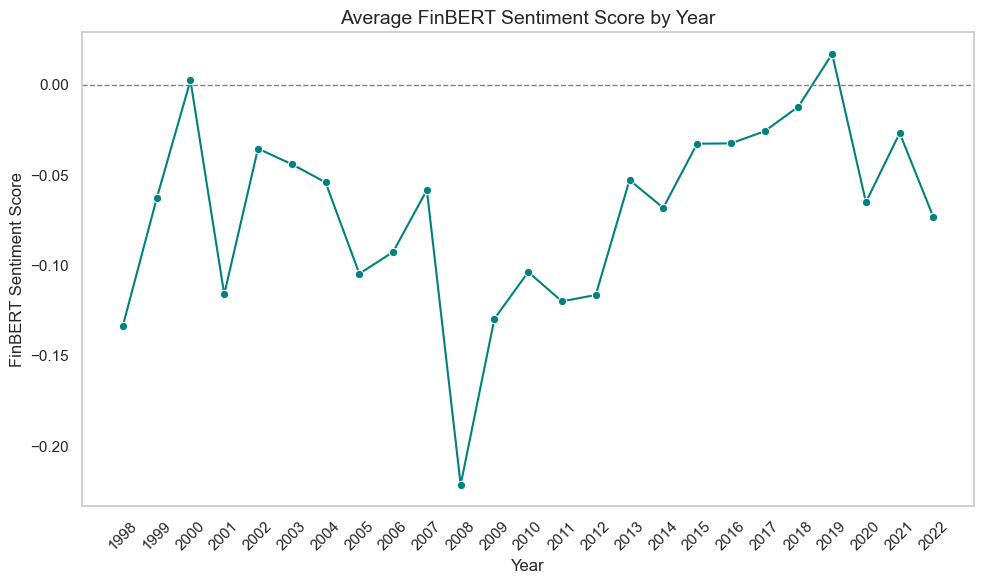

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure data is sorted
sp_year_avg = sp_year_avg.sort_values('year')

# Get full year range (even if some years are missing in data)
all_years = list(range(sp_year_avg['year'].min(), sp_year_avg['year'].max() + 1))

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=sp_year_avg, x='year', y='finbert_score', marker='o', color='teal')

# Customize x-axis to show all years
plt.xticks(all_years, rotation=45)
plt.xlabel('Year', fontsize=12)
plt.ylabel('FinBERT Sentiment Score', fontsize=12)
plt.title('Average FinBERT Sentiment Score by Year', fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(False)
plt.tight_layout()
plt.show()


#### Dual-Axis Line Chart: LM Score vs FinBERT Score - Yearly Average 

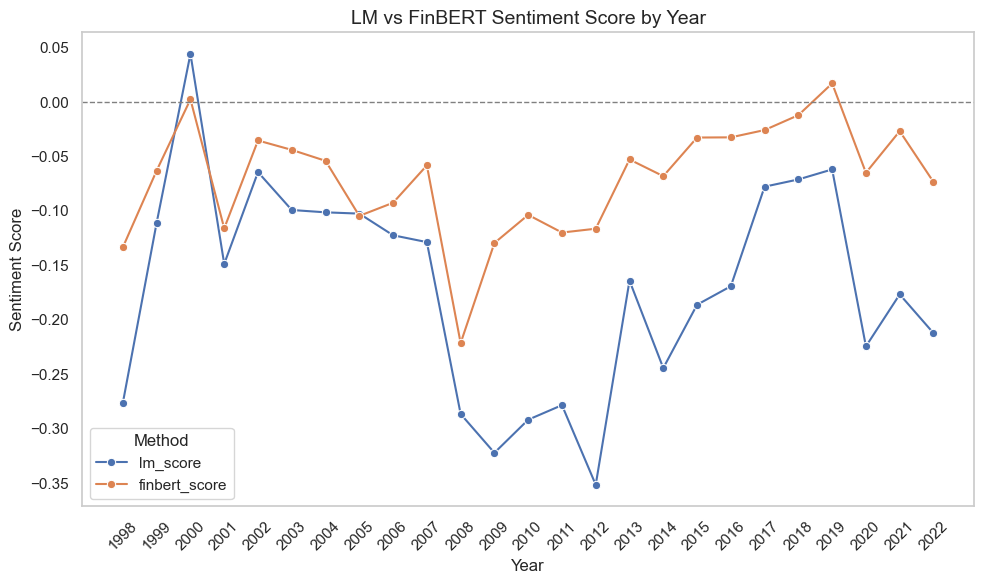

In [71]:
# Melt the DataFrame to long format for Seaborn
fin_lm = sp_year_avg.melt(id_vars='year', value_vars=['lm_score', 'finbert_score'],
                             var_name='method', value_name='sentiment_score')

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=fin_lm, x='year', y='sentiment_score', hue='method', marker='o')

# Customize
plt.title('LM vs FinBERT Sentiment Score by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sentiment Score', fontsize=12)
plt.xticks(fin_lm['year'].unique(), rotation=45)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(False)
plt.tight_layout()
plt.legend(title='Method')
plt.savefig('FinBERT-vs-LM.png', dpi=300, bbox_inches='tight')


plt.show()


##### Both LM & FinBERT models show similar trends in sentiment for BoE. The LM model showed higher volatility due to its sensitivity to negative words. FinBERT smooths volatility by taking into account context-aware nuances.

<div class="alert alert-block alert-info">
Notebook End

## **3. Complete Regression Analysis (Sentiment vs Key Variables)**

***

#### Outputs from this section:

LM sentiment reacts primarily to **broad economic conditions** not isolated indicators.

- **Labour-market variables (unemployment, inactivity, wages)** show the **strongest and most consistent links** with sentiment, especially during stress periods (GFC, COVID) 
- **Inflation on its own is not a dominant driver** of sentiment its effect is weaker, time-varying and often absorbed by broader activity measures in multivariate models.
- **GDP growth and consumer confidence** display the clearest explanatory power in multivariate regressions, suggesting sentiment reflects **overall economic momentum and public mood**
- **Financial variables** (GBP/USD, house prices, policy rate) show **episodic or weak relationships**
- **Rolling correlations confirm time-variation**: the Bank’s communication tone adapts to the **dominant macro narrative of each period** rather than following any single indicator mechanically.
- **Multiple regression + VIF** show that once variables compete, **aggregate indicators dominate** and labour-market variables lose significance — meaning their influence is **indirect, via activity and confidence**.
- **FinBERT and LM results converge** but FinBERT behaves more smoothly; LM offers more granularity for regression work.

<div class="alert alert-block alert-info">
Notebook Start

#### Load and explore the data

In [2]:
# Load the CSV file(s) as reviews.
variables = pd.read_csv('variables_transformed.csv')  

# Print the DataFrame.
variables.head() 

,Month / Year,Sentiment_LM,Sentiment_Finbert,Core_Inflation,Unemployment,Ave_Weekly_earnings_growth,GDP_growth,Benchmark_interest_rate,Economic_Inactivity rate,House_Price_index,Consumer_Confidence,FTSE100,GBP_USD
0,Sep-98,-0.24,-0.19,0.1,0.0,NaN,0.1,0.00,0.0,0.3,2,-3.59,2.90
1,Oct-98,-0.16,-0.21,-0.1,0.0,NaN,0.5,-0.25,0.0,1.0,-6,7.13,0.72
2,Nov-98,-0.32,-0.09,-0.1,-0.1,NaN,0.2,-0.50,-0.1,-0.1,2,7.20,-1.99
3,Dec-98,-0.35,-0.09,0.1,0.1,NaN,0.3,-0.50,0.0,-0.2,-1,0.65,0.58
4,Jan-99,-0.28,-0.29,0.0,0.0,NaN,0.2,-0.25,-0.2,0.7,5,0.23,-1.23


In [3]:
# Replace the missing values with 0 (if applicable)
variables.fillna(0, inplace=True)

In [4]:
# Print the DataFrame.
variables.head() 

,Month / Year,Sentiment_LM,Sentiment_Finbert,Core_Inflation,Unemployment,Ave_Weekly_earnings_growth,GDP_growth,Benchmark_interest_rate,Economic_Inactivity rate,House_Price_index,Consumer_Confidence,FTSE100,GBP_USD
0,Sep-98,-0.24,-0.19,0.1,0.0,0.0,0.1,0.00,0.0,0.3,2,-3.59,2.90
1,Oct-98,-0.16,-0.21,-0.1,0.0,0.0,0.5,-0.25,0.0,1.0,-6,7.13,0.72
2,Nov-98,-0.32,-0.09,-0.1,-0.1,0.0,0.2,-0.50,-0.1,-0.1,2,7.20,-1.99
3,Dec-98,-0.35,-0.09,0.1,0.1,0.0,0.3,-0.50,0.0,-0.2,-1,0.65,0.58
4,Jan-99,-0.28,-0.29,0.0,0.0,0.0,0.2,-0.25,-0.2,0.7,5,0.23,-1.23


In [5]:
# Determine the number of missing values.
variables.isna().sum()

Month / Year                  0
Sentiment_LM                  0
Sentiment_Finbert             0
Core_Inflation                0
Unemployment                  0
Ave_Weekly_earnings_growth    0
GDP_growth                    0
Benchmark_interest_rate       0
Economic_Inactivity rate      0
House_Price_index             0
Consumer_Confidence           0
FTSE100                       0
GBP_USD                       0
dtype: int64

In [6]:
# View the metadata.
variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Month / Year                271 non-null    object 
 1   Sentiment_LM                271 non-null    float64
 2   Sentiment_Finbert           271 non-null    float64
 3   Core_Inflation              271 non-null    float64
 4   Unemployment                271 non-null    float64
 5   Ave_Weekly_earnings_growth  271 non-null    float64
 6   GDP_growth                  271 non-null    float64
 7   Benchmark_interest_rate     271 non-null    float64
 8   Economic_Inactivity rate    271 non-null    float64
 9   House_Price_index           271 non-null    float64
 10  Consumer_Confidence         271 non-null    int64  
 11  FTSE100                     271 non-null    float64
 12  GBP_USD                     271 non-null    float64
dtypes: float64(11), int64(1), object(1)

In [7]:
# Basic descriptive statistics.
variables.describe()

,Sentiment_LM,Sentiment_Finbert,Core_Inflation,Unemployment,Ave_Weekly_earnings_growth,GDP_growth,Benchmark_interest_rate,Economic_Inactivity rate,House_Price_index,Consumer_Confidence,FTSE100,GBP_USD
count,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000
mean,-0.176199,-0.078376,0.013653,-0.008856,2.732472,0.148708,-0.021218,-0.007011,0.499262,-0.158672,0.043911,-0.139483
std,0.166493,0.092386,0.244339,0.103615,1.925323,1.587051,0.172245,0.111831,0.802080,3.540337,4.023274,2.073115
min,-0.650000,-0.340000,-0.900000,-0.200000,-2.900000,-19.200000,-1.500000,-0.300000,-2.500000,-25.000000,-14.860000,-10.520000
25%,-0.280000,-0.130000,-0.100000,-0.100000,1.300000,-0.100000,0.000000,-0.100000,0.050000,-2.000000,-2.250000,-1.270000
50%,-0.190000,-0.070000,0.000000,0.000000,2.700000,0.200000,0.000000,0.000000,0.500000,0.000000,0.770000,-0.080000
75%,-0.080000,-0.030000,0.200000,0.000000,4.200000,0.500000,0.000000,0.100000,1.000000,2.000000,2.705000,1.175000
max,0.330000,0.170000,0.900000,0.400000,8.900000,9.300000,0.500000,0.500000,2.800000,10.000000,11.650000,6.160000


In [8]:
# Check shape
variables.shape

(271, 13)

In [9]:
# Convert 'Month-Year' to datetime for regression analysis
variables['Month / Year'] = pd.to_datetime(variables['Month / Year'], format='%b-%y')  
# '%b' = abbreviated month, '%y' = 2-digit year

In [10]:
# Keep Month / Year for reference
month_year = variables['Month / Year']

In [11]:
# Drop it from numeric calculations for Correlation Map
variables_LM = variables.drop(columns=['Month / Year', 'Sentiment_Finbert'])

### Determine Correlation 

In [12]:
# Compute correlation matrix
corr_matrix = variables_LM.corr()

In [13]:
# Determine correlation
variables_LM.corr()

,Sentiment_LM,Core_Inflation,Unemployment,Ave_Weekly_earnings_growth,GDP_growth,Benchmark_interest_rate,Economic_Inactivity rate,House_Price_index,Consumer_Confidence,FTSE100,GBP_USD
Sentiment_LM,1.000000,-0.020855,-0.149829,0.137050,-0.045459,0.096649,0.051166,0.146349,0.057452,0.058897,0.081767
Core_Inflation,-0.020855,1.000000,-0.033242,0.129116,0.075738,0.085671,0.075354,0.035959,0.011933,0.011501,-0.002032
Unemployment,-0.149829,-0.033242,1.000000,-0.073373,0.057138,-0.190075,-0.027753,-0.197502,0.010290,-0.064160,-0.060964
Ave_Weekly_earnings_growth,0.137050,0.129116,-0.073373,1.000000,-0.024580,0.157659,-0.031450,0.058991,-0.121008,-0.028487,-0.019323
GDP_growth,-0.045459,0.075738,0.057138,-0.024580,1.000000,0.116384,-0.132042,0.120659,0.427603,0.049348,0.092184
Benchmark_interest_rate,0.096649,0.085671,-0.190075,0.157659,0.116384,1.000000,0.025897,0.233253,-0.051700,0.025635,0.275813
Economic_Inactivity rate,0.051166,0.075354,-0.027753,-0.031450,-0.132042,0.025897,1.000000,0.049904,-0.029013,-0.121144,0.051009
House_Price_index,0.146349,0.035959,-0.197502,0.058991,0.120659,0.233253,0.049904,1.000000,0.113171,0.088954,0.167299
Consumer_Confidence,0.057452,0.011933,0.010290,-0.121008,0.427603,-0.051700,-0.029013,0.113171,1.000000,-0.016725,0.079883
FTSE100,0.058897,0.011501,-0.064160,-0.028487,0.049348,0.025635,-0.121144,0.088954,-0.016725,1.000000,0.083574


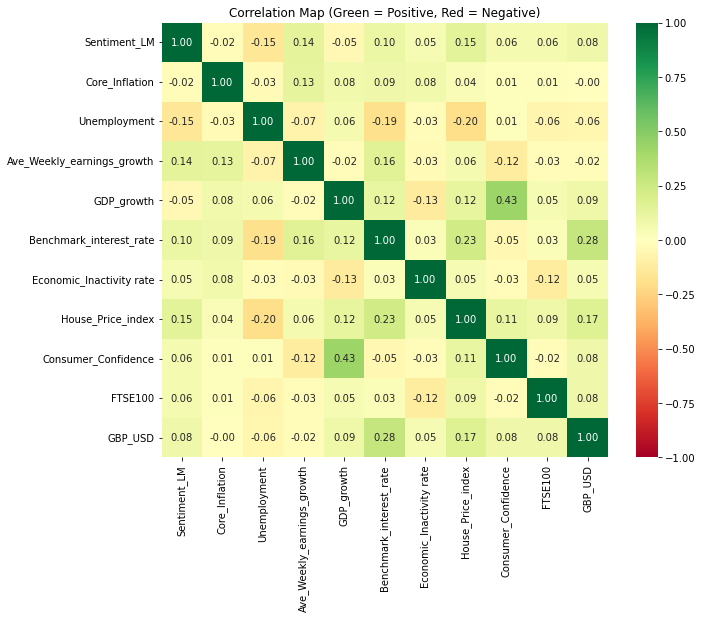

In [14]:
# Determine correlation
corr = variables_LM.corr()

# Create the correlation heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Correlation Map (Green = Positive, Red = Negative)')
plt.show()

**Sentiment_LM shows low-to-moderate correlations** with most macro indicators (|ρ| < 0.20)

The **strongest associations** are with :

* **House Price Index (~0.15)**

* **Weekly Earnings Growth (~0.14)**

* **Benchmark Rate (~0.10)**

These are the variables that appear most sensitive to shifts in communication tone.

**No pairs of macro variables exceed problematic correlation levels**, meaning the data is suitable for simple OLS without multicollinearity concerns.

The **GDP growth ↔ Consumer Confidence** correlation (~0.43) behaves as expected and acts as a sanity-check for the dataset.

#### Key Correlations with Sentiment
- Sentiment_LM vs Unemployment (0.15)
- Sentiment_LM vs Ave.Weekly earnings growth 0.14
- Sentiment_LM vs Benchmark Interest rate 0.10
- Sentiment_LM vs House Price index 0.15

#### Other Correlations of Interest
- Core Inflation vs Ave.Weekly earnings growth 0.13
- Unemployment vs Benchmark Interest rate (0.19)
- Unemployment vs House Price index (0.20)
- Ave. Weekly earnings growth vs Benchmark interest rate 0.16
- Ave. Weekly earnings growth vs Consumer Confidence (0.12)
- GDP Growth vs Consumer Confidence 0.43
- GDP Growth vs Benchmark Interest rate 0.12
- GDP Growth vs Economic Inactivity rate (0.13)
- GDP Growth vs House Price Index 0.12
- Benchmark interest rate vs House Price index 0.23
- Benchmark interest rate vs GBP_USD 0.28
- Economic Inactivity rate vs FTSE100 (0.12)
- House Price Index vs Consumer Confidence 0.11
- House Price Index vs GBP_USD 0.17

### Check for Unit-root and Stationarity 

ADF Test - Null hypothesis H0: the series has a unit root → non-stationary

    -p-value < 0.05: reject H0 → stationary
    -p-value ≥ 0.05: fail to reject H0 → non-stationary

In [15]:
# Create Function for Stationarity checks for multiple variables
def check_stationarity_multi(df, lags=40):
    """
    Runs ADF test and ACF plot for all numeric columns in a dataframe.
    
    Parameters:
    df : pandas DataFrame
        DataFrame with numeric time series
    lags : int
        Number of lags for ACF plot
    """
    # Select numeric columns only
    numeric_cols = variables.select_dtypes(include=['float64', 'int64']).columns
    
    for col in numeric_cols:
        series = variables[col].dropna()  # remove missing values if any
        print(f"--- {col} ---")
        
        # Run ADF test
        adf_result = adfuller(series)
        print(f"ADF Statistic: {adf_result[0]:.4f}")
        print(f"p-value: {adf_result[1]:.4f}")
        print("Critical Values:")
        for key, value in adf_result[4].items():
            print(f"   {key}: {value:.4f}")
        if adf_result[1] < 0.05:
            print("=> Likely stationary\n")
        else:
            print("=> Likely non-stationary\n")
        
               
        # Plot ACF
        plt.figure(figsize=(10,4))
        plot_acf(series, lags=lags)
        plt.title(f'ACF Plot of {col}')
        plt.show()


--- Sentiment_LM ---
ADF Statistic: -4.8836
p-value: 0.0000
Critical Values:
   1%: -3.4551
   5%: -2.8724
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

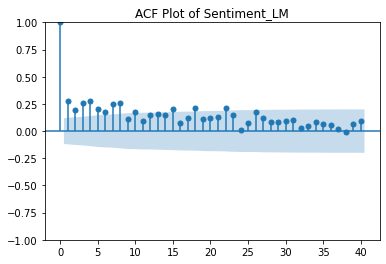

--- Sentiment_Finbert ---
ADF Statistic: -5.1294
p-value: 0.0000
Critical Values:
   1%: -3.4551
   5%: -2.8724
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

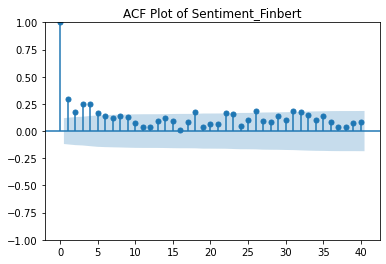

--- Core_Inflation ---
ADF Statistic: -18.0092
p-value: 0.0000
Critical Values:
   1%: -3.4548
   5%: -2.8723
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

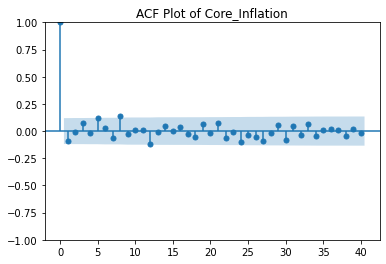

--- Unemployment ---
ADF Statistic: -5.7570
p-value: 0.0000
Critical Values:
   1%: -3.4550
   5%: -2.8724
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

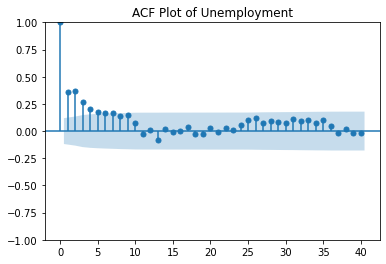

--- Ave_Weekly_earnings_growth ---
ADF Statistic: -2.9513
p-value: 0.0397
Critical Values:
   1%: -3.4551
   5%: -2.8724
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

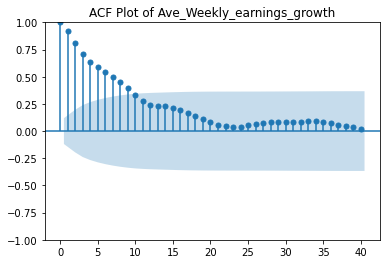

--- GDP_growth ---
ADF Statistic: -10.1450
p-value: 0.0000
Critical Values:
   1%: -3.4552
   5%: -2.8725
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

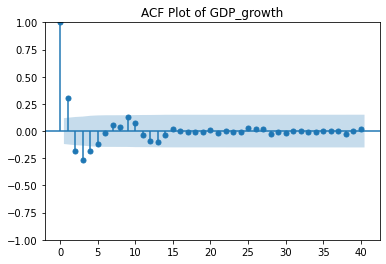

--- Benchmark_interest_rate ---
ADF Statistic: -6.5053
p-value: 0.0000
Critical Values:
   1%: -3.4549
   5%: -2.8723
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

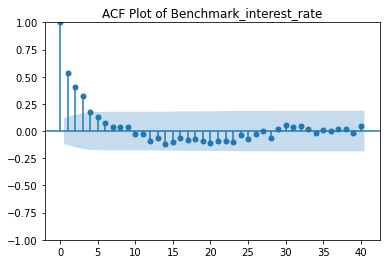

--- Economic_Inactivity rate ---
ADF Statistic: -4.4104
p-value: 0.0003
Critical Values:
   1%: -3.4556
   5%: -2.8726
   10%: -2.5727
=> Likely stationary



<Figure size 720x288 with 0 Axes>

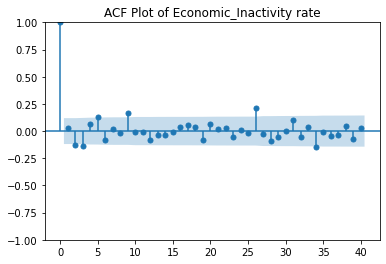

--- House_Price_index ---
ADF Statistic: -3.2092
p-value: 0.0195
Critical Values:
   1%: -3.4552
   5%: -2.8725
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

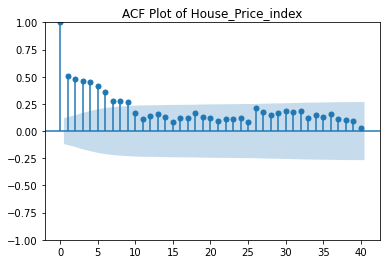

--- Consumer_Confidence ---
ADF Statistic: -17.6852
p-value: 0.0000
Critical Values:
   1%: -3.4548
   5%: -2.8723
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

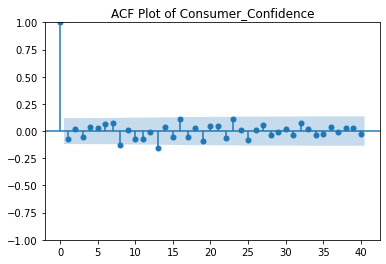

--- FTSE100 ---
ADF Statistic: -16.2089
p-value: 0.0000
Critical Values:
   1%: -3.4548
   5%: -2.8723
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

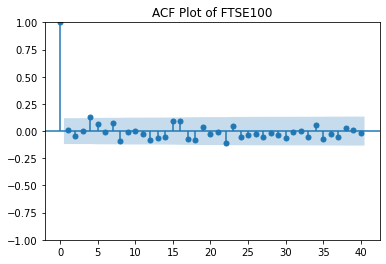

--- GBP_USD ---
ADF Statistic: -7.3110
p-value: 0.0000
Critical Values:
   1%: -3.4552
   5%: -2.8725
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

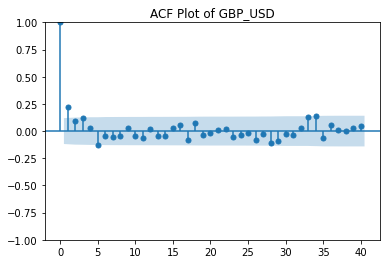

In [16]:
# Check for Stationarity
check_stationarity_multi(variables)

# Null hypothesis H0: the series has a unit root → non-stationary
        # p-value < 0.05: reject H0 → stationary
        # p-value ≥ 0.05: fail to reject H0 → non-stationary

All variables are Stationary - therefore ok to proceed with modelling, forecasting & testing hypothesis for Regression analysis

## **ACF Diagnosis** : 

- A **rapid drop toward zero within the first 3–5 lags**, indicating limited persistence.  
- No significant spikes beyond the 95% confidence band.  
- No signs of seasonal autocorrelation or explosive patterns.

The series have **mean-reverting, stable dynamics**, compatible with **OLS and linear regression assumptions**.
All macroeconomic and sentiment variables are **stationary** so we can safely proceed with linear modelling, hypothesis testing and forecasting.

### Sentiment (LM) vs Core Inflation

In [17]:
# Define the dependent variable.
y = variables['Sentiment_LM'] 

# Define the independent variable.
x = variables['Core_Inflation'] 

# Note: Core_Inflation First Difference needs to be used to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3482134459.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


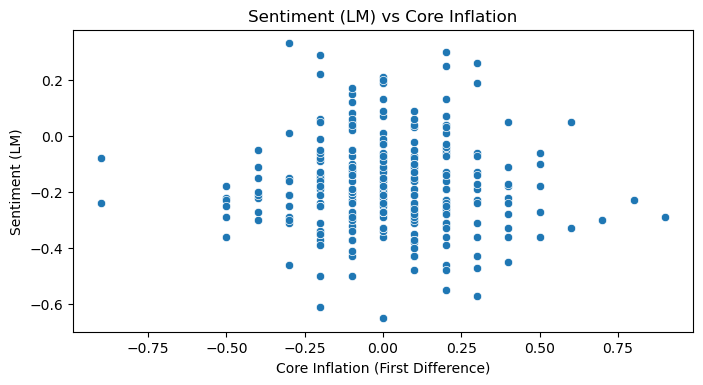

In [18]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment (LM) vs Core Inflation")
plt.xlabel("Core Inflation (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Core_Inflation",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [19]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg = np.polyfit(variables['Core_Inflation'], variables ['Sentiment_LM'], deg = 1)

# View output.
reg

array([-0.0142103 , -0.17600525])

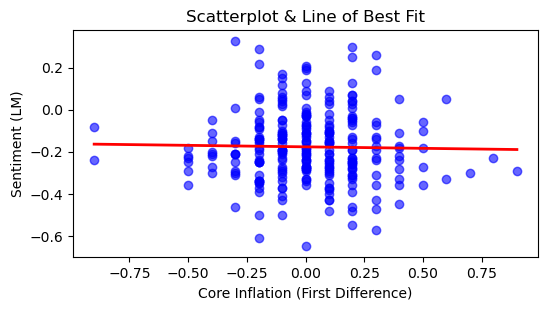

In [20]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend = np.polyval(reg, variables['Core_Inflation'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Core_Inflation',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Core Inflation (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [21]:
# Pass linear regression through OLS methods.
test = ols('y ~ x', data = variables).fit(cov_type='HC1') 
# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1504
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.698
Time:                        07:12:31   Log-Likelihood:                 101.88
No. Observations:                 271   AIC:                            -199.8
Df Residuals:                     269   BIC:                            -192.5
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1760      0.010    -17.420      0.000      -0.196      -0.156
x             -0.0142      0.037     -0.388      0.698      -0.086       0.058
==============================================================================
Omnibus:                        8.423   Durbin-Watson:                   1.452
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                8.492
Skew:                           0.368   Prob(JB):                       0.0143
Kurtosis:                       3.459   Cond. No.                         4.10
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [22]:
# Extract Residuals
residuals = np.asarray(test.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Core Inflation) Breusch-Pagan test for testing for Heteroskedasticity 

In [23]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test = het_breuschpagan(test.resid, test.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results = dict(zip(labels, bp_test))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.5152
LM p-value: 0.4729
F Statistic: 0.5124
F p-value: 0.4747


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Core Inflation) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

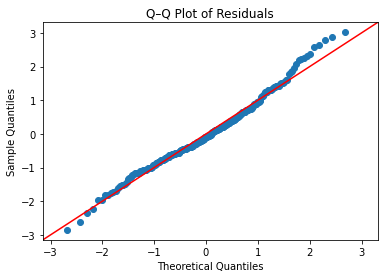

In [24]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails.

In [25]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw1_p = shapiro(residuals)[1]
jb1_p = jarque_bera(residuals)[1]    
    
print("Shapiro–Wilks p-value:", shapiro(residuals)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals)[1])

Shapiro–Wilks p-value: 0.009719882552104629
Jarque–Bera p-value: 0.0143235469943858


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Core Inflation – Regression diagnostics

**Model fit and significance**

- The coefficient on core inflation is **−0.0142** with a **p-value of 0.70** and the **R-squared is effectively 0.00**.  
- This means **changes in core inflation alone do not explain LM sentiment** once we isolate this bivariate relationship.

**Residual diagnostics**

- **Heteroskedasticity :** The Breusch–Pagan test returns  
  - LM p-value ≈ **0.47** and F p-value ≈ **0.47** so we **do not find evidence of heteroskedasticity** in this specification.
- **Normality :**  
  - Shapiro–Wilk p-value ≈ **0.01** and Jarque–Bera p-value ≈ **0.01** indicating **mild departures from exact normality** in the residuals.  
  The Q–Q plot, however, shows residuals broadly on the 45° line with only small tail deviations, and we mitigate this by using **robust (HC1) standard errors**.

The **Sentiment–Inflation bivariate regression is statistically weak** and mainly used as a **diagnostic benchmark**.  
It suggests that any link between LM sentiment and inflation is likely to operate **through a richer macro context** rather than through core inflation changes in isolation.

### Sentiment (LM) vs Unemployment

In [26]:
# Define the dependent variable.
y2 = variables['Sentiment_LM'] 

# Define the independent variable.
x2 = variables['Unemployment'] 

# Note: Unemployment needs to be First differenced since it is already expressed as a %

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3103200088.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


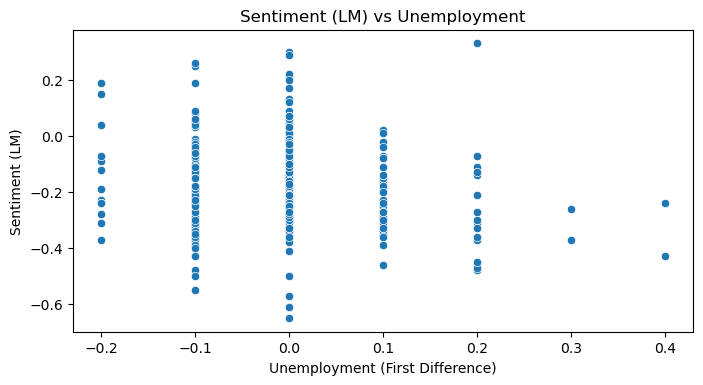

In [27]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment (LM) vs Unemployment")
plt.xlabel("Unemployment (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Unemployment",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [28]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg2 = np.polyfit(variables['Unemployment'], variables['Sentiment_LM'], deg = 1)

# View output.
reg2

array([-0.24075182, -0.17833138])

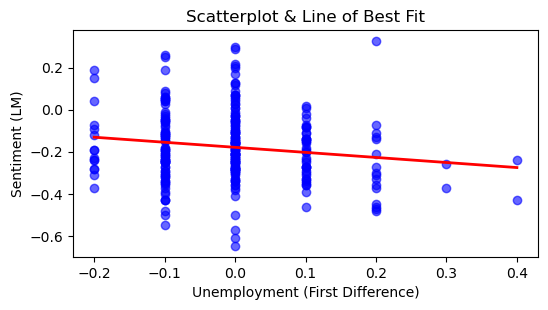

In [29]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend2 = np.polyval(reg2, variables['Unemployment'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Unemployment',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Unemployment (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [30]:
# Pass linear regression through OLS methods.
test2 = ols('y2 ~ x2', data = variables).fit(cov_type='HC1')
# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y2   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     6.520
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0112
Time:                        07:13:01   Log-Likelihood:                 104.89
No. Observations:                 271   AIC:                            -205.8
Df Residuals:                     269   BIC:                            -198.6
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1783      0.010    -17.827      0.000      -0.198      -0.159
x2            -0.2408      0.094     -2.553      0.011      -0.426      -0.056
==============================================================================
Omnibus:                        9.296   Durbin-Watson:                   1.495
Prob(Omnibus):                  0.010   Jarque-Bera (JB):                9.888
Skew:                           0.363   Prob(JB):                      0.00713
Kurtosis:                       3.589   Cond. No.                         9.67
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [31]:
# Extract Residuals
residuals2 = np.asarray(test2.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Unemployment) Breusch-Pagan test for testing for Heteroskedasticity

In [32]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test2 = het_breuschpagan(test2.resid, test2.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results2 = dict(zip(labels, bp_test2))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results2.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.3462
LM p-value: 0.5563
F Statistic: 0.3441
F p-value: 0.5580


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Unemployment) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

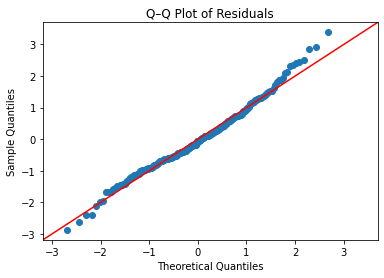

In [33]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals2, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails.

In [34]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw2_p = shapiro(residuals2)[1]
jb2_p = jarque_bera(residuals2)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals2)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals2)[1])

Shapiro–Wilks p-value: 0.014510651901434966
Jarque–Bera p-value: 0.0071274838824738045


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Unemployment – Regression diagnostics

The scatterplot shows a **weak downward pattern** but with wide dispersion, suggesting only a **small linear relationship** between unemployment changes and sentiment.

**OLS regression**  
- Slope = **–0.24** → higher unemployment is associated with slightly lower sentiment.  
- p-value = **0.012** → statistically significant.  
- R² = **0.022** → unemployment explains only ~2% of sentiment variation.  
→ The effect exists but remains **economically weak**.

**Residual diagnostics**  
- **Breusch–Pagan p = 0.556** → no heteroskedasticity.  
- **Q–Q plot** → mostly aligned with the 45° line.  
- **Shapiro–Wilk p = 0.014** & **Jarque–Bera p = 0.007** → residuals **not normally distributed** but OLS remains valid with robust errors.
 
Unemployment exhibits a **statistically significant but small negative impact** on public sentiment.  
The model is statistically sound but **low explanatory power** suggests unemployment is only one of many drivers of sentiment.

### Sentiment (LM) vs Wages Growth (Ave_Weekly_earnings_growth)

In [35]:
# Define the dependent variable.
y3 = variables['Sentiment_LM'] 

# Define the independent variable.
x3 = variables['Ave_Weekly_earnings_growth']

# Note: Average Weekly earnings growth is already expressed as a MoM% growth rate. Therefore no further transformation needed
# Note: Average Weekly earnings growth is a proxy for Wages growth

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\2626320073.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


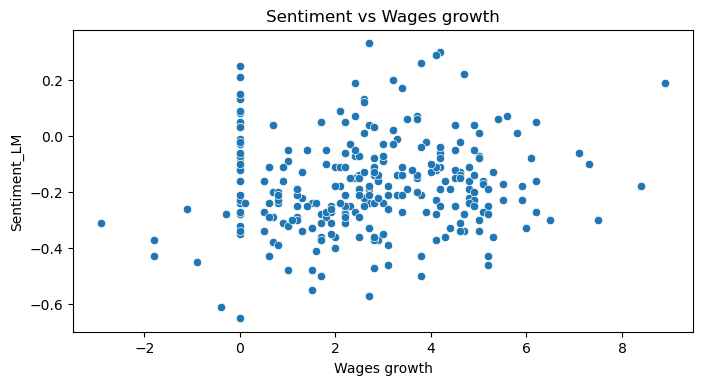

In [36]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs Wages growth")
plt.xlabel("Wages growth")
plt.ylabel("Sentiment_LM")
sns.scatterplot(data=variables,
               x= "Ave_Weekly_earnings_growth",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [37]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg3 = np.polyfit(variables['Ave_Weekly_earnings_growth'], variables['Sentiment_LM'], deg = 1)

# View output
reg3

array([ 0.01185143, -0.20858297])

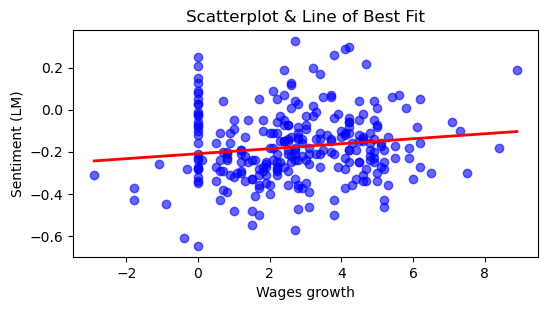

In [38]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend3 = np.polyval(reg3, variables['Ave_Weekly_earnings_growth'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Ave_Weekly_earnings_growth',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Wages growth")
plt.ylabel("Sentiment (LM)")
plt.show()

In [39]:
# Pass linear regression through OLS methods.
test3 = ols('y3 ~ x3', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y3   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     4.741
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0303
Time:                        07:13:27   Log-Likelihood:                 104.39
No. Observations:                 271   AIC:                            -204.8
Df Residuals:                     269   BIC:                            -197.6
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2086      0.019    -11.004      0.000      -0.246      -0.171
x3             0.0119      0.005      2.177      0.029       0.001       0.023
==============================================================================
Omnibus:                       10.352   Durbin-Watson:                   1.474
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               10.562
Skew:                           0.428   Prob(JB):                      0.00509
Kurtosis:                       3.448   Cond. No.                         6.17
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [40]:
# Extract Residuals
residuals3 = np.asarray(test3.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Wages Growth) Breusch-Pagan test for testing for Heteroskedasticity

In [41]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test3 = het_breuschpagan(test3.resid, test3.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results3 = dict(zip(labels, bp_test3))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results3.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 1.8835
LM p-value: 0.1699
F Statistic: 1.8827
F p-value: 0.1712


p-values suggest no Heteroskedasticity.

###### (Sentiment (LM) vs Wages Growth Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

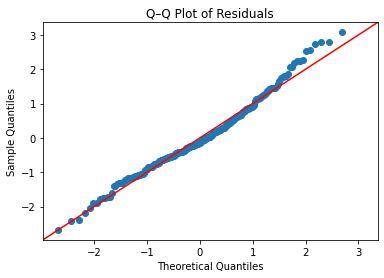

In [42]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals3, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails

In [43]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw3_p = shapiro(residuals3)[1]
jb3_p = jarque_bera(residuals3)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals3)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals3)[1])

Shapiro–Wilks p-value: 0.0025203745663668403
Jarque–Bera p-value: 0.005087320851689499


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Wages Growth – Regression diagnostics  

The scatterplot shows a **weak positive pattern** but the dispersion is wide.

**OLS results:**  
- **Coefficient:** +0.0119 → small positive association  
- **Statistical significance:** p = 0.029 (significant at 5%)  
- **R² = 0.019** → wages explain ~2% of sentiment variation  
→ Wages growth significantly affects sentiment but the effect size is economically small

**Residual diagnostics**  
- **Breusch–Pagan test :** p = 0.169 → no heteroskedasticity  
- **Durbin–Watson = 1.47** → mild autocorrelation risk  
- **Q–Q plot :** mild tail deviations  
- **Shapiro–Wilk (p = 0.0025) & Jarque–Bera (p = 0.005)** → residuals not perfectly normal  

The model is statistically valid (no heteroskedasticity, stable coefficients) but residual non-normality and low R² indicate that **wages growth has only a marginal impact on sentiment**.  

### Sentiment (LM) vs GDP Growth

In [44]:
# Define the dependent variable.
y4 = variables['Sentiment_LM'] 

# Define the independent variable.
x4 = variables['GDP_growth']

# Note: GDP growth is already expressed as a MoM% growth rate. Therefore, no further transformation needed.

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\1696518885.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


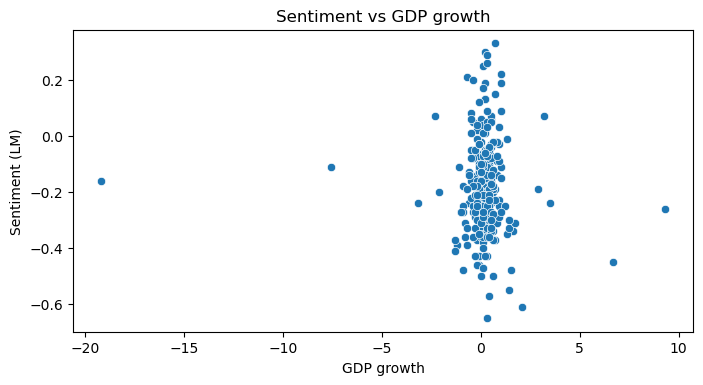

In [45]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs GDP growth")
plt.xlabel("GDP growth")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "GDP_growth",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [46]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg4 = np.polyfit(variables['GDP_growth'], variables['Sentiment_LM'], deg = 1)

# View output.
reg4

array([-0.00476897, -0.17549008])

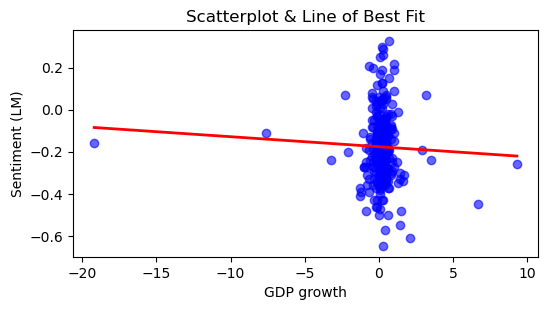

In [47]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend4 = np.polyval(reg4, variables['GDP_growth'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='GDP_growth',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("GDP growth")
plt.ylabel("Sentiment (LM)")
plt.show()

In [48]:
# Pass linear regression through OLS methods.
test4 = ols('y4 ~ x4', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y4   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                     1.192
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.276
Time:                        07:13:49   Log-Likelihood:                 102.10
No. Observations:                 271   AIC:                            -200.2
Df Residuals:                     269   BIC:                            -193.0
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1755      0.010    -17.464      0.000      -0.195      -0.156
x4            -0.0048      0.004     -1.092      0.275      -0.013       0.004
==============================================================================
Omnibus:                        8.808   Durbin-Watson:                   1.451
Prob(Omnibus):                  0.012   Jarque-Bera (JB):                8.909
Skew:                           0.380   Prob(JB):                       0.0116
Kurtosis:                       3.461   Cond. No.                         1.61
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [49]:
# Extract Residuals
residuals4 = np.asarray(test4.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs GDP Growth) Breusch-Pagan test for testing for Heteroskedasticity

In [50]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test4 = het_breuschpagan(test4.resid, test4.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results4 = dict(zip(labels, bp_test4))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results4.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 1.0764
LM p-value: 0.2995
F Statistic: 1.0727
F p-value: 0.3013


p-values suggest no Heteroskedasticity.

###### (Sentiment (LM) vs GDP Growth) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

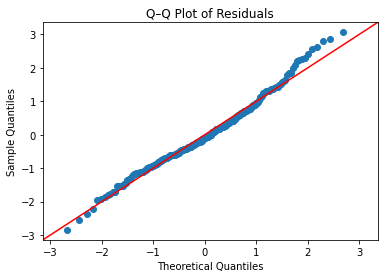

In [51]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals4, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails

In [52]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw4_p = shapiro(residuals4)[1]
jb4_p = jarque_bera(residuals4)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals4)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals4)[1])

Shapiro–Wilks p-value: 0.009231100423286885
Jarque–Bera p-value: 0.011625959569578596


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs GDP Growth – Regression diagnostics

The relationship between sentiment and GDP growth appears **very weak and slightly negative** with points widely scattered around the regression line.  
No visible pattern suggests a strong linear association.

**OLS regression**  
- Coefficient : **–0.0048**  
- p-value: **0.276** → **not statistically significant**  
- R²: **0.002** → GDP growth explains **0.2%** of sentiment variation  
-> The model fails the F-test (p = 0.276) confirming **no explanatory power**

**Residual diagnostics**  
- **Breusch–Pagan p-value = 0.30** → no heteroskedasticity  
- **Q-Q plot:** residuals roughly follow normality, with small tail deviations  
- **Shapiro–Wilk p = 0.009**, **Jarque–Bera p = 0.011** → residuals **not perfectly normal** (mild tail distortions)

GDP growth shows **no meaningful linear effect** on public sentiment.  
The relationship is statistically insignificant with very low explanatory power though model assumptions (linearity & homoscedasticity) are reasonably met.


### Sentiment (LM) vs Benchmark interest rate

In [53]:
# Define the dependent variable.
y5 = variables['Sentiment_LM'] 

# Define the independent variable.
x5 = variables['Benchmark_interest_rate']

# Note: Benchmark Interest rate needs to be first-differenced to ensure stationarity.

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3838342375.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


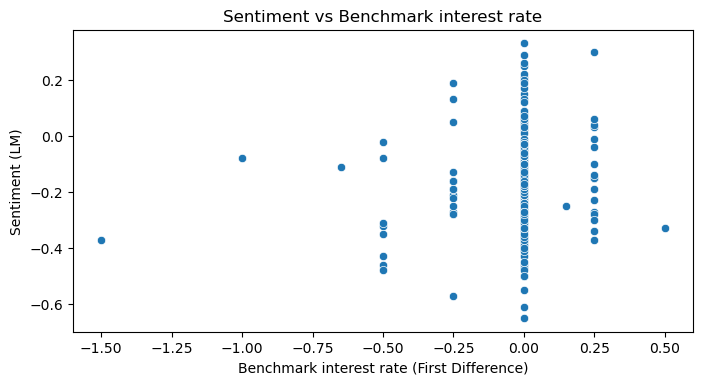

In [54]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs Benchmark interest rate")
plt.xlabel("Benchmark interest rate (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Benchmark_interest_rate",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [55]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg5 = np.polyfit(variables['Benchmark_interest_rate'], variables['Sentiment_LM'], deg = 1)

# View output.
reg5

array([ 0.09342169, -0.17421707])

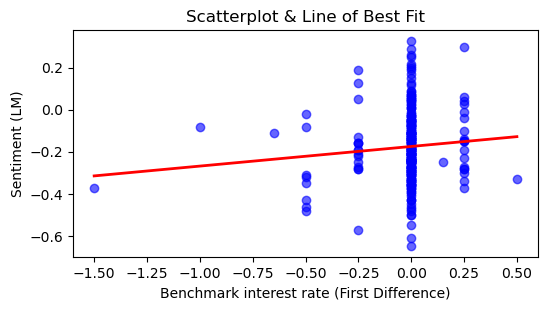

In [56]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend5 = np.polyval(reg5, variables['Benchmark_interest_rate'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Benchmark_interest_rate',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Benchmark interest rate (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [57]:
# Pass linear regression through OLS methods.
test5 = ols('y5 ~ x5', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y5   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.016
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0836
Time:                        07:14:13   Log-Likelihood:                 103.09
No. Observations:                 271   AIC:                            -202.2
Df Residuals:                     269   BIC:                            -195.0
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1742      0.010    -17.159      0.000      -0.194      -0.154
x5             0.0934      0.054      1.737      0.082      -0.012       0.199
==============================================================================
Omnibus:                        8.366   Durbin-Watson:                   1.486
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                8.373
Skew:                           0.372   Prob(JB):                       0.0152
Kurtosis:                       3.433   Cond. No.                         5.82
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [58]:
# Extract Residuals
residuals5 = np.asarray(test5.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Benchmark Interest rate) Breusch-Pagan test for testing for Heteroskedasticity

In [59]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test5 = het_breuschpagan(test5.resid, test5.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results5 = dict(zip(labels, bp_test5))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results5.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0010
LM p-value: 0.9747
F Statistic: 0.0010
F p-value: 0.9749


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Benchmark Interest rate) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

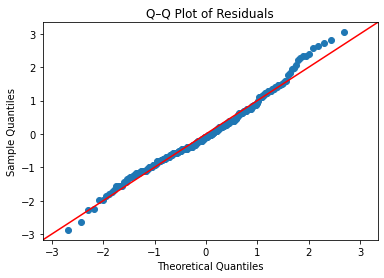

In [60]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals5, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails

In [61]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw5_p = shapiro(residuals5)[1]
jb5_p = jarque_bera(residuals5)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals5)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals5)[1])

Shapiro–Wilks p-value: 0.009538288836215587
Jarque–Bera p-value: 0.015199114052325812


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Benchmark Interest Rate – Regression Diagnostics

The scatterplot shows **no clear linear pattern** between Sentiment (LM) and the first difference of the Benchmark Interest Rate. The points are widely dispersed around zero, with only a very slight positive slope suggested by the fitted line ->  **weak or negligible association**.

**OLS Regression Results**
- **Coefficient** = **+0.0934**  
  → A 1-point increase in ΔBenchmark rate is associated with a **+0.093** change in sentiment.  
- **p-value** = **0.0836**  
  → Not statistically significant at 5% confidence.  
- **R² = 0.009**  
  → The model explains **0.9%** of Sentiment variation (very low explanatory power).  

**Residual Diagnostics**
- **Breusch–Pagan p** = 0.974 → no heteroskedasticity.
- **Q–Q plot** → residuals mostly aligned with mild tail deviations.
- **Shapiro–Wilk p** = 0.009 & Jarque–Bera p = 0.015 → residuals not normally distributed, but OLS valid with HC1 robust SEs.

→ Both tests indicate **non-normal residuals** driven mostly by mild skew/kurtosis (as seen in the Q–Q plot).

The model shows **no statistically significant relationship** between Sentiment (LM) and Benchmark Interest Rate changes and its explanatory power is negligible.  
Residuals show **homoskedasticity** but **mild non-normality**.

### Sentiment (LM) vs Economic Inactivity rate

In [62]:
# Define the dependent variable.
y6 = variables['Sentiment_LM'] 

# Define the independent variable.
x6 = variables['Economic_Inactivity rate']

# Note: Economic Inactivity rate is already expressed as a %, therefore need to First Difference to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3066018855.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


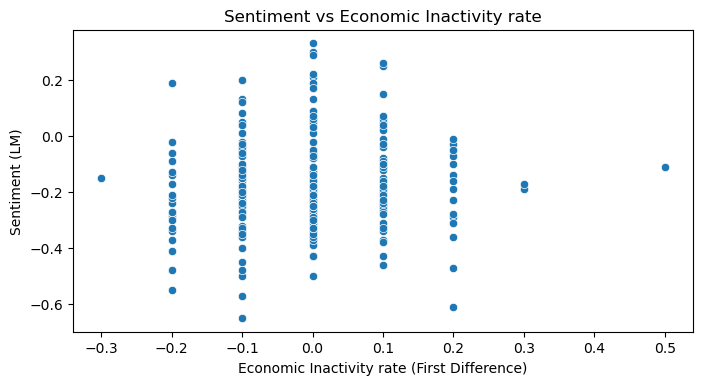

In [63]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs Economic Inactivity rate")
plt.xlabel("Economic Inactivity rate (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Economic_Inactivity rate",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [64]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg6 = np.polyfit(variables['Economic_Inactivity rate'], variables['Sentiment_LM'], deg = 1)

# View output.
reg6

array([ 0.07617585, -0.17566519])

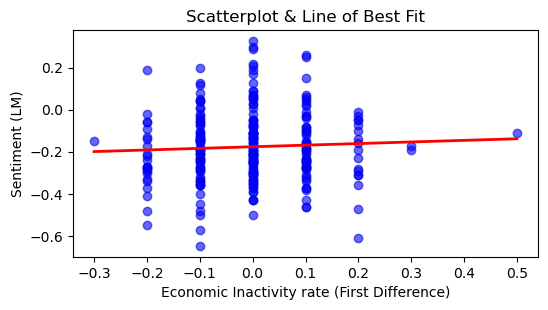

In [65]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend6 = np.polyval(reg6, variables['Economic_Inactivity rate'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Economic_Inactivity rate',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Economic Inactivity rate (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [66]:
# Pass linear regression through OLS methods.
test6 = ols('y6 ~ x6', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y6   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8490
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.358
Time:                        07:14:41   Log-Likelihood:                 102.17
No. Observations:                 271   AIC:                            -200.3
Df Residuals:                     269   BIC:                            -193.1
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1757      0.010    -17.347      0.000      -0.196      -0.156
x6             0.0762      0.083      0.921      0.357      -0.086       0.238
==============================================================================
Omnibus:                        8.423   Durbin-Watson:                   1.454
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                8.493
Skew:                           0.368   Prob(JB):                       0.0143
Kurtosis:                       3.460   Cond. No.                         8.96
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [67]:
# Extract Residuals
residuals6 = np.asarray(test6.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Economic Inactivity rate) Breusch-Pagan test for testing for Heteroskedasticity

In [68]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test6 = het_breuschpagan(test6.resid, test6.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results6 = dict(zip(labels, bp_test6))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results6.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0225
LM p-value: 0.8809
F Statistic: 0.0223
F p-value: 0.8814


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Economic Inactivity rate) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

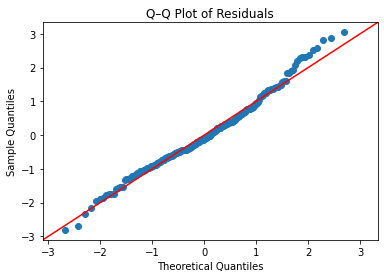

In [69]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals6, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild skewness in the tails

In [70]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw6_p = shapiro(residuals6)[1]
jb6_p = jarque_bera(residuals6)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals6)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals6)[1])

Shapiro–Wilks p-value: 0.009044629379681157
Jarque–Bera p-value: 0.01431512238445917


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Economic Inactivity Rate – Regression diagnostics

The scatter shows **no clear linear pattern** between sentiment and economic inactivity. Points are widely dispersed around zero suggesting only a very weak association.

**OLS Regression**
- Coefficient = **0.076** (p = **0.357**) → **not statistically significant**.  
- R² = **0.003** → almost no explanatory power.  
- Model fails to detect any meaningful link.

**Residual Diagnostics**
- **Breusch–Pagan p = 0.8089** → no heteroskedasticity.  
- **Q–Q plot** → residuals broadly follow a straight line with mild skew.  
- **Shapiro–Wilk p = 0.009** & **Jarque–Bera p = 0.014** → residuals **not normally distributed** but OLS remains valid with robust SEs.

Economic inactivity has **no measurable impact** on LM sentiment and diagnostics confirm the regression results are stable but not meaningful.

### Sentiment (LM) vs House Price index

In [71]:
# Define the dependent variable.
y7 = variables['Sentiment_LM'] 

# Define the independent variable.
x7 = variables['House_Price_index']

# Note: House Price Index is already a log-differenced growth rate. Therefore, no further transformation needed

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3261374738.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


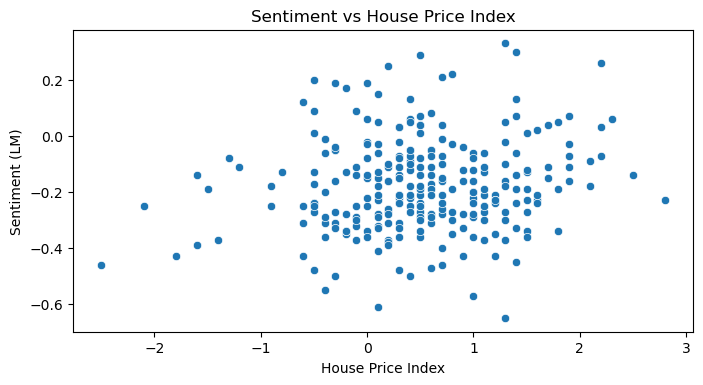

In [72]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs House Price Index")
plt.xlabel("House Price Index")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "House_Price_index",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [73]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg7 = np.polyfit(variables['House_Price_index'], variables['Sentiment_LM'], deg = 1)

# View output.
reg7

array([ 0.03037861, -0.19136615])

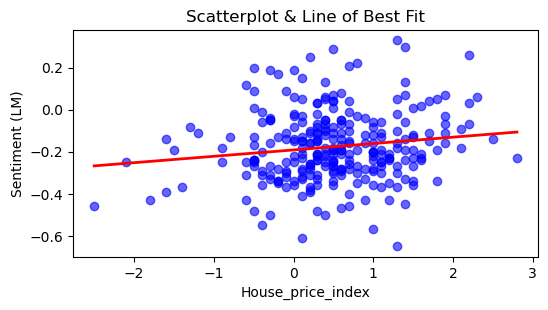

In [74]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend7 = np.polyval(reg7, variables['House_Price_index'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='House_Price_index',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("House_price_index")
plt.ylabel("Sentiment (LM)")
plt.show()

In [75]:
# Pass linear regression through OLS methods.
test7 = ols('y7 ~ x7', data = variables).fit(cov_type='HC1')

# Print the regression table.
test7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y7   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     6.223
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0132
Time:                        07:15:16   Log-Likelihood:                 104.75
No. Observations:                 271   AIC:                            -205.5
Df Residuals:                     269   BIC:                            -198.3
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1914      0.012    -16.328      0.000      -0.214      -0.168
x7             0.0304      0.012      2.495      0.013       0.007       0.054
==============================================================================
Omnibus:                        9.008   Durbin-Watson:                   1.540
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                9.229
Skew:                           0.377   Prob(JB):                      0.00991
Kurtosis:                       3.499   Cond. No.                         1.81
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [76]:
# Extract Residuals
residuals7 = np.asarray(test7.resid).flatten()  # ensures 1-D NumPy array

###### (Sentiment (LM) vs House Price Index) Breusch-Pagan test for testing for Heteroskedasticity

In [77]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test7 = het_breuschpagan(test7.resid, test7.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results7 = dict(zip(labels, bp_test7))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results7.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0000
LM p-value: 0.9953
F Statistic: 0.0000
F p-value: 0.9953


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs House Price Index) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

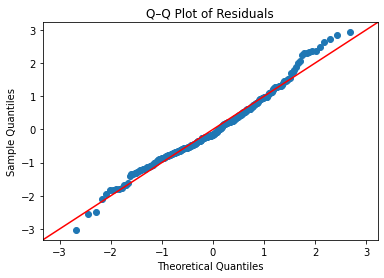

In [78]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals7, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that there are some slight skewness in the tails

In [79]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw7_p = shapiro(residuals7)[1]
jb7_p = jarque_bera(residuals7)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals7)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals7)[1])

Shapiro–Wilks p-value: 0.0027655102909529172
Jarque–Bera p-value: 0.009908728652515656


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs House Price Index – Regression diagnostics

The scatterplot shows no clear linear pattern but a slight positive slope appears once the trendline is added.

**OLS Regression**
- Coefficient: β = 0.0304 (p = 0.013) → statistically significant but small effect.
- Model fit: R² = 0.021 → very weak explanatory power.

**Residual Diagnostics**
- **Breusch–Pagan p** = 0.953 → no heteroskedasticity.
- **Q–Q plot** → slight skewness in the tails.
- **Shapiro–Wilk p = 0.0028** & **Jarque–Bera p = 0.0099** → residuals not normally distributed but OLS inference valid with robust SEs.

House Price Index changes show a **small but statistically significant** positive association with LM sentiment, though with **very low explanatory power** and **non-normal residuals**.

### Sentiment (LM) vs Consumer Confidence

In [80]:
# Define the dependent variable.
y8 = variables['Sentiment_LM'] 

# Define the independent variable.
x8 = variables['Consumer_Confidence']

# Note: Consumer Confidence is a bounded index and a measure of Sentiment. 
# This needs to be First Differenced to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\527408892.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


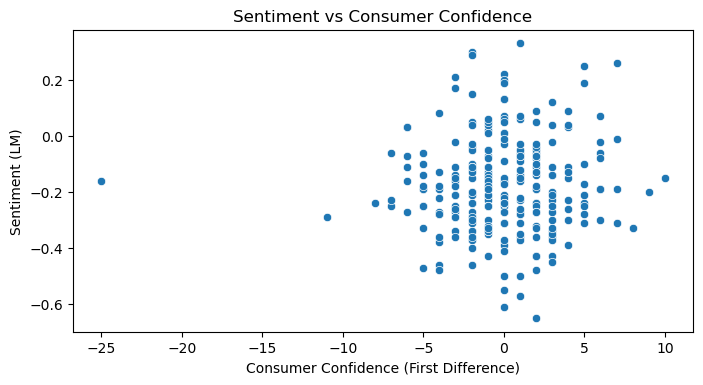

In [81]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs Consumer Confidence")
plt.xlabel("Consumer Confidence (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Consumer_Confidence",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [82]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg8 = np.polyfit(variables['Consumer_Confidence'], variables['Sentiment_LM'], deg = 1)

# View output.
reg8

array([ 0.00270182, -0.17577056])

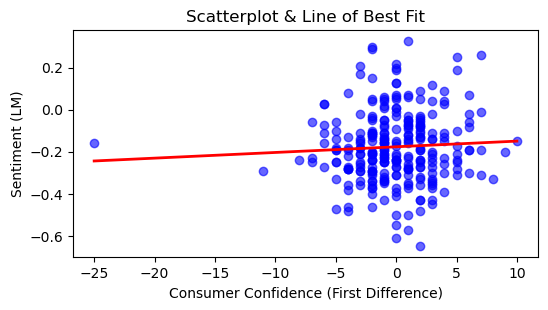

In [83]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend8 = np.polyval(reg8, variables['Consumer_Confidence'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Consumer_Confidence',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Consumer Confidence (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [84]:
# Pass linear regression through OLS methods.
test8 = ols('y8 ~ x8', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test8.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y8   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     1.229
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.269
Time:                        07:16:04   Log-Likelihood:                 102.27
No. Observations:                 271   AIC:                            -200.5
Df Residuals:                     269   BIC:                            -193.3
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1758      0.010    -17.271      0.000      -0.196      -0.156
x8             0.0027      0.002      1.109      0.268      -0.002       0.007
==============================================================================
Omnibus:                        7.684   Durbin-Watson:                   1.453
Prob(Omnibus):                  0.021   Jarque-Bera (JB):                7.709
Skew:                           0.344   Prob(JB):                       0.0212
Kurtosis:                       3.459   Cond. No.                         3.54
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [85]:
# Extract Residuals
residuals8 = np.asarray(test8.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Consumer Confidence) Breusch-Pagan test for testing for Heteroskedasticity

In [86]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test8 = het_breuschpagan(test8.resid, test8.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results8 = dict(zip(labels, bp_test8))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results8.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 1.5629
LM p-value: 0.2112
F Statistic: 1.5604
F p-value: 0.2127


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Consumer Confidence) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

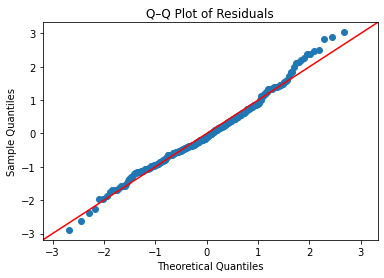

In [87]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals8, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that there are some slight skewness in the tails

In [88]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw8_p = shapiro(residuals8)[1]
jb8_p = jarque_bera(residuals8)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals8)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals8)[1])

Shapiro–Wilks p-value: 0.016270570429019957
Jarque–Bera p-value: 0.021181293023328104


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

### Sentiment (LM) vs FTSE100 index

In [89]:
# Define the dependent variable.
y9 = variables['Sentiment_LM'] 

# Define the independent variable.
x9 = variables['FTSE100']

# Note: FTSE100 index follows a 'random walk'. Therefore need to use Log-growth to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3881204621.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


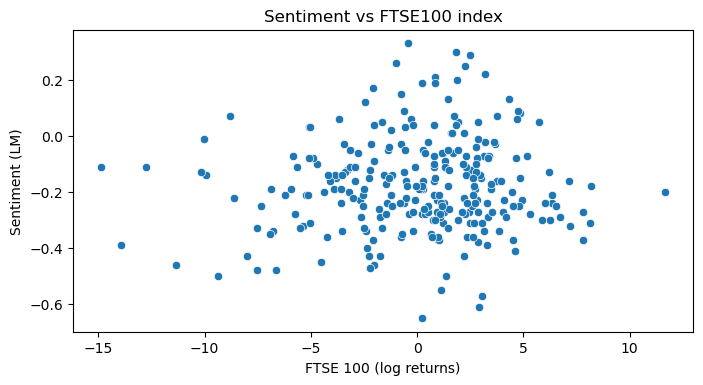

In [90]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs FTSE100 index")
plt.xlabel("FTSE 100 (log returns)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "FTSE100",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [91]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg9 = np.polyfit(variables['FTSE100'], variables['Sentiment_LM'], deg = 1)

# View output.
reg9

array([ 0.00243731, -0.17630629])

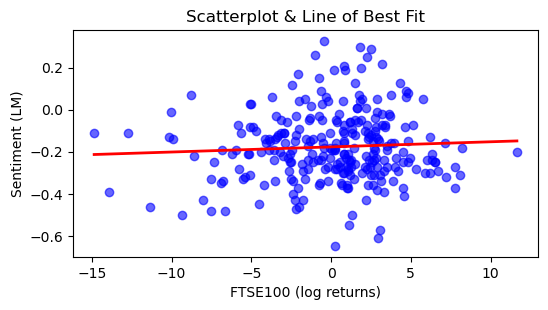

In [92]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend9 = np.polyval(reg9, variables['FTSE100'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='FTSE100',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("FTSE100 (log returns)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [93]:
# Pass linear regression through OLS methods.
test9 = ols('y9 ~ x9', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test9.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y9   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     1.083
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.299
Time:                        07:16:31   Log-Likelihood:                 102.29
No. Observations:                 271   AIC:                            -200.6
Df Residuals:                     269   BIC:                            -193.4
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1763      0.010    -17.432      0.000      -0.196      -0.156
x9             0.0024      0.002      1.041      0.298      -0.002       0.007
==============================================================================
Omnibus:                        8.061   Durbin-Watson:                   1.451
Prob(Omnibus):                  0.018   Jarque-Bera (JB):                8.023
Skew:                           0.365   Prob(JB):                       0.0181
Kurtosis:                       3.421   Cond. No.                         4.02
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [94]:
# Extract Residuals
residuals9 = np.asarray(test9.resid).flatten()  # ensures 1-D NumPy array

###### (Sentiment (LM) vs FTSE100) Breusch-Pagan test for testing for Heteroskedasticity

In [95]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test9 = het_breuschpagan(test9.resid, test9.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results9 = dict(zip(labels, bp_test9))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results9.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0146
LM p-value: 0.9038
F Statistic: 0.0145
F p-value: 0.9043


p-values suggest no Heteroskedasticity.

###### (Sentiment (LM) vs FTSE100) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

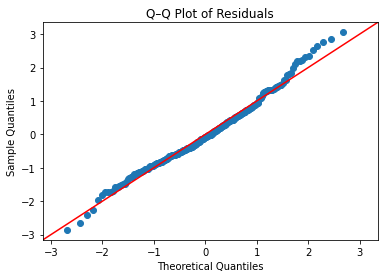

In [96]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals9, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that there are some slight skewness in the tails

In [97]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw9_p = shapiro(residuals9)[1]
jb9_p = jarque_bera(residuals9)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals9)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals9)[1])

Shapiro–Wilks p-value: 0.012328850448950423
Jarque–Bera p-value: 0.018109298657030197


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Consumer Confidence – Regression diagnostics

The scatter shows **no clear linear pattern**, with a very mild positive slope and high dispersion.

**OLS regression**  
- β = **0.0027** (p = **0.268**) → **not significant**  
- R² = **0.003** → almost no explanatory power  

**Residual diagnostics**  
- **Breusch–Pagan p = 0.211** → no heteroskedasticity  
- **Q–Q plot** → slight skewness in the tails  
- **Shapiro–Wilk p = 0.016** & **Jarque–Bera p = 0.021** → residual

Consumer Confidence has **no statistically significant effect** on Sentiment (LM)

### Sentiment (LM) vs GBP/USD

In [98]:
# Define the dependent variable.
y10 = variables['Sentiment_LM'] 

# Define the independent variable.
x10 = variables['GBP_USD']

# Note: GBP-USD Exchange rate follows a 'random walk'. Therefore need to use Log-growth to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\2470601961.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


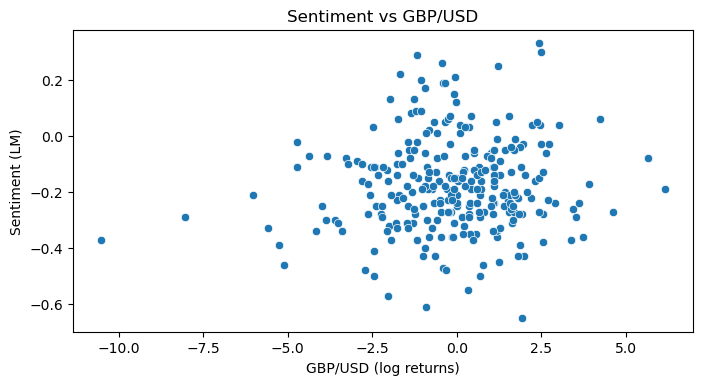

In [99]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs GBP/USD")
plt.xlabel("GBP/USD (log returns)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "GBP_USD",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [100]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg10 = np.polyfit(variables['GBP_USD'], variables['Sentiment_LM'], deg = 1)

# View output.
reg10

array([ 0.00656672, -0.17528331])

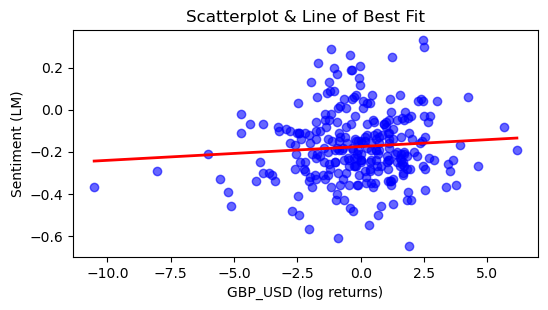

In [101]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend10 = np.polyval(reg10, variables['GBP_USD'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='GBP_USD',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("GBP_USD (log returns)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [102]:
# Pass linear regression through OLS methods.
test10 = ols('y10 ~ x10', data = variables).fit(cov_type='HC1')
# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust
 
# Print the regression table.
test10.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    y10   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.275
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.133
Time:                        07:19:24   Log-Likelihood:                 102.73
No. Observations:                 271   AIC:                            -201.5
Df Residuals:                     269   BIC:                            -194.2
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1753      0.010    -17.295      0.000      -0.195      -0.155
x10            0.0066      0.004      1.508      0.131      -0.002       0.015
==============================================================================
Omnibus:                        8.283   Durbin-Watson:                   1.435
Prob(Omnibus):                  0.016   Jarque-Bera (JB):                8.332
Skew:                           0.364   Prob(JB):                       0.0155
Kurtosis:                       3.455   Cond. No.                         2.08
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [103]:
# Extract Residuals
residuals10 = np.asarray(test10.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs GBP/USD) Breusch-Pagan test for testing for Heteroskedasticity

In [104]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test10 = het_breuschpagan(test10.resid, test10.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results10 = dict(zip(labels, bp_test10))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results10.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0765
LM p-value: 0.7821
F Statistic: 0.0759
F p-value: 0.7831


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs GBP/USD) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

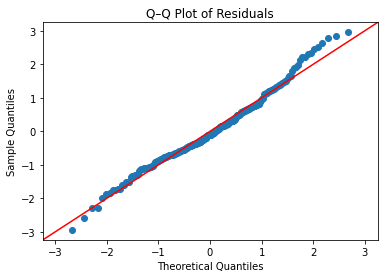

In [105]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals10, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that there are some skewness in the tails

In [106]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw10_p = shapiro(residuals10)[1]
jb10_p = jarque_bera(residuals10)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals10)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals10)[1])

Shapiro–Wilks p-value: 0.006951426851905259
Jarque–Bera p-value: 0.0155109529892002


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs GBP/USD – Regression diagnostics

The cloud is wide and diffuse, showing **no clear linear pattern** between GBP/USD log-returns and sentiment.

**OLS regression**  
- β = **0.0066**, p-value = **0.131**, 
- R² = **0.007** → the effect is small and **statistically insignificant**.

**Residual diagnostics**  
- **Breusch–Pagan p = 0.783** → no heteroskedasticity.  
- **Q–Q plot** → mild skewness in tails.  
- **Shapiro–Wilk p = 0.007** & **Jarque–Bera p = 0.015** → residuals **not normally distributed**, but OLS remains valid with HC1 robust errors.

GBP/USD log-returns do **not** significantly explain movements in LM sentiment.

## Observations from Single Linear Regression

No evidence of heteroskedasticity for all variables. The variance of the residuals is constant across all variables. This means the regression assumption of homoskedasticity holds. Since heteroskedasticity is not present, the standard errors are valid

There is skewness and kurtosis evident in all variables. The tests for Normality indicate that the residuals for all variables are not Normally Distributed

##### Significant variables:
- Unemployment (p-value 0.011)
- Wages Growth (p-value 0.029)
- House Price Index (p-value 0.013)

## Multiple Linear Regression (Sentiment LM)

##### Define the variables

In [107]:
# Define the dependent variable.
yLM = variables['Sentiment_LM'] 

# Define the independent variable.
XLM = variables[['Core_Inflation', 'Unemployment','Ave_Weekly_earnings_growth','GDP_growth','Benchmark_interest_rate',
                'Economic_Inactivity rate','House_Price_index','Consumer_Confidence','FTSE100','GBP_USD']]

In [108]:
# Specify the model.
multi = LinearRegression()  

# Fit the model.
multi.fit(XLM, yLM)

LinearRegression()

In [109]:
# Call the predictions for X (array).
multi.predict(XLM)

array([-0.20190935, -0.2181946 , -0.20606224, -0.26263763, -0.20574459,
       -0.20358063, -0.16895108, -0.14514988, -0.20743167, -0.18245009,
       -0.17946147, -0.16493011, -0.21997353, -0.15410599, -0.15768604,
       -0.24302606, -0.19970021, -0.19900621, -0.18713967, -0.18966647,
       -0.20828254, -0.21237054, -0.25513424, -0.16134118, -0.19987559,
       -0.18478893, -0.21712613, -0.11938123, -0.10688764, -0.17213889,
       -0.12814571, -0.16686807, -0.1736751 , -0.14929566, -0.17485296,
       -0.15902709, -0.12756502, -0.08502752, -0.16133995, -0.17546685,
       -0.14867599, -0.12448196, -0.12580853, -0.14124211, -0.15306403,
       -0.11221393, -0.17403324, -0.18731433, -0.22515879, -0.15050003,
       -0.17559703, -0.18870418, -0.14463197, -0.16626866, -0.08527824,
       -0.14523972, -0.12838406, -0.1158675 , -0.14074041, -0.120347  ,
       -0.13379792, -0.1177985 , -0.16607447, -0.16205029, -0.13243304,
       -0.1642689 , -0.14782917, -0.1739921 , -0.155608  , -0.13

In [39]:
# Call the predict method on the 'multi' model (likely a classifier or regressor)
# to generate predictions for the input data 'XLM' (which is an array of features)
multi.predict(XLM)

NameError: name 'multi' is not defined

In [110]:
# Checking the value of R-squared, intercept and coefficients.
print("R-squared: ", multi.score(XLM, yLM))
print("Intercept: ", multi.intercept_)
print("Coefficients:")

list(zip(XLM, multi.coef_))

R-squared:  0.07273083259824775
Intercept:  -0.21582010595069387
Coefficients:


[('Core_Inflation', -0.03196988117680301),
 ('Unemployment', -0.1658520481781183),
 ('Ave_Weekly_earnings_growth', 0.011953311154225649),
 ('GDP_growth', -0.009956556582863065),
 ('Benchmark_interest_rate', 0.03735220810753502),
 ('Economic_Inactivity rate', 0.06762927652243715),
 ('House_Price_index', 0.019763882655465213),
 ('Consumer_Confidence', 0.004997924254972501),
 ('FTSE100', 0.0022973393218372637),
 ('GBP_USD', 0.003595116885966177)]

##### Training and testing subsets with MLR

In [111]:
# Create train and test data sets.
x_train, x_test, y_train, y_test = train_test_split(XLM, yLM,
                                                    test_size=0.3,
                                                    random_state=42)

In [41]:
# Training the model using the 'statsmodel' OLS library.
# Fit the model with the added constant.
model = sm.OLS(y_train, sm.add_constant(x_train)).fit(cov_type='HC1') 
# White (1981) “HC1” function to ensure Heteroskedasticity robust

# Generate predictions using the fitted model on the test data
# We add a constant to the test data to match the model specification
Y_pred = model.predict(sm.add_constant(x_test)) 

# Generate a comprehensive summary of the regression model
# This includes coefficients, standard errors, t-stats, p-values, R-squared, etc.
print_model = model.summary()

# Print the summary statistics of the regression model
print(print_model)  

NameError: name 'sm' is not defined

**Significant predictors (p < 0.05):**
- **GDP Growth** (p = 0.030): Positive coefficient stronger economic momentum associates with more positive Bank sentiment
- **Consumer Confidence** (p = 0.019): Positive coefficient improved household sentiment correlates with less cautious communication
- **GBP/USD** (p = 0.016): Positive coefficient—sterling strength coincides with more positive Bank tone

**Marginally significant:**
- **Wages Growth** (p = 0.057): Positive effect near conventional significance threshold

**Not significant:**
- Core Inflation, Unemployment, Interest Rates, Economic Inactivity, House Prices, FTSE 100 all have p > 0.10

**Model fit:**
- Adjusted R² = 0.058 (~6% of sentiment variance explained)
- F-statistic significant (p = 0.001) confirming joint explanatory power

When all variables compete, broad economic indicators (GDP, confidence, exchange rates) dominate. Labour market variables (unemployment, wages), significant in isolation lose statistical power here—their effects likely operate through GDP and confidence rather than directly. Bank communication responds to aggregate economic conditions and household sentiment not mechanical inflation or unemployment targets.

In [113]:
print(multi.score(x_train, y_train)*100) # Print the R-squared value

9.020303469669921


### Run a regression test

In [114]:
# Run regression on the train subset.
mlr = LinearRegression()  

mlr.fit(x_train, y_train)

LinearRegression()

In [115]:
# Call the predictions for X in the train set.
y_pred_mlr = mlr.predict(x_train)  

# Print the predictions.
print("Prediction for test set: {}".format(y_pred_mlr)) 

Prediction for test set: [-0.0840304  -0.0792854  -0.12115495 -0.30678423 -0.18694666 -0.17673821
 -0.2187643  -0.34960075 -0.11838612 -0.16306066 -0.12914549 -0.19120163
 -0.21044109 -0.22759937 -0.11753017 -0.218559   -0.14790292 -0.14185132
 -0.24138591 -0.20272608 -0.14133293 -0.41933397 -0.24650268 -0.17555826
 -0.18205742 -0.24065467 -0.14600924 -0.17521332 -0.12805261 -0.21093684
 -0.14954849 -0.2109087  -0.17395062 -0.21477555 -0.08495527 -0.17746851
 -0.17395288 -0.15553038 -0.12710441 -0.24323474 -0.13396483 -0.14433171
 -0.3219754  -0.1630328  -0.16462353 -0.253195   -0.16871504 -0.12928379
 -0.18278583 -0.21149436 -0.14441589 -0.13815139 -0.21863494 -0.13553039
 -0.21952922 -0.19570703 -0.14412523 -0.26672765 -0.2041217  -0.21668972
 -0.20417823 -0.17801673 -0.18841477 -0.22024329 -0.19682334 -0.24962724
 -0.17500668 -0.13054285 -0.11921779 -0.2302846  -0.11480727 -0.13227854
 -0.16475203 -0.15773178 -0.1316655  -0.13241289 -0.23582756 -0.21364628
 -0.19462091 -0.18651489 -

In [116]:
# Print the R-squared value.
print(mlr.score(x_test, y_test)*100)  

-5.159469576036657


**R² = -5.16% :** The negative R² indicates the model performs worse than a horizontal line (mean prediction). This suggests **overfitting** the model learned noise specific to the training period rather than generalizable patterns. 
With only 189 observations and 10 predictors the signal-to-noise ratio is too low for robust out-of-sample prediction.
While the model identifies statistically significant relationships within the sample it cannot reliably forecast sentiment from macro variables alone. Bank communication responds to qualitative factors.

###### Check for multicollinearity

In [117]:
# import from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check multicollinearity.
x_temp = sm.add_constant(x_train)

# Create an empty DataFrame. 
vif = pd.DataFrame()

# Calculate the VIF for each value.
vif['VIF Factor'] = [variance_inflation_factor(x_temp.values,
                                               i) for i in range(x_temp.values.shape[1])]

# Create the feature columns.
vif['features'] = x_temp.columns

# Print the values to one decimal points.
print(vif.round(1))

    VIF Factor                    features
0          3.7                       const
1          1.1              Core_Inflation
2          1.1                Unemployment
3          1.1  Ave_Weekly_earnings_growth
4          1.5                  GDP_growth
5          1.3     Benchmark_interest_rate
6          1.1    Economic_Inactivity rate
7          1.2           House_Price_index
8          1.4         Consumer_Confidence
9          1.1                     FTSE100
10         1.2                     GBP_USD


#### VIF variables < 5 -> very little evidence of multi-collinearity 
- **Coefficients are stable**
- **Standard errors are not inflated**
- **Significance tests are reliable and Model interpretation is safe**

##### Evaluate the model

In [118]:
# Call the metrics.mean_absolute_error function.  
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(y_test, Y_pred))  

# Call the metrics.mean_squared_error function.
print('Mean Square Error (Final):', metrics.mean_squared_error(y_test, Y_pred)) 

Mean Absolute Error (Final): 0.1477762312599453
Mean Square Error (Final): 0.03300274496795072


**MAE = 0.148, MSE = 0.033.** On average, predictions deviate from actual sentiment by ~0.15 units (on a scale where sentiment typically ranges ±0.5). Error magnitude is moderate but acceptable for exploratory analysis.

## Multiple Linear Regression (Sentiment Finbert)

##### Define the variables

In [119]:
# Define the dependent variable.
yFIN = variables['Sentiment_Finbert'] 

# Define the independent variable.
XFIN = variables[['Core_Inflation', 'Unemployment','Ave_Weekly_earnings_growth','GDP_growth','Benchmark_interest_rate',
                'Economic_Inactivity rate','House_Price_index','Consumer_Confidence','FTSE100','GBP_USD']]

In [120]:
# Specify the model.
multi = LinearRegression()  

# Fit the model.
multi.fit(XFIN, yFIN)

LinearRegression()

In [121]:
# Call the predictions for X (array).
multi.predict(XFIN)

array([-0.08309109, -0.08984636, -0.11573536, -0.14331355, -0.11312946,
       -0.11793254, -0.0628712 , -0.05270542, -0.10245825, -0.07427626,
       -0.05241655, -0.05007534, -0.06575568, -0.06584593, -0.04912012,
       -0.07709741, -0.07491166, -0.0755713 , -0.077653  , -0.06115115,
       -0.08260327, -0.08232758, -0.11171224, -0.05541398, -0.07197507,
       -0.08052017, -0.10596658, -0.05624173, -0.05902484, -0.10203008,
       -0.071698  , -0.07832907, -0.09420937, -0.10145818, -0.09485197,
       -0.11899747, -0.05715557, -0.03526944, -0.07458163, -0.07152822,
       -0.0728117 , -0.05959582, -0.07423806, -0.07229288, -0.0534044 ,
       -0.040935  , -0.06747361, -0.08874895, -0.10534855, -0.07005339,
       -0.08463287, -0.0984097 , -0.05491481, -0.07299766, -0.02501394,
       -0.04405563, -0.07203973, -0.0368442 , -0.06975631, -0.05065855,
       -0.03527781, -0.05236935, -0.06045168, -0.07310776, -0.05957641,
       -0.07728158, -0.06715688, -0.09030994, -0.07326989, -0.05

In [122]:
# Checking the value of R-squared, intercept and coefficients.
print("R-squared: ", multi.score(XFIN, yFIN))
print("Intercept: ", multi.intercept_)
print("Coefficients:")

list(zip(XFIN, multi.coef_))

R-squared:  0.10483433288253519
Intercept:  -0.08792564741695548
Coefficients:


[('Core_Inflation', -0.0020326993760793263),
 ('Unemployment', -0.11373618808375346),
 ('Ave_Weekly_earnings_growth', 0.0023090778603921088),
 ('GDP_growth', -4.9078355025050155e-06),
 ('Benchmark_interest_rate', 0.08690597673078561),
 ('Economic_Inactivity rate', 0.06656636830908584),
 ('House_Price_index', 0.010004634495226344),
 ('Consumer_Confidence', 0.0010753759920221141),
 ('FTSE100', 0.0020047659581654974),
 ('GBP_USD', 0.002442510900112374)]

##### Training and testing subsets with MLR

In [123]:
# Create train and test data sets.
x_train2, x_test2, y_train2, y_test2 = train_test_split(XFIN, yFIN,
                                                    test_size=0.3,
                                                    random_state=42)

In [124]:
# Training the model using the 'statsmodel' OLS library.
# Fit the model with the added constant.
model = sm.OLS(y_train2, sm.add_constant(x_train2)).fit(cov_type='HC1')
# White (1981) “HC1” function to ensure Heteroskedasticity robust

# Set the predicted response vector.
Y_pred2 = model.predict(sm.add_constant(x_test2)) 

# Call a summary of the model.
print_model = model.summary()

# Print the summary.
print(print_model)  

                            OLS Regression Results                            
Dep. Variable:      Sentiment_Finbert   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     3.190
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           0.000859
Time:                        07:20:44   Log-Likelihood:                 208.96
No. Observations:                 189   AIC:                            -395.9
Df Residuals:                     178   BIC:                            -360.3
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

#### **Significant predictors (p < 0.05):**
- **Benchmark Interest Rate** (p = 0.033): Positive coefficient rate increases associate with more positive FinBERT sentiment
- **Consumer Confidence** (p = 0.047): Positive coefficient—consistent with LM model
- **FTSE 100** (p = 0.052): Marginally significant—equity market strength correlates with positive tone
- **GBP/USD** (p = 0.022): Positive coefficient—sterling strength associates with improved sentiment

#### **Key differences from LM model:**
- **Interest rates** now significant 
- **FTSE 100** emerges as relevant (financial market sentiment matters for FinBERT's contextual analysis)
- **GDP Growth** loses significance

**Model fit:**
- R² = 0.160 (16%), Adjusted R² = 0.112 (11.2%)
- Better fit than LM model suggesting FinBERT captures macro relationships more effectively

FinBERT sentiment responds more directly to **financial market conditions** (interest rates, equity prices, FX) and **confidence indicators**, whereas LM sentiment reflects **labour market and real economy variables**. This divergence confirms the two methods capture different dimensions of communication tone.

In [125]:
print(multi.score(x_train2, y_train2)*100) # Print the R-squared value

12.715993397736302


**Training R² = 12.72% :** The FinBERT model explains more training variance than the LM model (9%)

##### Check for multicollinearity

In [126]:
# import from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check multicollinearity.
x_temp2 = sm.add_constant(x_train2)

# Create an empty DataFrame. 
vif = pd.DataFrame()

# Calculate the VIF for each value.
vif['VIF Factor'] = [variance_inflation_factor(x_temp2.values,
                                               i) for i in range(x_temp2.values.shape[1])]

# Create the feature columns.
vif['features'] = x_temp2.columns

# Print the values to one decimal points.
print(vif.round(1))

    VIF Factor                    features
0          3.7                       const
1          1.1              Core_Inflation
2          1.1                Unemployment
3          1.1  Ave_Weekly_earnings_growth
4          1.5                  GDP_growth
5          1.3     Benchmark_interest_rate
6          1.1    Economic_Inactivity rate
7          1.2           House_Price_index
8          1.4         Consumer_Confidence
9          1.1                     FTSE100
10         1.2                     GBP_USD


### VIF variables < 5 -> very little evidence of multi-collinearity 
- **Coefficients are stable**
- **Standard errors are not inflated**
- **Significance tests are reliable and Model interpretation is safe**

##### Evaluate the model

In [127]:
# Call the metrics.mean_absolute_error function.  
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(y_test2, Y_pred2))  

# Call the metrics.mean_squared_error function.
print('Mean Square Error (Final):', metrics.mean_squared_error(y_test2, Y_pred2)) 

Mean Absolute Error (Final): 0.08450894574064176
Mean Square Error (Final): 0.011300494844989144


**MAE = 0.085**, **MSE = 0.011** : FinBERT achieves lower error than LM, confirming better fit. However, both models show modest R²—sentiment shaped by factors beyond these ten macro indicators.

### Rolling Correlations 
12-month rolling correlations examine how the sentiment-macro relationship evolves over time. We focus on the four variables identified as most significant in earlier regressions.

### Sentiment (LM) vs Variables of interest

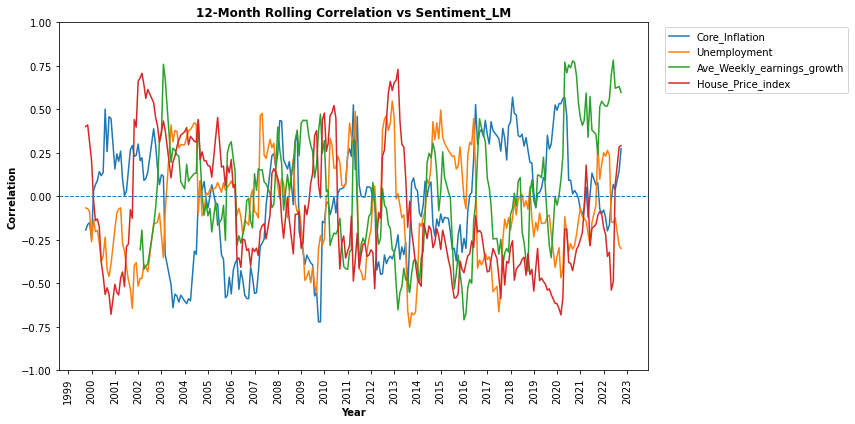

In [129]:
# Load the CSV 
variables = pd.read_csv('variables_transformed.csv')

# Convert Month-Year to datetime 
variables['Month / Year'] = pd.to_datetime(variables['Month / Year'], format='%b-%y')

# Set date as index so rolling correlation uses real time
variables = variables.set_index('Month / Year')

# Drop non-numeric column
variables_LM = variables.drop(columns=['Sentiment_Finbert'])

# Selected variables
selected_vars = [
    'Core_Inflation',
    'Unemployment',
    'Ave_Weekly_earnings_growth',
    'House_Price_index'
]

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col in selected_vars:
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col)

plt.title(f"{window}-Month Rolling Correlation vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


The correlation between MPC sentiment and macro indicators is **highly time-varying** shifting direction and strength across different economic phases.

- **Unemployment** and **Wages growth** show the **most persistent cyclical co-movement** with sentiment. Correlations tighten during major stress periods **Global Financial Crisis (2008–09)** and **COVID-19 (2020)**  
- **House prices** generate **short, sharp spikes**, typically around episodes when housing or financial stability dominated public debate (early 2000s, post-2013).  
- **Core inflation** alternates between positive and negative regimes, sentiment does **not follow inflation mechanically** but shifts with the wider economic story.
 
Consistent with the presentation, the Bank’s communication appears to **adapt to the dominant macro narrative at each point in time** focusing on labour-market stress during crises or on housing and financial conditions when relevant rather than reacting to any single indicator in a fixed rule-based way.

### Sentiment (LM) vs Unemployment

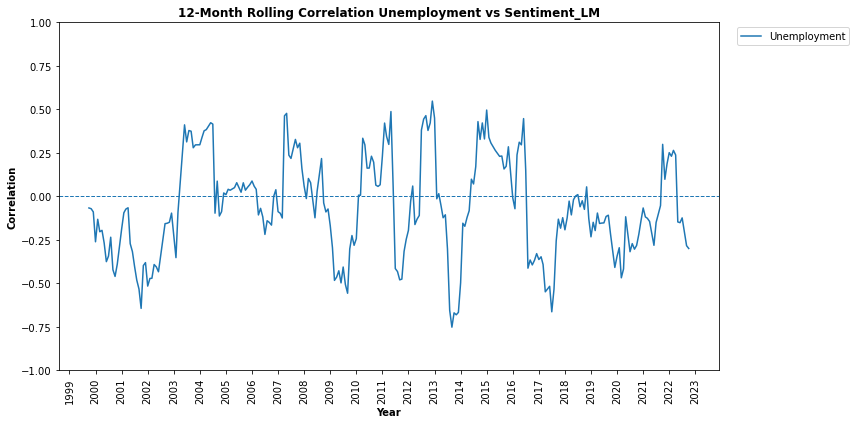

In [130]:
# Selected variables
selected_vars = [
    'Unemployment'
]

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col in selected_vars:
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col)

plt.title(f"{window}-Month Rolling Correlation Unemployment vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


Mostly **negative** over time with **sharper dips** during major stress periods **GFC** and **COVID**, meaning sentiment weakens when labour market conditions deteriorate.  
The relationship is cyclical rather than constant.

### Sentiment (LM) vs Wages growth

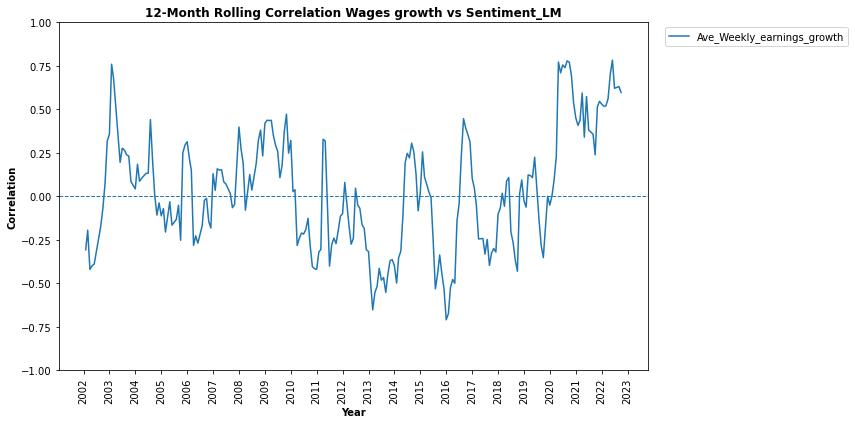

In [131]:
# Selected variables
selected_vars = [
    'Ave_Weekly_earnings_growth'
]

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col in selected_vars:
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col)

plt.title(f"{window}-Month Rolling Correlation Wages growth vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

Wages growth tracks sentiment more closely in **recovery phases**, especially post-2013 and post-2020 which is consistent with the Bank **emphasising household income** conditions when growth narratives dominate

### Sentiment (LM) vs House Price Index

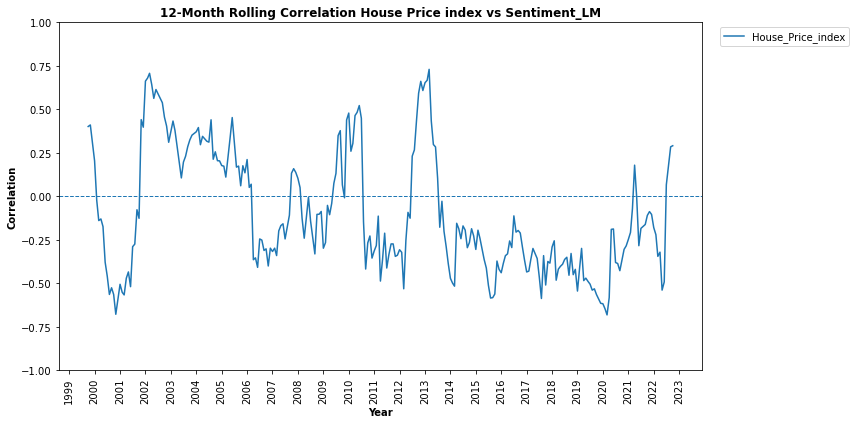

In [132]:
# Selected variables
selected_vars = [
    'House_Price_index'
]

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col in selected_vars:
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col)

plt.title(f"{window}-Month Rolling Correlation House Price index vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Correlation with all three variables

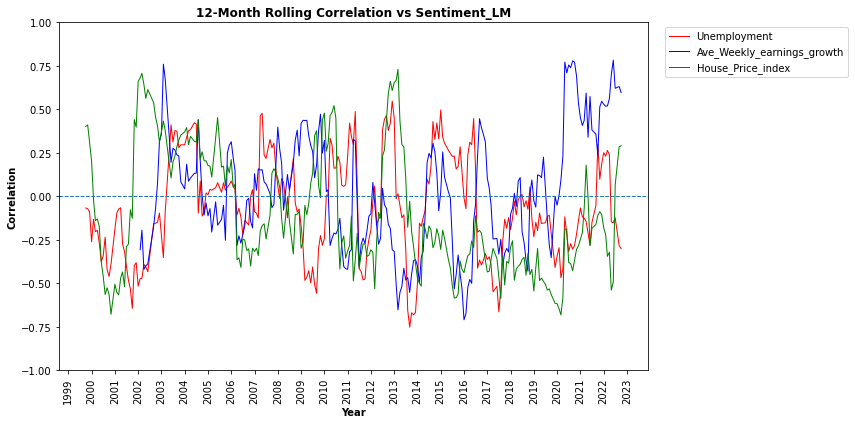

In [133]:
# Selected variables
selected_vars = [
    'Unemployment',
    'Ave_Weekly_earnings_growth',
    'House_Price_index'
]

# Colors corresponding to each variable
colors = ['red', 'blue', 'green']

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col, color in zip(selected_vars, colors):
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col, color=color, linewidth=1)  # Thinner line

plt.title(f"{window}-Month Rolling Correlation vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

Labour-market variables move **together in crises and recoveries** but none shows a stable regime illustrating that communication adapts to the macro narrative of each period rather than fixed signals.

### Unemployment vs House Price Index

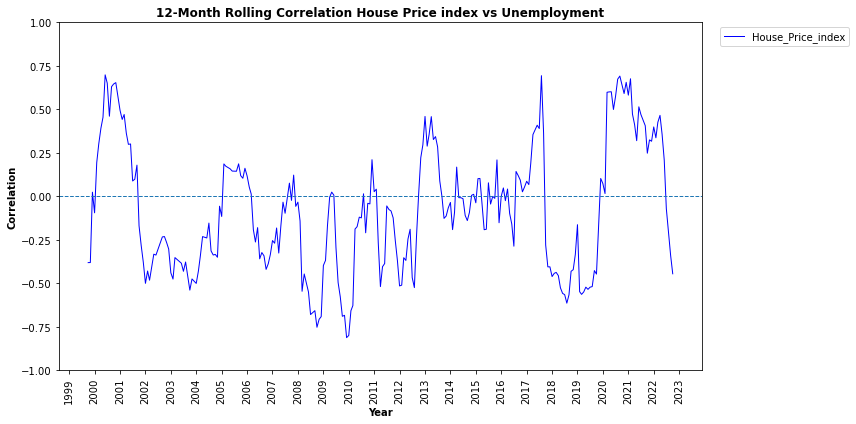

In [134]:
# Selected variables
selected_vars = [
    'House_Price_index'
]

# Colors corresponding to each variable
colors = ['blue']

target = 'Unemployment'
window = 12

plt.figure(figsize=(12, 6))

for col, color in zip(selected_vars, colors):
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col, color=color, linewidth=1)  # Thinner line

plt.title(f"{window}-Month Rolling Correlation House Price index vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### GDP Growth vs Consumer Confidence

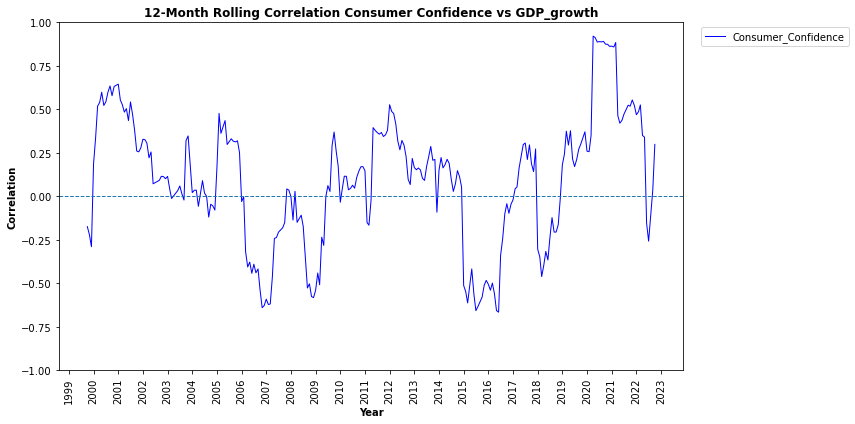

In [135]:
# Selected variables
selected_vars = [
    'Consumer_Confidence'
]

# Colors corresponding to each variable
colors = ['blue']

target = 'GDP_growth'
window = 12

plt.figure(figsize=(12, 6))

for col, color in zip(selected_vars, colors):
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col, color=color, linewidth=1)  # Thinner line

plt.title(f"{window}-Month Rolling Correlation Consumer Confidence vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Core Inflation vs Unemployment (Phillips curve)

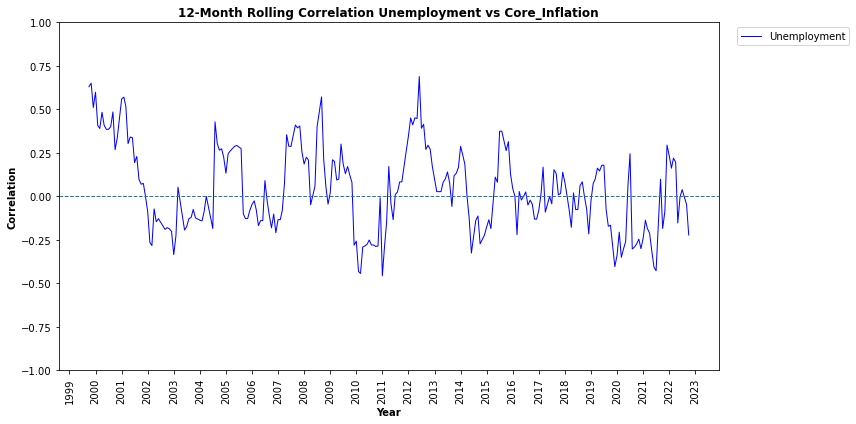

In [136]:
# Selected variables
selected_vars = [
    'Unemployment'
]

# Colors corresponding to each variable
colors = ['blue']

target = 'Core_Inflation'
window = 12

plt.figure(figsize=(12, 6))

for col, color in zip(selected_vars, colors):
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col, color=color, linewidth=1)  # Thinner line

plt.title(f"{window}-Month Rolling Correlation Unemployment vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

Across all variables correlations are highly time-varying : the Bank’s communication shifts with the dominant macro narrative of each period rather than responding mechanically to any indicator.

<div class="alert alert-block alert-info">
Notebook End

## **4. Financial Stability Report Sentiment Analysis**

***

<div class="alert alert-block alert-info">
Notebook Start

This notebook analyses the tone and sentiment of the Bank of England Financial Stability Reports (1998–2022) using the Loughran–McDonald finance-specific dictionary.

**Purpose:**  
To measure changes in language tone over time (e.g., positive, negative, uncertainty, litigious, constraining, strong, weak) and compute comparable indicators across reports.

**Data Sources:**  
- PDF reports stored in `pdfs/financial_stability/`  
- Dictionary: `LSE_DA_BoE_Employer_project_Sentiment-labelled_wordlist-2-1.xlsx`

**Outputs:**  
- **Table 1: Document-level sentiment summary** - one row per report with all indicators
- **Table 2: Term-level matches** - term-level matches for auditability
- Visual trends over time

#### Outputs from this section:
- 

In [1]:
# !pip install pandas numpy pymupdf

import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

### Configuration

We place the notebook at the project root (same folder as the dictionary file).  

In [2]:
# --- Paths
PDF_FOLDER = Path("pdfs/financial_stability")   # your 50 FSR PDFs
DICT_XLSX  = Path("LSE_DA_BoE_Employer_project_Sentiment-labelled_wordlist-2-1.xlsx")
DICT_SHEET = "Loughran-McDonald_MasterDiction"
OUT_DIR    = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Presentation options
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

### Load the LM dictionary

We use the columns: `Word`, and binary flags for `Negative, Positive, Uncertainty, Litigious, Strong, Weak, Constraining`.  
We lower-case words and build **sets** per category for fast, simple matching.

In [3]:
# Load lexicon
lex = pd.read_excel(DICT_XLSX, sheet_name=DICT_SHEET)
lex.columns = [c.strip() for c in lex.columns]

required_cols = {"Word","Negative","Positive","Uncertainty","Litigious","Strong","Weak","Constraining"}
missing = required_cols - set(lex.columns)
if missing:
    raise ValueError(f"Dictionary is missing columns: {missing}")

# Tidy + keep only rows with at least one tag
label_cols = [c for c in lex.columns if c != "Word"]
lex[label_cols] = lex[label_cols].fillna(0)
lex["Word"] = lex["Word"].astype(str).str.strip().str.lower()
lex = lex[(lex[label_cols] != 0).any(axis=1)].copy()

LM = {"positive": set(lex.loc[lex["Positive"] != 0, "Word"]),
    "negative": set(lex.loc[lex["Negative"] != 0, "Word"]),
    "uncertainty": set(lex.loc[lex["Uncertainty"] != 0, "Word"]),
    "litigious": set(lex.loc[lex["Litigious"] != 0, "Word"]),
    "strong": set(lex.loc[lex["Strong"] != 0, "Word"]),
    "weak": set(lex.loc[lex["Weak"] != 0, "Word"]),
    "constraining": set(lex.loc[lex["Constraining"] != 0, "Word"]),}

{k: len(v) for k, v in LM.items()}  # quick sanity check of set sizes

{'positive': 358,
 'negative': 2355,
 'uncertainty': 297,
 'litigious': 905,
 'strong': 19,
 'weak': 27,
 'constraining': 184}

>### Dictionary sanity check
>
>The dictionary successfully loaded and categories have the expected distribution of terms.  
>This confirms that the **Loughran-McDonald finance-specific lexicon** is ready for use.
>
>| Category | Interpretation |
>|-----------|----------------|
>| **Negative (2,355)** | Largest category, reflecting the wide range of risk- and loss-related terms common in financial text. We expect this to dominate counts, so sentiment should be interpreted in relative rather than absolute terms. |
>| **Positive (358)** | Much smaller set. Positive tone will naturally appear less frequently; therefore, *per-1,000* rates and the **Net Sentiment Index** (Positive - Negative / Positive + Negative) will be key to comparing balance of tone. |
>| **Uncertainty (297)** | Core for our analysis - these words typically signal doubt or instability (“may”, “uncertain”, “risk”, etc.) and often rise during stress periods. |
>| **Litigious (905)** | Indicates references to legal, regulatory, or supervisory issues. High counts may reflect heightened compliance or enforcement focus. |
>| **Strong (19)** & **Weak (27)** | Small sets capturing forcefulness of language (e.g., “must”, “require” vs. “might”, “could”). They feed into the **Net Strength Index** (Strong - Weak / Strong + Weak). |
>| **Constraining (184)** | Reflects language about restrictions or limitations, often useful to interpret tightening policy or regulatory conditions. |
>
>**Summary:**  
>The lexicon is imbalanced by design - financial texts use far more negative or risk-oriented words than positive ones.  
>This is expected and not a problem, but it’s important context when interpreting results later.  
>
>Next, we’ll move to **text extraction and normalisation**, where we’ll test how the text looks once pulled from a sample Financial Stability Report.

### Extract & normalise text

- Extract text from all pages with PyMuPDF.
- Normalise: lowercase, hyphen -> space, remove punctuation (keep apostrophes), collapse spaces.
- Tokenise by whitespace.  
These choices keep the process **interpretable** and aligned with a dictionary of single words.

In [4]:
# PDF text extraction, normalisation, tokenisation

# Install PyMuPDF (fitz) if missing
import sys, subprocess
try:
    import fitz  # PyMuPDF
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pymupdf"])
    import fitz

import re
from pathlib import Path

# remove punctuation (keep letters, numbers, underscore, spaces, apostrophes)
PUNCT_RE = re.compile(r"[^\w\s']+", flags=re.UNICODE)

def extract_text_from_pdf(pdf_path: Path) -> str:
    """Extract plain text from all pages of a PDF."""
    chunks = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            chunks.append(page.get_text("text"))
    return "\n".join(chunks)

def normalise_text(s: str) -> str:
    """Lowercase, hyphen→space, strip punctuation, collapse spaces."""
    s = s.lower().replace("-", " ")
    s = PUNCT_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenise(s: str):
    """Whitespace tokenisation."""
    return s.split()

### Step 1: Test text extraction and cleaning on a single Financial Stability Report

Before processing all 50 reports, we test the workflow on one file (for example the most recent FSR).  
This helps us check:
- that text extraction works correctly with PyMuPDF,
- that the text looks clean and readable,
- that tokenisation (splitting into words) behaves as expected.

We’ll extract:
1. The first 500 characters of the raw text (to confirm layout)
2. The first 500 characters after normalisation
3. The number of tokens (words) identified

In [5]:
# pick one file (latest in the folder)
sample_pdf = sorted(PDF_FOLDER.glob("*.pdf"))[-1]
print("Testing on:", sample_pdf.name)

# extract text
raw_text = extract_text_from_pdf(sample_pdf)

# normalise and tokenise
norm_text = normalise_text(raw_text)
tokens = tokenise(norm_text)

# preview results
print("\n--- Raw text (first 500 chars) ---")
print(raw_text[:500])
print("\n--- Normalised text (first 500 chars) ---")
print(norm_text[:500])
print(f"\nTotal tokens (words): {len(tokens):,}")

Testing on: FSR-OCTOBER-2008.pdf

--- Raw text (first 500 chars) ---
Financial Stability Report
October 2008 | Issue No. 24

BANK OF ENGLAND
Financial Stability Report
October 2008  |  Issue No. 24
The Bank of England has two core purposes — monetary stability and financial stability.  The two
are connected because serious disruption in the financial system can affect the implementation
and effectiveness of monetary policy, while macroeconomic stability helps reduce risks to
financial stability.
The Bank’s responsibilities for monetary stability are set out in th

--- Normalised text (first 500 chars) ---
financial stability report october 2008 issue no 24 bank of england financial stability report october 2008 issue no 24 the bank of england has two core purposes monetary stability and financial stability the two are connected because serious disruption in the financial system can affect the implementation and effectiveness of monetary policy while macroeconomic stability helps reduce

>### Text extraction and normalisation - insights
>
>The extraction process works correctly.
>
>- **Raw text preview:** Clean and readable, showing page text with only minor spacing issues.  
>- **Normalised text:** Fully lowercase, punctuation removed, and hyphens replaced with spaces - ready for token matching.  
>- **Total tokens (aprox. 36,700):** This is fully plausible for a full-length Financial Stability Report (usually 30-40k words).  
>
>**Conclusion:**  
>The text extraction and cleaning pipeline works as intended.  
>We can now move on to the next stage - matching tokens against the Loughran-McDonald dictionary to count Positive, Negative, Uncertainty, Litigious, Strong, Weak, and >Constraining words and then compute the sentiment indices.

### Step 2: Single-report sentiment test

We take the already extracted and cleaned text from one report, match tokens against the LM dictionary, and compute:
- category counts
- per-1,000 rates
- Net Sentiment = (Positive - Negative) / (Positive + Negative)
- Net Strength = (Strong - Weak) / (Strong + Weak)

This validates the counting and the maths before scaling to all 50 reports.

In [6]:
from collections import Counter
import pandas as pd
import numpy as np

tok_counts = Counter(tokens)

# category counts
cat_counts = {}
for cat, terms in LM.items():
    hits = set(tok_counts).intersection(terms)
    cat_counts[cat] = sum(tok_counts[w] for w in hits)

total_tokens = len(tokens)
perk = 0 if total_tokens == 0 else 1000.0 / total_tokens

# per-1,000 rates
cat_perk = {f"{k}_per_1000": v * perk for k, v in cat_counts.items()}

# indices
pos = cat_counts.get("positive", 0)
neg = cat_counts.get("negative", 0)
strong = cat_counts.get("strong", 0)
weak = cat_counts.get("weak", 0)

denom_sent = pos + neg
net_sent_index = np.nan if denom_sent == 0 else (pos - neg) / denom_sent

denom_str = strong + weak
net_strength_index = np.nan if denom_str == 0 else (strong - weak) / denom_str

# assemble a tidy one-row summary
row = {"document": sample_pdf.stem,
    "tokens_total": total_tokens,
    **cat_counts,
    **cat_perk,
    "net_sent_index": net_sent_index,
    "net_strength_index": net_strength_index,}
single_summary = pd.DataFrame([row]).T
single_summary.columns = ["value"]

print(f"Report: {sample_pdf.name}")
display(single_summary)

Report: FSR-OCTOBER-2008.pdf


,value
document,FSR-OCTOBER-2008
tokens_total,36707
positive,345
negative,1033
uncertainty,505
litigious,114
strong,94
weak,125
constraining,141
positive_per_1000,9.398752


>The 2008 FSR shows a clearly negative and uncertain tone, aligning with the context of the financial crisis.  
>These numbers behave exactly as expected, validating both the dictionary and the calculation logic.
>
>Next, we can confidently scale this process to all 50 reports (1998-2022) to observe tone shifts over time.

### Step 3: Full corpus run (1998–2022)

Process every PDF in `pdfs/financial_stability/`, compute category rates per 1,000 and the two indices, and save:
- `outputs/fs_documents_summary.csv` - one row per report
- `outputs/fs_term_matches_long.csv` - every matched term per document (for audit)

In [7]:
from collections import Counter
import numpy as np
import pandas as pd

summary_rows = []
long_rows = []

pdf_files = sorted(PDF_FOLDER.glob("*.pdf"))
print(f"Found {len(pdf_files)} PDFs.")

for i, p in enumerate(pdf_files, start=1):
    print(f"Processing report {i} of {len(pdf_files)}: {p.name}")
    try:
        raw = extract_text_from_pdf(p)
        norm = normalise_text(raw)
        toks = tokenise(norm)
        tc = Counter(toks)

        # category counts and term matches
        per_cat = {}
        for cat, terms in LM.items():
            hits = set(tc).intersection(terms)
            count = sum(tc[w] for w in hits)
            per_cat[cat] = count
            for w in hits:
                long_rows.append({
                    "section": "financial_stability",
                    "document": p.stem,
                    "category": cat,
                    "term": w,
                    "count": tc[w]})

        total = len(toks)
        if total == 0:
            continue

        words_per_thousand = 1000.0 / total

        pos = per_cat.get("positive", 0)
        neg = per_cat.get("negative", 0)
        strong = per_cat.get("strong", 0)
        weak = per_cat.get("weak", 0)

        if (pos + neg) > 0:
            net_sent = (pos - neg) / (pos + neg)
        else:
            net_sent = None

        if (strong + weak) > 0:
            net_strength = (strong - weak) / (strong + weak)
        else:
            net_strength = None

        summary_rows.append({
            "section": "financial_stability",
            "document": p.stem,
            "tokens_total": total,
            "positive_per_1000": per_cat.get("positive", 0) * words_per_thousand,
            "negative_per_1000": per_cat.get("negative", 0) * words_per_thousand,
            "uncertainty_per_1000": per_cat.get("uncertainty", 0) * words_per_thousand,
            "litigious_per_1000": per_cat.get("litigious", 0) * words_per_thousand,
            "constraining_per_1000": per_cat.get("constraining", 0) * words_per_thousand,
            "strong_per_1000": per_cat.get("strong", 0) * words_per_thousand,
            "weak_per_1000": per_cat.get("weak", 0) * words_per_thousand,
            "net_sent_index": net_sent,
            "net_strength_index": net_strength,
            "matched_per_1000": sum(per_cat.values()) * words_per_thousand})

    except Exception as e:
        print(f"Error reading {p.name}: {e}")
        summary_rows.append({
            "section": "financial_stability",
            "document": p.stem,
            "tokens_total": 0,
            "error": str(e)})

df_summary = pd.DataFrame(summary_rows).sort_values("document").reset_index(drop=True)
df_long    = pd.DataFrame(long_rows).sort_values(["document","category","term"]).reset_index(drop=True)

OUT_DIR.mkdir(parents=True, exist_ok=True)
df_summary.to_csv(OUT_DIR / "fs_documents_summary.csv", index=False)
df_long.to_csv(OUT_DIR / "fs_term_matches_long.csv", index=False)

print("Saved:", OUT_DIR / "fs_documents_summary.csv")
print("Saved:", OUT_DIR / "fs_term_matches_long.csv")
display(df_summary.head())

Found 50 PDFs.
Processing report 1 of 50: FSR-APRIL-2007.pdf
Processing report 2 of 50: FSR-AUGUST-2020.pdf
Processing report 3 of 50: FSR-DECEMBER-2000.pdf
Processing report 4 of 50: FSR-DECEMBER-2001.pdf
Processing report 5 of 50: FSR-DECEMBER-2002.pdf
Processing report 6 of 50: FSR-DECEMBER-2003.pdf
Processing report 7 of 50: FSR-DECEMBER-2004.pdf
Processing report 8 of 50: FSR-DECEMBER-2005.pdf
Processing report 9 of 50: FSR-DECEMBER-2009.pdf
Processing report 10 of 50: FSR-DECEMBER-2010.pdf
Processing report 11 of 50: FSR-DECEMBER-2011.pdf
Processing report 12 of 50: FSR-DECEMBER-2014.pdf
Processing report 13 of 50: FSR-DECEMBER-2015.pdf
Processing report 14 of 50: FSR-DECEMBER-2019.pdf
Processing report 15 of 50: FSR-DECEMBER-2020.pdf
Processing report 16 of 50: FSR-DECEMBER-2021.pdf
Processing report 17 of 50: FSR-DECEMBER-2022.pdf
Processing report 18 of 50: FSR-JULY-2006.pdf
Processing report 19 of 50: FSR-JULY-2015.pdf
Processing report 20 of 50: FSR-JULY-2016.pdf
Processing 

,section,document,tokens_total,positive_per_1000,negative_per_1000,uncertainty_per_1000,litigious_per_1000,constraining_per_1000,strong_per_1000,weak_per_1000,net_sent_index,net_strength_index,matched_per_1000
0,financial_stability,FSR-APRIL-2007,38389,11.930501,28.680091,27.846519,2.630962,2.839355,1.120113,7.840788,-0.412444,-0.750000,82.888327
1,financial_stability,FSR-AUGUST-2020,61528,8.565206,30.506436,18.853205,5.233390,4.924587,2.730464,9.134053,-0.561564,-0.539726,79.947341
2,financial_stability,FSR-DECEMBER-2000,105317,12.827939,24.516460,19.711917,4.234834,2.468737,2.269339,6.997921,-0.312993,-0.510246,73.027147
3,financial_stability,FSR-DECEMBER-2001,125641,11.469186,22.691637,22.564290,4.942654,3.263266,2.077347,7.815920,-0.328518,-0.580048,74.824301
4,financial_stability,FSR-DECEMBER-2002,115094,11.182164,24.840565,20.061862,5.986411,4.031487,2.806402,6.499036,-0.379161,-0.396825,75.407927


### Step 4: Quick QA on the full outputs
Sanity-check coverage and find the reports with the highest Uncertainty and Negative rates. This helps spot extraction issues and confirms face validity.

In [8]:
cols = ["document","tokens_total",
    "uncertainty_per_1000","negative_per_1000","positive_per_1000",
    "litigious_per_1000","constraining_per_1000",
    "net_sent_index","net_strength_index","matched_per_1000"]

print("Top 6 by uncertainty_per_1000")
display(df_summary.sort_values("uncertainty_per_1000", ascending=False)[cols].head(6))

print("\nTop 6 by negative_per_1000")
display(df_summary.sort_values("negative_per_1000", ascending=False)[cols].head(6))

print("\nBasic ranges")
summary_ranges = df_summary[cols[2:]].describe().T[["min","25%","50%","75%","max"]]
display(summary_ranges.round(3))

Top 6 by uncertainty_per_1000


,document,tokens_total,uncertainty_per_1000,negative_per_1000,positive_per_1000,litigious_per_1000,constraining_per_1000,net_sent_index,net_strength_index,matched_per_1000
17,FSR-JULY-2006,36526,32.634288,28.445491,9.664349,1.724799,1.724799,-0.492816,-0.795455,86.239939
0,FSR-APRIL-2007,38389,27.846519,28.680091,11.930501,2.630962,2.839355,-0.412444,-0.750000,82.888327
6,FSR-DECEMBER-2004,86268,24.678908,17.179024,13.701488,6.329114,2.619743,-0.112613,-0.590734,73.515093
10,FSR-DECEMBER-2011,38487,24.605711,26.684335,10.419103,5.534336,4.676904,-0.438375,-0.660606,80.494713
48,FSR-OCTOBER-2007,43060,24.500697,27.426846,10.078960,2.136554,4.110543,-0.462539,-0.490099,77.635857
32,FSR-JUNE-2011,32401,24.412827,25.462177,11.604580,6.049196,4.228265,-0.373855,-0.801325,81.077745



Top 6 by negative_per_1000


,document,tokens_total,uncertainty_per_1000,negative_per_1000,positive_per_1000,litigious_per_1000,constraining_per_1000,net_sent_index,net_strength_index,matched_per_1000
16,FSR-DECEMBER-2022,29525,17.984759,31.058425,10.635055,3.996613,2.811177,-0.489846,-0.122951,74.750212
1,FSR-AUGUST-2020,61528,18.853205,30.506436,8.565206,5.233390,4.924587,-0.561564,-0.539726,79.947341
39,FSR-MAY-2008,48407,23.281757,30.264218,11.899106,2.540955,3.863078,-0.435571,-0.454006,78.810916
22,FSR-JULY-2022,21709,24.137455,30.171818,8.613939,2.579575,3.869363,-0.555819,-0.330508,80.243217
40,FSR-MAY-2020,35132,17.960833,29.118752,6.062849,1.593988,5.038142,-0.655340,-0.651652,69.253103
0,FSR-APRIL-2007,38389,27.846519,28.680091,11.930501,2.630962,2.839355,-0.412444,-0.750000,82.888327



Basic ranges


,min,25%,50%,75%,max
uncertainty_per_1000,13.758,17.831,19.579,21.526,32.634
negative_per_1000,14.928,19.800,23.008,25.932,31.058
positive_per_1000,6.063,10.127,11.647,12.370,15.635
litigious_per_1000,1.594,3.939,4.688,5.969,7.804
constraining_per_1000,1.725,3.169,4.136,4.813,7.227
net_sent_index,-0.655,-0.408,-0.315,-0.253,-0.113
net_strength_index,-0.801,-0.578,-0.466,-0.332,-0.109
matched_per_1000,53.810,69.270,73.041,76.787,86.240


>### QA
>
>**Face validity**
>- Highest **uncertainty** per 1,000 shows up in FSR-JULY-2006 and FSR-APRIL-2007: consistent with pre-crisis stress signals.
>- Highest **negative** per 1,000 includes FSR-DECEMBER-2022, FSR-AUGUST-2020, FSR-MAY-2008, FSR-JULY-2022, FSR-MAY-2020, FSR-APRIL-2007: this lines up with market turmoil (GFC, COVID, Russia's invasion of Ukraine & LDI/2022).
>
>**Ranges (across all reports)**
>- Uncertainty per 1,000: ~13.8 -> 32.6 (median ~19.6)
>- Negative per 1,000: ~14.9 -> 31 (median ~23.1)
>- Positive per 1,000: ~6.1 -> 15.6 (median ~11.6)
>- Net Sentiment index: typically **negative** (median around -0.32)
>- Net Strength index: generally **cautious** (median around -0.47)
>
>**Sanity checks**
>- Token totals are in the tens of thousands -> extraction looks good.
>- Matched per 1,000 sits ~54–86 -> dictionary coverage is stable.
>- No obvious outliers demanding exclusions right now.

### Step 4.1: Chronological order

#### Step A: Parse month & year from filenames

**Why:** We want a proper time axis to sort reports and view trends over time.

**What we assume:** Filenames like `FSR-DECEMBER-2019.pdf`, `FSR-JULY-2006.pdf`, `FSR-OCTOBER-2008.pdf`.

**What we’ll do next (in the code cell below this):**
1) Extract the 4-digit year from `document`.
2) Extract the month name (JANUARY…DECEMBER).
3) Map the month name -> month number (1-12).

In [9]:
month_map = {"JANUARY":1,"FEBRUARY":2,"MARCH":3,"APRIL":4,"MAY":5,"JUNE":6,
    "JULY":7,"AUGUST":8,"SEPTEMBER":9,"OCTOBER":10,"NOVEMBER":11,"DECEMBER":12}

name_upper = df_summary["document"].str.upper()

df_summary["year"] = pd.to_numeric(
    name_upper.str.extract(r"(\d{4})", expand=False), errors="coerce")
df_summary["month_name"] = name_upper.str.extract(
    r"(JANUARY|FEBRUARY|MARCH|APRIL|MAY|JUNE|JULY|AUGUST|SEPTEMBER|OCTOBER|NOVEMBER|DECEMBER)",
    expand=False)
df_summary["month"] = df_summary["month_name"].map(month_map)
df_summary["report_date"] = pd.to_datetime(
    dict(year=df_summary["year"], month=df_summary["month"].fillna(12), day=1),
    errors="coerce")

df_summary = df_summary.sort_values("report_date").reset_index(drop=True)
df_summary.to_csv(OUT_DIR / "fs_documents_summary.csv", index=False)
df_summary[["document","report_date","negative_per_1000","uncertainty_per_1000","net_sent_index"]].head(8)

,document,report_date,negative_per_1000,uncertainty_per_1000,net_sent_index
0,FSR-MAY-1998,1998-05-01,18.991600,19.491379,-0.210043
1,FSR-NOVEMBER-1998,1998-11-01,16.487194,16.406076,-0.172314
2,FSR-JUNE-1999,1999-06-01,23.699992,22.247841,-0.288728
3,FSR-NOVEMBER-1999,1999-11-01,23.726515,21.548526,-0.358301
4,FSR-JUNE-2000,2000-06-01,21.880092,21.458894,-0.276843
5,FSR-DECEMBER-2000,2000-12-01,24.516460,19.711917,-0.312993
6,FSR-JUNE-2001,2001-06-01,26.042235,22.835357,-0.363306
7,FSR-DECEMBER-2001,2001-12-01,22.691637,22.564290,-0.328518


#### Step B: Build a `report_date`

**Why:** Charts and group-bys are easier with a single datetime column.

**Choice:** If only month+year exist, set the day to `1` (e.g., `2008-10-01`).

**What we’ll do next:**
- Create a new column `report_date = YYYY-MM-01`.
- Sort the table by `report_date` ascending.
- Re-save `outputs/fs_documents_summary.csv` with these new columns.

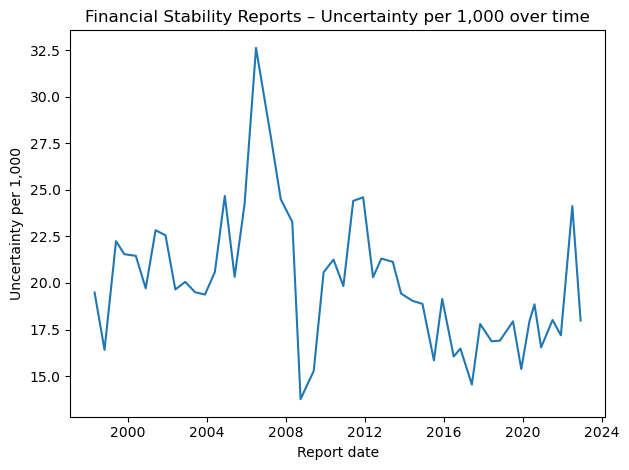

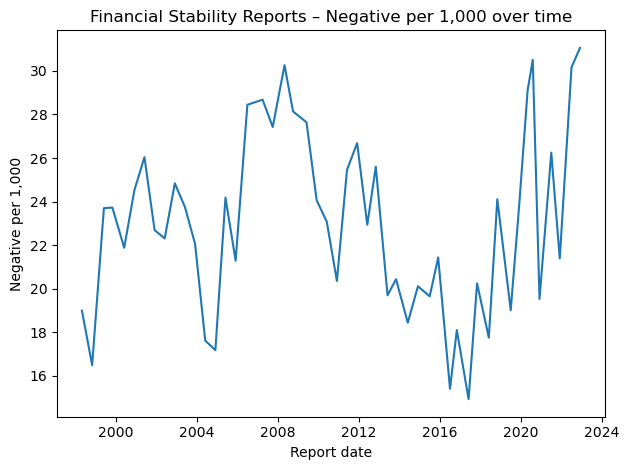

Charts saved to: outputs


In [10]:
import matplotlib.pyplot as plt
from pathlib import Path

# ensure output directory exists
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

x = df_summary.dropna(subset=["report_date"]).sort_values("report_date")

# Uncertainty per 1,000
plt.figure()
plt.plot(x["report_date"], x["uncertainty_per_1000"])
plt.title("Financial Stability Reports – Uncertainty per 1,000 over time")
plt.xlabel("Report date")
plt.ylabel("Uncertainty per 1,000")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_uncertainty_per_1000.png", dpi=300)
plt.show()

# Negative per 1,000
plt.figure()
plt.plot(x["report_date"], x["negative_per_1000"])
plt.title("Financial Stability Reports – Negative per 1,000 over time")
plt.xlabel("Report date")
plt.ylabel("Negative per 1,000")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_negative_per_1000.png", dpi=300)
plt.show()

print("Charts saved to:", OUT_DIR)

### Step 5: Overall sentiment over time

We summarise tone using two indices:

1) Net Sentiment = (Positive - Negative) / (Positive + Negative)  
   • < 0 → negative language outweighs positive

2) Net Strength = (Strong - Weak) / (Strong + Weak)  
   • > 0 → more forceful than tentative language

We’ll look at:
- Yearly medians (to smooth noise)
- A simple 3-report rolling view on the raw sequence

In [11]:
# Yearly medians for both indices
trend = (
    df_summary.dropna(subset=["year"])
    .groupby("year", as_index=False)[["net_sent_index","net_strength_index"]]
    .median()
    .sort_values("year"))

display(trend.tail(12))  # recent years at a glance

,year,net_sent_index,net_strength_index
13,2011,-0.406115,-0.730965
14,2012,-0.327367,-0.596341
15,2013,-0.252400,-0.503893
16,2014,-0.226562,-0.353729
17,2015,-0.331478,-0.319872
18,2016,-0.310777,-0.450288
19,2017,-0.272218,-0.249990
20,2018,-0.364471,-0.281151
21,2019,-0.329998,-0.196187
22,2020,-0.561564,-0.539726


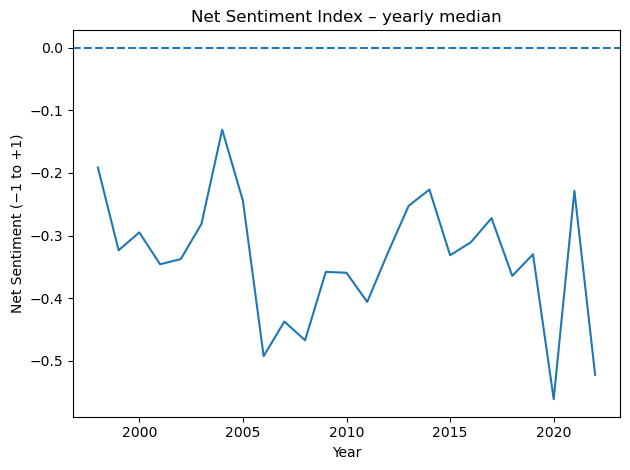

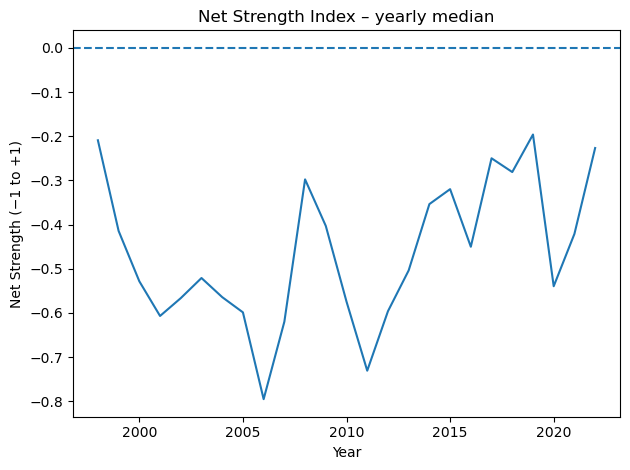

Charts saved to: outputs


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Net Sentiment (yearly median)
plt.figure()
plt.plot(trend["year"], trend["net_sent_index"])
plt.axhline(0, linestyle="--")
plt.title("Net Sentiment Index – yearly median")
plt.xlabel("Year")
plt.ylabel("Net Sentiment (−1 to +1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_net_sentiment_yearly_median.png", dpi=300)
plt.show()

# Net Strength (yearly median)
plt.figure()
plt.plot(trend["year"], trend["net_strength_index"])
plt.axhline(0, linestyle="--")
plt.title("Net Strength Index – yearly median")
plt.xlabel("Year")
plt.ylabel("Net Strength (−1 to +1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_net_strength_yearly_median.png", dpi=300)
plt.show()

print("Charts saved to:", OUT_DIR)

>Both indices remain below zero across the full period, which is expected for *Financial Stability Reports*.

>**Why Net Sentiment is negative:**  
>- The reports are written in a **risk-focused** tone: they highlight vulnerabilities, exposures, and potential shocks rather than positive developments.  
>- The **Loughran-McDonald** dictionary itself is finance-specific and risk-tilted - it includes far more negative than positive terms (≈2,300 vs ≈350).  
>- Empirically, negative terms such as *risk*, *loss*, *default*, and *crisis* occur several times more often than positive terms like *growth* or *recovery*.
>
>**Why Net Strength is negative:**  
>- Central bank language is **deliberately cautious** and measured.  
>- Reports use conditional or probabilistic expressions (“may”, “could”, “might”) far more than assertive ones (“must”, “will”).  
>- This communication style leads to more “weak” than “strong” words in the LM categories.
>
>**Trends over time:**  
>- **2007-09:** pronounced troughs reflect the Global Financial Crisis.  
>- **2020-22:** further dips correspond to the COVID-19 shock, Russia's invasion of Ukraine and the LDI-related gilt market stress.  
>- Periods of relative recovery (e.g., 2013-2018) show modest improvements in both indices but still remain below zero, consistent with a prudential and monitoring role rather than an optimistic narrative.
>
>**Key takeaway:**  
>The persistent negative sentiment does not imply bias; it captures the Bank’s institutional focus on identifying and communicating financial risks. These results therefore provide a meaningful quantitative reflection of the stability environment and the Bank’s communication stance over time.

### Step 6: Add VADER sentiment on the same texts

Goal
- Score each Financial Stability Report with **VADER** (pos/neu/neg/compound).
- Merge VADER results with our LM table.
- Produce the same style charts (time series + yearly medians) and a clear LM vs VADER comparison.
- Save everything to `outputs/` (CSV + PNGs).

In [16]:
# Install VADER if needed, then initialise the analyzer
import sys, subprocess, nltk
try:
    from nltk.sentiment import SentimentIntensityAnalyzer
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    from nltk.sentiment import SentimentIntensityAnalyzer

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

vader = SentimentIntensityAnalyzer()
print("VADER is ready.")

VADER is ready.


### Helper functions

- `chunk_words(text, n)`: split long text into ~n-word chunks.
- `score_vader(text)`: length-weighted average of VADER scores across chunks.
(We reuse `extract_text_from_pdf` and `normalise_text` from earlier.)

In [17]:
def chunk_words(text: str, words_per_chunk: int = 400):
    ws = text.split()
    if not ws:
        return []
    return [" ".join(ws[i:i+words_per_chunk]) for i in range(0, len(ws), words_per_chunk)]

def score_vader(text: str):
    chunks = chunk_words(text, 400)
    if not chunks:
        return {"vader_pos": 0.0, "vader_neu": 0.0, "vader_neg": 0.0, "vader_compound": 0.0}
    totals = {"pos":0.0, "neu":0.0, "neg":0.0, "compound":0.0}
    weight = 0
    for c in chunks:
        w = max(1, len(c.split()))
        s = vader.polarity_scores(c)
        totals["pos"] += s["pos"] * w
        totals["neu"] += s["neu"] * w
        totals["neg"] += s["neg"] * w
        totals["compound"] += s["compound"] * w
        weight += w
    return {
        "vader_pos": totals["pos"]/weight,
        "vader_neu": totals["neu"]/weight,
        "vader_neg": totals["neg"]/weight,
        "vader_compound": totals["compound"]/weight,}

### Score all FSR PDFs with VADER and merge with our LM summary

- Reads each PDF, reuses our normalisation, computes VADER scores.
- Merges into `df_summary` and saves: `outputs/fs_documents_summary_with_vader.csv`.

In [18]:
from pathlib import Path
import pandas as pd

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PDF_FOLDER = Path("pdfs/financial_stability")
pdf_files = sorted(PDF_FOLDER.glob("*.pdf"))

# Load the LM summary if not in memory
if "df_summary" not in globals():
    df_summary = pd.read_csv(OUT_DIR / "fs_documents_summary.csv")

v_rows = []
for p in pdf_files:
    print("VADER scoring:", p.name)
    raw = extract_text_from_pdf(p)
    norm = normalise_text(raw)
    v_rows.append({"document": p.stem, **score_vader(norm)})

df_vader = pd.DataFrame(v_rows)
df_models = df_summary.merge(df_vader, on="document", how="left")

# Ensure date fields exist (if not already added earlier)
if "report_date" not in df_models.columns:
    name_upper = df_models["document"].str.upper()
    month_map = {
        "JANUARY":1,"FEBRUARY":2,"MARCH":3,"APRIL":4,"MAY":5,"JUNE":6,
        "JULY":7,"AUGUST":8,"SEPTEMBER":9,"OCTOBER":10,"NOVEMBER":11,"DECEMBER":12}
    df_models["year"] = pd.to_numeric(name_upper.str.extract(r"(\d{4})", expand=False), errors="coerce")
    df_models["month_name"] = name_upper.str.extract(
        r"(JANUARY|FEBRUARY|MARCH|APRIL|MAY|JUNE|JULY|AUGUST|SEPTEMBER|OCTOBER|NOVEMBER|DECEMBER)",
        expand=False)
    df_models["month"] = df_models["month_name"].map(month_map)
    df_models["report_date"] = pd.to_datetime(
        dict(year=df_models["year"], month=df_models["month"].fillna(12), day=1),
        errors="coerce")

df_models = df_models.sort_values("report_date").reset_index(drop=True)
df_models.to_csv(OUT_DIR / "fs_documents_summary_with_vader.csv", index=False)
print("Saved:", OUT_DIR / "fs_documents_summary_with_vader.csv")
df_models.head(3)

VADER scoring: FSR-APRIL-2007.pdf
VADER scoring: FSR-AUGUST-2020.pdf
VADER scoring: FSR-DECEMBER-2000.pdf
VADER scoring: FSR-DECEMBER-2001.pdf
VADER scoring: FSR-DECEMBER-2002.pdf
VADER scoring: FSR-DECEMBER-2003.pdf
VADER scoring: FSR-DECEMBER-2004.pdf
VADER scoring: FSR-DECEMBER-2005.pdf
VADER scoring: FSR-DECEMBER-2009.pdf
VADER scoring: FSR-DECEMBER-2010.pdf
VADER scoring: FSR-DECEMBER-2011.pdf
VADER scoring: FSR-DECEMBER-2014.pdf
VADER scoring: FSR-DECEMBER-2015.pdf
VADER scoring: FSR-DECEMBER-2019.pdf
VADER scoring: FSR-DECEMBER-2020.pdf
VADER scoring: FSR-DECEMBER-2021.pdf
VADER scoring: FSR-DECEMBER-2022.pdf
VADER scoring: FSR-JULY-2006.pdf
VADER scoring: FSR-JULY-2015.pdf
VADER scoring: FSR-JULY-2016.pdf
VADER scoring: FSR-JULY-2019.pdf
VADER scoring: FSR-JULY-2021.pdf
VADER scoring: FSR-JULY-2022.pdf
VADER scoring: FSR-JUNE-1999.pdf
VADER scoring: FSR-JUNE-2000.pdf
VADER scoring: FSR-JUNE-2001.pdf
VADER scoring: FSR-JUNE-2002.pdf
VADER scoring: FSR-JUNE-2003.pdf
VADER scoring

,section,document,tokens_total,positive_per_1000,negative_per_1000,uncertainty_per_1000,litigious_per_1000,constraining_per_1000,strong_per_1000,weak_per_1000,net_sent_index,net_strength_index,matched_per_1000,year,month_name,month,report_date,vader_pos,vader_neu,vader_neg,vader_compound
0,financial_stability,FSR-MAY-1998,52023,12.398362,18.991600,19.491379,7.804240,4.671011,4.132787,7.169906,-0.210043,-0.268707,74.659285,1998,MAY,5,1998-05-01,0.092574,0.844813,0.062636,0.513869
1,financial_stability,FSR-NOVEMBER-1998,49311,11.640405,16.487194,16.406076,6.854454,4.643994,4.319523,5.840482,-0.172314,-0.149701,66.192128,1998,NOVEMBER,11,1998-11-01,0.099064,0.848949,0.051989,0.596387
2,financial_stability,FSR-JUNE-1999,90211,13.080445,23.699992,22.247841,7.238585,4.101495,3.270111,7.260755,-0.288728,-0.378947,80.899225,1999,JUNE,6,1999-06-01,0.094824,0.845001,0.060130,0.552576


### VADER charts

1) VADER compound over time (line).
2) VADER compound - yearly median (line).
Files saved into `outputs/`.

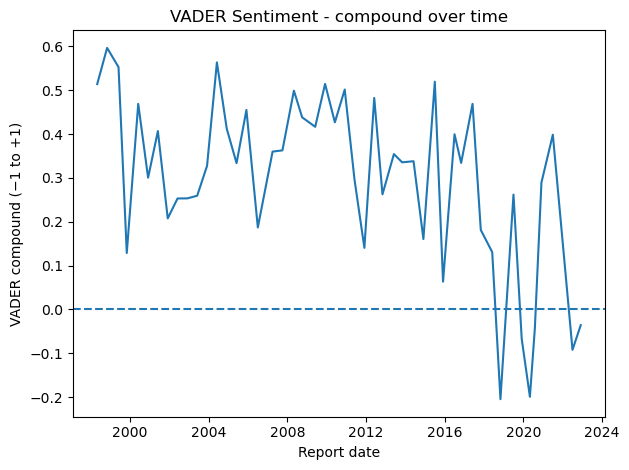

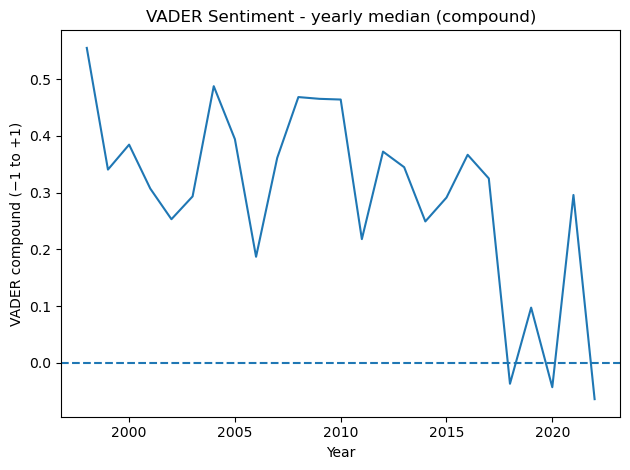

Charts saved to: outputs


In [20]:
z = df_models.dropna(subset=["report_date","vader_compound"]).sort_values("report_date")

# Time series
plt.figure()
plt.plot(z["report_date"], z["vader_compound"])
plt.axhline(0, linestyle="--")
plt.title("VADER Sentiment - compound over time")
plt.xlabel("Report date")
plt.ylabel("VADER compound (−1 to +1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_vader_compound_over_time.png", dpi=300)
plt.show()

# Yearly medians
trend_vader = (
    df_models.dropna(subset=["year","vader_compound"])
    .groupby("year", as_index=False)["vader_compound"]
    .median()
    .sort_values("year"))

plt.figure()
plt.plot(trend_vader["year"], trend_vader["vader_compound"])
plt.axhline(0, linestyle="--")
plt.title("VADER Sentiment - yearly median (compound)")
plt.xlabel("Year")
plt.ylabel("VADER compound (−1 to +1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_vader_compound_yearly_median.png", dpi=300)
plt.show()

print("Charts saved to:", OUT_DIR)

> Across the full period, VADER sentiment remains **consistently positive**, with scores fluctuating between moderate optimism and neutrality.  
> Unlike the LM dictionary, which reflects a risk-based perspective, VADER captures a more *surface-level sentiment*, interpreting the formal and measured language of the Bank as generally reassuring rather than cautious.
> 
> **Overall tone:**  
> The results portray the Financial Stability Reports as **confident, steady, and stable in tone**.  
> This is not surprising: the language used in these reports frequently emphasises resilience, robustness, and system preparedness, which VADER interprets as positive expressions.  
> Periods of stress (such as 2008–09, 2020, and 2022) still register dips, but sentiment remains largely above neutral, suggesting that even in crisis years the reports maintain a composed and reassuring communication style.
> 
> **Trends over time:**  
> - **Pre-2008:** High positive readings reflect the confidence and stability that characterised the pre-crisis environment.  
> - **2008-09:** A visible decline coincides with the Global Financial Crisis, although the tone remains more measured than alarmist.  
> - **2010-2018:** Sentiment stabilises again, mirroring the gradual economic recovery and the strengthening of financial system safeguards.  
> - **2020-22:** Temporary drops align with global shocks (COVID-19, the Ukraine war, and the LDI crisis) yet sentiment quickly returns to positive territory, reflecting the Bank’s emphasis on stability and control.
> 
> The overall pattern suggests that the Bank’s communication, when viewed through a general sentiment lens, is **reassuring rather than pessimistic**.  
> Even during crises, the tone remains anchored in stability and confidence, underlining the Bank’s role as a steadying voice in turbulent times.  
> In contrast to the LM results, which expose the underlying risk language and caution inherent in the reports, VADER highlights the **outward tone** - measured, confident, and calm - that the Bank consistently projects to maintain trust and assurance.

### Compare LM vs VADER (saved)

We’ll create:
- Yearly median comparison on one chart.
Files saved into `outputs/`.

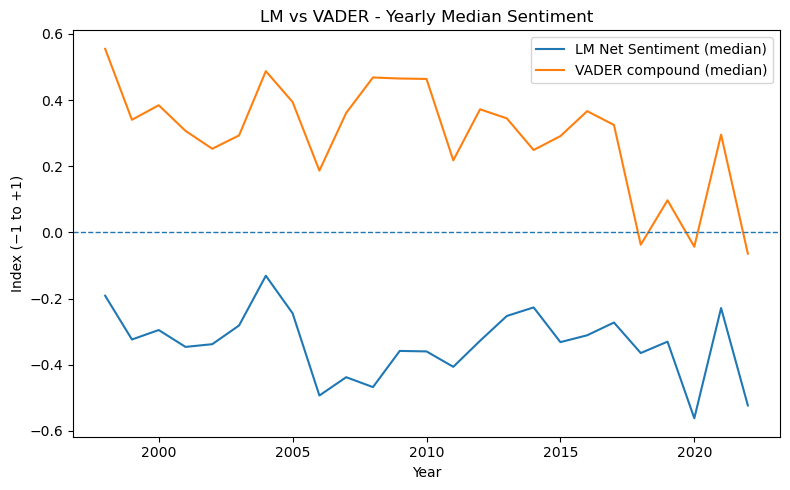

Chart saved to: outputs/fsr_lm_vs_vader_yearly_medians.png


In [25]:
# from pathlib import Path

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Compute yearly medians for LM and VADER
trend_lm = (
    df_models.dropna(subset=["year", "net_sent_index"])
    .groupby("year", as_index=False)["net_sent_index"]
    .median()
    .rename(columns={"net_sent_index": "lm_net_sent_median"}))

trend_vader = (
    df_models.dropna(subset=["year", "vader_compound"])
    .groupby("year", as_index=False)["vader_compound"]
    .median()
    .rename(columns={"vader_compound": "vader_compound_median"}))

# --- Merge and plot
trend_cmp = trend_lm.merge(trend_vader, on="year", how="outer").sort_values("year")

plt.figure(figsize=(8,5))
plt.plot(trend_cmp["year"], trend_cmp["lm_net_sent_median"], label="LM Net Sentiment (median)")
plt.plot(trend_cmp["year"], trend_cmp["vader_compound_median"], label="VADER compound (median)")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("LM vs VADER - Yearly Median Sentiment")
plt.xlabel("Year")
plt.ylabel("Index (−1 to +1)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_lm_vs_vader_yearly_medians.png", dpi=300)
plt.show()

print("Chart saved to:", OUT_DIR / "fsr_lm_vs_vader_yearly_medians.png")

> ### Yearly Median Sentiment (LM vs VADER)
> 
> This comparison captures two very different dimensions of the Bank of England’s Financial Stability Reports; the **substance** of what is said (LM) and the **tone** in which it is communicated (VADER).
> 
> **1. Overall patterns**  
The **LM sentiment** remains consistently below zero across the entire period, confirming that the underlying language of the reports is inherently **risk-focused**.  
> These are documents designed to identify vulnerabilities, exposures, and potential threats to stability; not to convey optimism.  
> In contrast, the **VADER sentiment** stays mostly **positive**, reflecting the Bank’s formal, measured, and reassuring communication style. Even when the content deals with systemic risk, the tone remains steady and composed.
> 
> **2. Alignment over time**  
Despite their different baselines, the two measures move largely **in the same direction** through key episodes:
> - **2007-09 (Global Financial Crisis):** Both lines dive sharply (LM turning deeply negative, VADER dropping towards neutral), capturing the severity of the shock and the Bank’s cautious but controlled tone.  
> - **2011-12 (Euro-area and UK slowdown):** A smaller joint dip mirrors renewed global uncertainty and market fragility.  
> - **2013-2018 (Recovery and reform):** Both indices rise (LM becomes less negative, VADER remains stably positive)- showing a calmer, more confident tone as regulation and resilience strengthen.  
> - **2020-22 (COVID-19, Ukraine war, and LDI stress):** The sharpest simultaneous downturn since 2008. LM records its lowest values, reflecting high-risk language; VADER slips towards or just below zero, signalling a more openly cautious tone.
> 
> **3. What this tells us**  
> The **directional alignment** between the two lines shows that both models are detecting real shifts in sentiment; they react to the same underlying events and inflection points in the economic environment.  
> The **gap** between them, however, is the insight:  
> - LM captures the Bank’s **internal caution:** the vocabulary of risk assessment.  
> - VADER captures the Bank’s **external voice:** the communication of stability and control.  
> 
> Together, they depict an institution that consistently balances honesty about risk with the need to project confidence.  
> When sentiment turns sharply negative in LM and softens in VADER, it’s not a contradiction; it’s the Bank performing its dual role: **acknowledging fragility while reassuring the public that the system remains under control.**
> 
> **4. Key takeaway**  
> Across twenty-five years of reports, the picture is remarkably consistent:  
> - **Cautious in substance, calm in tone.**  
> - LM reflects the analytic language of risk; VADER reflects the communicative language of reassurance.  
> The interplay between the two is precisely what you would expect from a central bank charged with maintaining both **financial stability** and **public confidence.**

<div class="alert alert-block alert-info">
Notebook End

## **5. Inflation and Monetary Policy Report Sentiment Analysis using LM and VADER**

***

<div class="alert alert-block alert-info">
Notebook Start

**Purpose**  
Analyse how the tone and sentiment of the Bank’s key macroeconomic publications (the *Inflation Report* (1998–2019) and its successor, the *Monetary Policy Report* (2019–present)) have evolved over time.  
The analysis uses two complementary approaches:
- **Loughran–McDonald (LM)**: captures *risk-oriented language* typical in financial and policy contexts.  
- **VADER**: measures the *surface tone* of communication (positive, neutral, negative) in general English.  

Together, they provide a balanced view of both **substance** (risk narrative) and **tone** (communication style).

**Scope**  
- **Files:** PDFs stored in `pdfs/inflation_reports/`, including both `inflation_report_<month>-<year>.pdf` and `monetary-policy-report_<month>-<year>.pdf`.  
- **Coverage:** 1998–2022+, around 87 reports in total.  
- **Outputs:** Metrics per report, yearly medians, and comparative charts saved to `outputs/`.

**Method**  
1. **Extract text** from each PDF using *PyMuPDF* (`fitz`).  
2. **Normalise text** (lower-case, remove punctuation, split on whitespace).  
3. **Apply LM dictionary** (finance-specific categories) to compute per-1,000 rates and indices.  
4. **Apply VADER** sentiment on the same text.  
5. **Combine outputs**, derive dates from filenames, and **aggregate yearly medians**.  
6. **Visualise** LM, VADER, and **LM vs VADER**.

**Outputs generated automatically**  
- `infl_mpr_documents_summary.csv`: one row per report with LM + VADER metrics  
- `infl_mpr_term_matches_long.csv`: every matched term (for audits)  
- PNG charts in `outputs/`:
  - `infl_mpr_uncertainty_per_1000.png`  
  - `infl_mpr_negative_per_1000.png`  
  - `infl_mpr_net_sent_yearly_median.png`  
  - `infl_mpr_net_strength_yearly_median.png`  
  - `infl_mpr_vader_compound_yearly_median.png`  
  - `infl_mpr_lm_vs_vader_yearly_medians.png`

**Note**  
The Inflation Report and the Monetary Policy Report are treated as a *single continuous publication* for consistency, as the latter replaced the former in late 2019.

#### Outputs from this section:
- 

### Step 1: Imports and Folder Setup

We begin by importing all the necessary Python libraries and defining the folder structure for this notebook.  
The setup follows exactly the same format used for the Financial Stability Reports analysis, but points to the `pdfs/inflation_reports` folder which contains both the *Inflation Reports* and the *Monetary Policy Reports*.

All outputs (tables, charts, and CSVs) will be saved into the shared `outputs` directory within the project folder.

In [1]:
# Imports done at the start of master notebook

### Step 3: Text Extraction and Normalisation

In this step, we extract text from each Inflation or Monetary Policy Report and clean it for analysis.  
We use **PyMuPDF** (`fitz`) for extraction, as in the previous notebook, ensuring consistent and reliable text output from each PDF.

The extracted text is then normalised (converted to lowercase, punctuation removed, hyphens replaced with spaces, and multiple spaces collapsed), so that the words can be matched accurately to the Loughran–McDonald sentiment dictionary later in the process.

In [2]:
# Paths
ROOT = Path(".")
PDF_FOLDER = ROOT / "pdfs" / "inflation_reports"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUM_CSV  = OUT_DIR / "infl_mpr_documents_summary.csv"
LONG_CSV = OUT_DIR / "infl_mpr_term_matches_long.csv"

# Text extractor (PyMuPDF)
import sys, subprocess
try:
    import fitz  # PyMuPDF
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pymupdf"])
    import fitz

PUNCT_RE = re.compile(r"[^\w\s']+", flags=re.UNICODE)

def extract_text_from_pdf(pdf_path: Path) -> str:
    parts = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            parts.append(page.get_text("text"))
    return "\n".join(parts)

def normalise_text(s: str) -> str:
    s = s.lower().replace("-", " ")
    s = PUNCT_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenise(s: str):
    return s.split()

### Step 3: Load the Loughran–McDonald Dictionary

We now load the **Loughran–McDonald (LM)** finance-specific sentiment dictionary, exactly as in the Financial Stability analysis.  
This dictionary categorises thousands of financial terms into sentiment and tone-related groups, including *positive, negative, uncertainty, litigious, constraining, strong,* and *weak.*

Loading the dictionary at this stage allows us to create reusable sets of words for each category.  
These sets will be used to classify every word in the Inflation and Monetary Policy Reports according to its sentiment or tone.

In [3]:
DICT_XLSX  = ROOT / "LSE_DA_BoE_Employer_project_Sentiment-labelled_wordlist-2-1.xlsx"
DICT_SHEET = "Loughran-McDonald_MasterDiction"

lex = pd.read_excel(DICT_XLSX, sheet_name=DICT_SHEET)
lex.columns = [c.strip() for c in lex.columns]

required = {"Word","Negative","Positive","Uncertainty","Litigious","Strong","Weak","Constraining"}
missing = required - set(lex.columns)
if missing:
    raise ValueError(f"Dictionary missing columns: {missing}")

label_cols = [c for c in lex.columns if c != "Word"]
lex[label_cols] = lex[label_cols].fillna(0)
lex["Word"] = lex["Word"].astype(str).str.strip().str.lower()
lex = lex[(lex[label_cols] != 0).any(axis=1)].copy()

LM = {
    "positive":     set(lex.loc[lex["Positive"]     != 0, "Word"]),
    "negative":     set(lex.loc[lex["Negative"]     != 0, "Word"]),
    "uncertainty":  set(lex.loc[lex["Uncertainty"]  != 0, "Word"]),
    "litigious":    set(lex.loc[lex["Litigious"]    != 0, "Word"]),
    "strong":       set(lex.loc[lex["Strong"]       != 0, "Word"]),
    "weak":         set(lex.loc[lex["Weak"]         != 0, "Word"]),
    "constraining": set(lex.loc[lex["Constraining"] != 0, "Word"]),}

{k: len(v) for k,v in LM.items()}

{'positive': 358,
 'negative': 2355,
 'uncertainty': 297,
 'litigious': 905,
 'strong': 19,
 'weak': 27,
 'constraining': 184}

### Step 4: Parse Filenames and Extract Dates

Before running the sentiment analysis, we identify each report’s **series, month, and year** directly from its filename.  
This ensures that every report can be placed correctly on a timeline when we produce charts and yearly medians later.

The filenames follow two consistent patterns:
- `inflation_report_<month>-<year>.pdf`
- `monetary-policy-report_<month>-<year>.pdf`

We extract this information and convert it into a proper `report_date` field (year and month), so that both the Inflation and Monetary Policy Reports are treated as one continuous publication series.

In [4]:
MONTH_MAP = {
    "JANUARY":1,"FEBRUARY":2,"MARCH":3,"APRIL":4,"MAY":5,"JUNE":6,
    "JULY":7,"AUGUST":8,"SEPTEMBER":9,"OCTOBER":10,"NOVEMBER":11,"DECEMBER":12}

PATTERN = re.compile(
    r"^(?P<series>(?:inflation[_-]report|monetary[-]policy[-]report))[_-]"
    r"(?P<month>[a-z]+)-(?P<year>\d{4})$")

def parse_name(stem: str):
    m = PATTERN.match(stem.lower())
    if not m:
        return {"series": None, "month_name": None, "year": None, "month": None}
    series_token = m.group("series")
    series = "Inflation Report" if "inflation" in series_token else "Monetary Policy Report"
    month_name = m.group("month").upper()
    year = int(m.group("year"))
    month = MONTH_MAP.get(month_name)
    return {"series": series, "month_name": month_name, "year": year, "month": month}

### Step 5: Sentiment Analysis using the Loughran–McDonald (LM) Dictionary

We now process every Inflation and Monetary Policy Report, applying the LM dictionary to classify words into their sentiment categories.  
For each report, we calculate:
- **Category rates per 1,000 words** (to normalise for length)  
- **Net Sentiment** = (Positive − Negative) / (Positive + Negative)  
- **Net Strength** = (Strong − Weak) / (Strong + Weak)

The results are saved into two files:
- `infl_mpr_documents_summary.csv`: one row per report with all key metrics  
- `infl_mpr_term_matches_long.csv`: every matched term per report (for audit)

This step mirrors the process used for the Financial Stability Reports to maintain consistency across both analyses.

In [5]:
summary_rows, long_rows = [], []

pdfs = sorted(PDF_FOLDER.glob("*.pdf"))
print(f"Found {len(pdfs)} files")

for i, p in enumerate(pdfs, 1):
    stem = p.stem
    meta = parse_name(stem)
    print(f"[{i}/{len(pdfs)}] {p.name}  ->  {meta}")

    try:
        raw  = extract_text_from_pdf(p)
        norm = normalise_text(raw)
        toks = tokenise(norm)
        tc   = Counter(toks)

        per_cat = {}
        for cat, terms in LM.items():
            hits = set(tc).intersection(terms)
            cnt  = sum(tc[w] for w in hits)
            per_cat[cat] = cnt
            for w in hits:
                long_rows.append({
                    "series":   meta["series"],
                    "document": stem,
                    "category": cat,
                    "term":     w,
                    "count":    tc[w],})

        total = len(toks)
        if total == 0:
            summary_rows.append({
                "series":   meta["series"], "document": stem,
                "month_name": meta["month_name"], "year": meta["year"], "month": meta["month"],
                "tokens_total": 0, "error": "empty_extraction"})
            continue

        perK = 1000.0 / total
        pos, neg     = per_cat.get("positive",0),     per_cat.get("negative",0)
        strong, weak = per_cat.get("strong",0),       per_cat.get("weak",0)
        net_sent     = (pos - neg)   / (pos + neg)   if (pos + neg)   > 0 else None
        net_strength = (strong-weak) / (strong+weak) if (strong+weak) > 0 else None

        summary_rows.append({
            "series":   meta["series"],
            "document": stem,
            "month_name": meta["month_name"],
            "year": meta["year"],
            "month": meta["month"],
            "tokens_total": total,
            "positive_per_1000":     per_cat.get("positive",0)     * perK,
            "negative_per_1000":     per_cat.get("negative",0)     * perK,
            "uncertainty_per_1000":  per_cat.get("uncertainty",0)  * perK,
            "litigious_per_1000":    per_cat.get("litigious",0)    * perK,
            "constraining_per_1000": per_cat.get("constraining",0) * perK,
            "strong_per_1000":       per_cat.get("strong",0)       * perK,
            "weak_per_1000":         per_cat.get("weak",0)         * perK,
            "matched_per_1000":      sum(per_cat.values())         * perK,
            "net_sent_index":        net_sent,
            "net_strength_index":    net_strength,})
    except Exception as e:
        summary_rows.append({
            "series":   meta["series"], "document": stem,
            "month_name": meta["month_name"], "year": meta["year"], "month": meta["month"],
            "tokens_total": 0, "error": str(e)        })

df = pd.DataFrame(summary_rows)
df["report_date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"].fillna(12), day=1),
    errors="coerce")
df = df.sort_values(["report_date","series","document"]).reset_index(drop=True)

df.to_csv(SUM_CSV, index=False)
pd.DataFrame(long_rows).sort_values(["document","category","term"]).to_csv(LONG_CSV, index=False)

print("Saved:", SUM_CSV)
print("Saved:", LONG_CSV)
df.head()

Found 100 files
[1/100] inflation_report_august-1998.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 1998, 'month': 8}
[2/100] inflation_report_august-1999.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 1999, 'month': 8}
[3/100] inflation_report_august-2000.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2000, 'month': 8}
[4/100] inflation_report_august-2001.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2001, 'month': 8}
[5/100] inflation_report_august-2002.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2002, 'month': 8}
[6/100] inflation_report_august-2003.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2003, 'month': 8}
[7/100] inflation_report_august-2004.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUGUST', 'year': 2004, 'month': 8}
[8/100] inflation_report_august-2005.pdf  ->  {'series': 'Inflation Report', 'month_name': 'AUG

,series,document,month_name,year,month,tokens_total,positive_per_1000,negative_per_1000,uncertainty_per_1000,litigious_per_1000,constraining_per_1000,strong_per_1000,weak_per_1000,matched_per_1000,net_sent_index,net_strength_index,report_date
0,Inflation Report,inflation_report_february-1998,FEBRUARY,1998,2,48787,13.917642,17.463669,18.447537,1.680776,1.004366,2.582655,7.850452,62.947097,-0.112998,-0.504912,1998-02-01
1,Inflation Report,inflation_report_may-1998,MAY,1998,5,54829,14.572580,17.709606,19.041018,1.805614,0.820734,2.389247,9.173977,65.512776,-0.097175,-0.586751,1998-05-01
2,Inflation Report,inflation_report_august-1998,AUGUST,1998,8,60846,15.909016,16.566414,20.034185,1.347665,0.953226,2.826809,10.797752,68.435066,-0.020243,-0.585042,1998-08-01
3,Inflation Report,inflation_report_november-1998,NOVEMBER,1998,11,56338,13.809507,20.004260,17.288509,1.384501,1.065001,1.775001,7.348504,62.675281,-0.183202,-0.610895,1998-11-01
4,Inflation Report,inflation_report_february-1999,FEBRUARY,1999,2,53773,12.813122,18.931434,16.830008,1.971250,1.115802,2.213007,6.862180,60.736801,-0.192736,-0.512295,1999-02-01


### Step 6: Add VADER Sentiment Scoring

In addition to the LM dictionary, we also use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) to measure the overall tone of the Inflation and Monetary Policy Reports.  
Where LM focuses on the financial and risk-oriented vocabulary, VADER captures the *surface-level sentiment* of the language: how positive or negative the overall communication feels.

For each report, we calculate VADER’s `pos`, `neu`, `neg`, and `compound` scores.  
These results are then merged with the LM outputs to create a combined dataset containing both the risk-based and tone-based sentiment measures.

In [6]:
# --- VADER setup
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

vader = SentimentIntensityAnalyzer()

def chunk_words(text: str, words_per_chunk: int = 400):
    ws = text.split()
    if not ws:
        return []
    return [" ".join(ws[i:i+words_per_chunk]) for i in range(0, len(ws), words_per_chunk)]

def score_vader(text: str):
    chunks = chunk_words(text, 400)
    if not chunks:
        return {"vader_pos": 0.0, "vader_neu": 0.0, "vader_neg": 0.0, "vader_compound": 0.0}
    totals = {"pos": 0.0, "neu": 0.0, "neg": 0.0, "compound": 0.0}
    weight = 0
    for c in chunks:
        w = max(1, len(c.split()))
        s = vader.polarity_scores(c)
        totals["pos"]      += s["pos"] * w
        totals["neu"]      += s["neu"] * w
        totals["neg"]      += s["neg"] * w
        totals["compound"] += s["compound"] * w
        weight += w
    return {
        "vader_pos": totals["pos"] / weight,
        "vader_neu": totals["neu"] / weight,
        "vader_neg": totals["neg"] / weight,
        "vader_compound": totals["compound"] / weight,}

# --- Score all PDFs with VADER and merge with LM results in `df`
v_rows = []
for p in pdfs:
    raw  = extract_text_from_pdf(p)
    norm = normalise_text(raw)
    v_rows.append({"document": p.stem, **score_vader(norm)})

df_vader = pd.DataFrame(v_rows)
df_models = df.merge(df_vader, on="document", how="left")

# --- Save exactly as in the FS workflow
df_models.to_csv(OUT_DIR / "infl_mpr_documents_summary.csv", index=False)
df_models.to_csv(OUT_DIR / "infl_mpr_documents_summary_with_vader.csv", index=False)

print("Saved:")
print(" -", OUT_DIR / "infl_mpr_documents_summary.csv")
print(" -", OUT_DIR / "infl_mpr_documents_summary_with_vader.csv")

df_models.head()

Saved:
 - outputs/infl_mpr_documents_summary.csv
 - outputs/infl_mpr_documents_summary_with_vader.csv


,series,document,month_name,year,month,tokens_total,positive_per_1000,negative_per_1000,uncertainty_per_1000,litigious_per_1000,...,strong_per_1000,weak_per_1000,matched_per_1000,net_sent_index,net_strength_index,report_date,vader_pos,vader_neu,vader_neg,vader_compound
0,Inflation Report,inflation_report_february-1998,FEBRUARY,1998,2,48787,13.917642,17.463669,18.447537,1.680776,...,2.582655,7.850452,62.947097,-0.112998,-0.504912,1998-02-01,0.095104,0.849859,0.055020,0.601103
1,Inflation Report,inflation_report_may-1998,MAY,1998,5,54829,14.572580,17.709606,19.041018,1.805614,...,2.389247,9.173977,65.512776,-0.097175,-0.586751,1998-05-01,0.094871,0.852441,0.052753,0.602936
2,Inflation Report,inflation_report_august-1998,AUGUST,1998,8,60846,15.909016,16.566414,20.034185,1.347665,...,2.826809,10.797752,68.435066,-0.020243,-0.585042,1998-08-01,0.099683,0.844398,0.055925,0.612014
3,Inflation Report,inflation_report_november-1998,NOVEMBER,1998,11,56338,13.809507,20.004260,17.288509,1.384501,...,1.775001,7.348504,62.675281,-0.183202,-0.610895,1998-11-01,0.091617,0.843855,0.064613,0.464506
4,Inflation Report,inflation_report_february-1999,FEBRUARY,1999,2,53773,12.813122,18.931434,16.830008,1.971250,...,2.213007,6.862180,60.736801,-0.192736,-0.512295,1999-02-01,0.093768,0.844156,0.062001,0.491510


### Step 7: Visualise LM and VADER Sentiment over Time

We now plot the sentiment metrics over time to illustrate how the Bank’s communication has evolved across different economic cycles.  
The charts include:
1. LM metrics: *Uncertainty per 1,000* and *Negative per 1,000* words  
2. LM indices: *Net Sentiment* and *Net Strength* (yearly medians)  
3. VADER: *Compound* score (yearly median)

These visuals allow us to identify key turning points and sentiment shifts in the Inflation and Monetary Policy Reports.

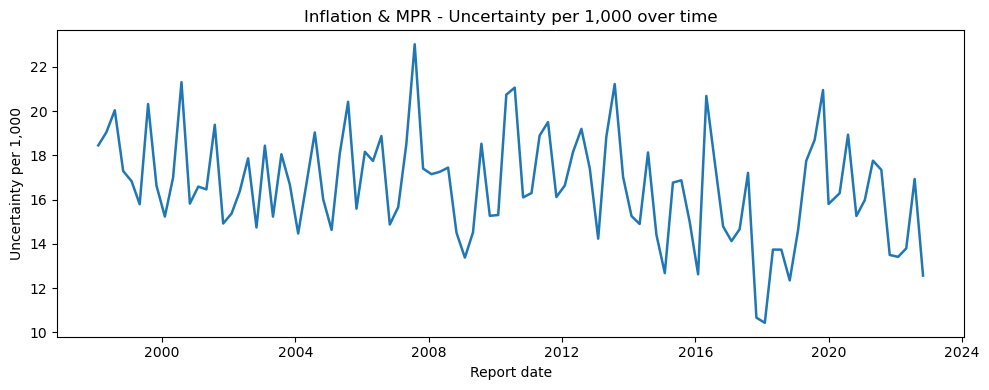

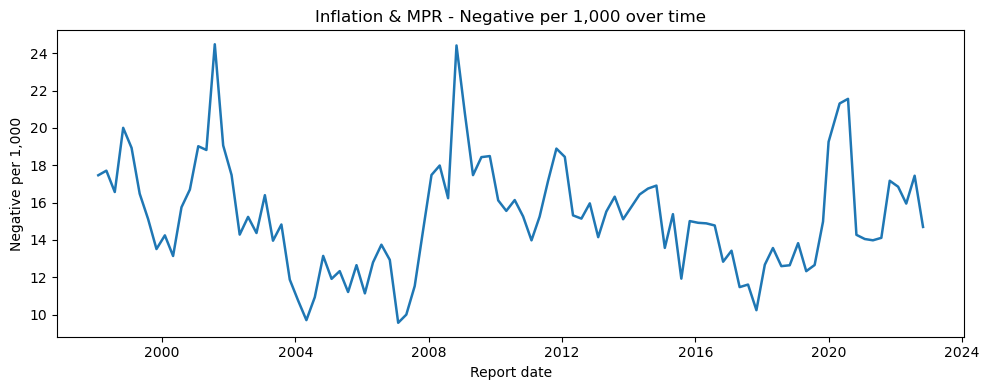

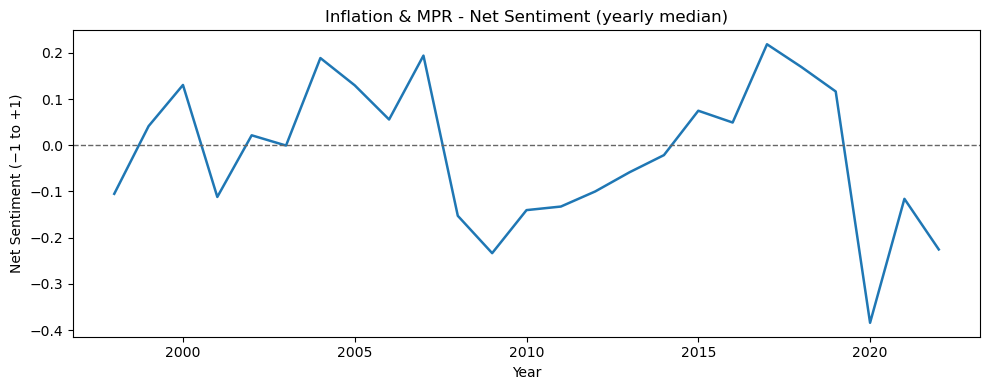

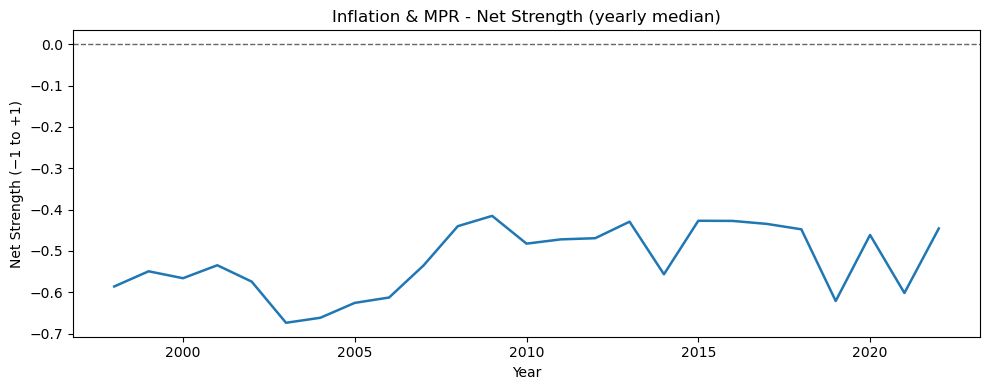

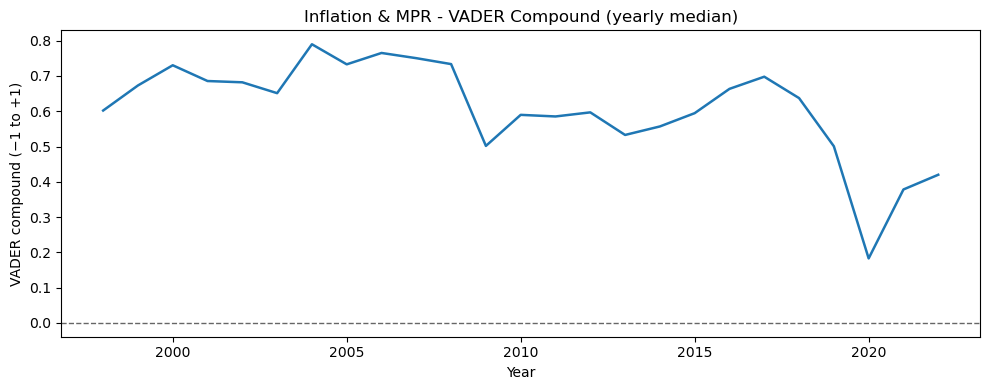

Charts saved to: outputs


In [9]:
OUT_DIR = Path("outputs")
MERGED  = OUT_DIR / "infl_mpr_documents_summary_with_vader.csv"

# Load merged table from disk (works even if nothing is in memory)
df_models = pd.read_csv(MERGED)

# Ensure proper datetime on the x-axis (critical to avoid label clutter)
df_models["report_date"] = pd.to_datetime(
    df_models["report_date"], errors="coerce"
).fillna(pd.to_datetime(dict(year=df_models["year"],
                             month=df_models["month"].fillna(12),
                             day=1), errors="coerce"))

# Sort for plotting
x = df_models.dropna(subset=["report_date"]).sort_values("report_date")

# Common date locator/formatter (same style as FSR notebook)
major = mdates.AutoDateLocator(minticks=6, maxticks=10)
fmt   = mdates.ConciseDateFormatter(major)

# LM time-series: Uncertainty per 1,000
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x["report_date"], x["uncertainty_per_1000"], lw=1.8)
ax.set_title("Inflation & MPR - Uncertainty per 1,000 over time")
ax.set_xlabel("Report date")
ax.set_ylabel("Uncertainty per 1,000")
ax.xaxis.set_major_locator(major)
ax.xaxis.set_major_formatter(fmt)
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_uncertainty_per_1000.png", dpi=300)
plt.show()

# LM time-series: Negative per 1,000
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x["report_date"], x["negative_per_1000"], lw=1.8)
ax.set_title("Inflation & MPR - Negative per 1,000 over time")
ax.set_xlabel("Report date")
ax.set_ylabel("Negative per 1,000")
ax.xaxis.set_major_locator(major)
ax.xaxis.set_major_formatter(fmt)
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_negative_per_1000.png", dpi=300)
plt.show()

# Yearly medians: LM indices
yr = (df_models.dropna(subset=["year"])
      .groupby("year", as_index=False)[["net_sent_index", "net_strength_index"]]
      .median()
      .sort_values("year"))

fig, ax = plt.subplots(figsize= (10, 4))
ax.plot(yr["year"], yr["net_sent_index"], lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Inflation & MPR - Net Sentiment (yearly median)")
ax.set_xlabel("Year")
ax.set_ylabel("Net Sentiment (−1 to +1)")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_net_sent_yearly_median.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yr["year"], yr["net_strength_index"], lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Inflation & MPR - Net Strength (yearly median)")
ax.set_xlabel("Year")
ax.set_ylabel("Net Strength (−1 to +1)")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_net_strength_yearly_median.png", dpi=300)
plt.show()

# Yearly median: VADER compound
yr_v = (df_models.dropna(subset=["year", "vader_compound"])
        .groupby("year", as_index=False)["vader_compound"]
        .median()
        .sort_values("year"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yr_v["year"], yr_v["vader_compound"], lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Inflation & MPR - VADER Compound (yearly median)")
ax.set_xlabel("Year")
ax.set_ylabel("VADER compound (−1 to +1)")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_vader_compound_yearly_median.png", dpi=300)
plt.show()

print("Charts saved to:", OUT_DIR)

### Step 8: Compare LM and VADER Sentiment (Yearly Medians)

We now place the two headline measures on the same axis:

- **LM Net Sentiment (median by year)**: the risk-oriented signal, based on the Loughran–McDonald dictionary.  
- **VADER Compound (median by year)**: the surface-tone signal from general English.

This mirrors the Financial Stability notebook and lets us see where the underlying risk language (LM) moves in step with, or diverges from, the outward tone (VADER). The chart is saved to `outputs/infl_mpr_lm_vs_vader_yearly_medians.png`.

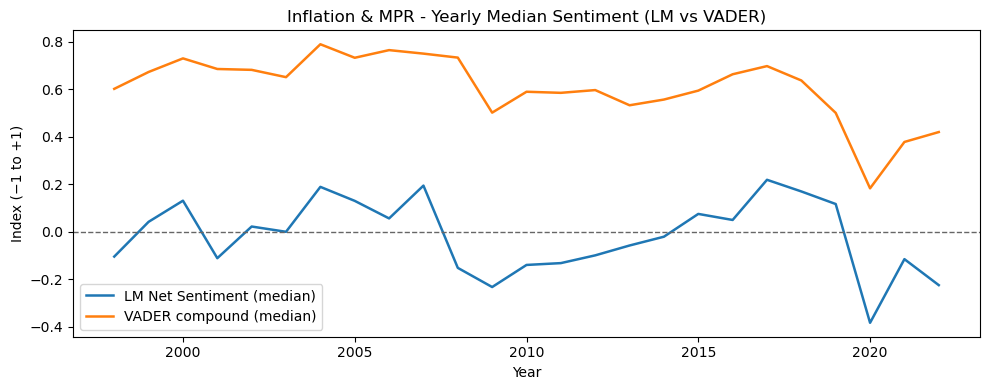

Chart saved to: outputs/infl_mpr_lm_vs_vader_yearly_medians.png


In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("outputs")
MERGED  = OUT_DIR / "infl_mpr_documents_summary_with_vader.csv"

# Load merged dataset
df_models = pd.read_csv(MERGED)

# Yearly medians
trend_lm = (df_models.dropna(subset=["year", "net_sent_index"])
            .groupby("year", as_index=False)["net_sent_index"]
            .median()
            .rename(columns={"net_sent_index": "lm_net_sent_median"}))

trend_vd = (df_models.dropna(subset=["year", "vader_compound"])
            .groupby("year", as_index=False)["vader_compound"]
            .median()
            .rename(columns={"vader_compound": "vader_compound_median"}))

trend_cmp = trend_lm.merge(trend_vd, on="year", how="outer").sort_values("year")

# Plot (same look-and-feel as FSR notebook)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trend_cmp["year"], trend_cmp["lm_net_sent_median"], label="LM Net Sentiment (median)", lw=1.8)
ax.plot(trend_cmp["year"], trend_cmp["vader_compound_median"], label="VADER compound (median)", lw=1.8)
ax.axhline(0, linestyle="--", linewidth=1, color="0.4")
ax.set_title("Inflation & MPR - Yearly Median Sentiment (LM vs VADER)")
ax.set_xlabel("Year")
ax.set_ylabel("Index (−1 to +1)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_lm_vs_vader_yearly_medians.png", dpi=300)
plt.show()

print("Chart saved to:", OUT_DIR / "infl_mpr_lm_vs_vader_yearly_medians.png")

>Both measures capture the Bank’s evolving communication tone, but in different ways.  
The **LM sentiment** (blue line) fluctuates around zero and is occasionally negative, indicating that the underlying language of the Inflation and Monetary Policy Reports remains rooted in *risk awareness* and caution.  
>The **VADER sentiment** (orange line), on the other hand, is consistently positive, showing that the surface tone of the Bank’s communication remains *reassuring and confident*, even when the economic environment is uncertain.

>**Trends over time**  
>- **Late 1990s-mid 2000s:** Both indices rise slightly. LM sentiment edges toward neutral, reflecting relatively stable growth and confidence in the policy framework during that period. VADER remains high, consistent with an outwardly optimistic communication tone.  
>- **2008-2010:** Both indicators fall. The Global Financial Crisis produces a clear dip in LM sentiment, reflecting a stronger presence of risk-related and uncertainty terms. VADER softens but remains positive, indicating that even amid crisis, the Bank’s tone aimed to project calm and credibility.  
>- **2011-2019:** Both series recover, although LM remains more cautious. The upward trend in LM sentiment suggests a gradual shift toward normalisation and renewed policy confidence as inflation stabilised and macro conditions improved.  
>- **2020-2022:** The largest joint decline since the financial crisis. LM sentiment turns sharply negative, reflecting heightened risk and uncertainty language around the pandemic, the Ukraine war, and post-Brexit dynamics. VADER also drops (its lowest reading in the series), showing that even the surface tone became noticeably less confident during this period.

>**Interpretation**  
>- The **direction of change** is aligned: both LM and VADER dip around shocks and recover during stability.  
>- The **gap between the two** reveals the Bank’s dual communication strategy — cautious in substance (LM) but generally confident in tone (VADER).  
>- The **recent narrowing of that gap** (post-2020) suggests that the Bank’s tone has become more openly cautious, reflecting the extraordinary macroeconomic and policy challenges of that period.

>**Key takeaway**  
>The Inflation and Monetary Policy Reports consistently balance technical realism with reassurance.  
>When conditions are stable, the reports lean more neutral or positive in tone.  
>When stress emerges, both measures fall, signalling that the Bank’s communication shifts toward openness about risk while still maintaining an underlying sense of stability and control.

### Step 9: Net Sentiment by Series (Inflation Report vs Monetary Policy Report)

To keep the structure aligned with the Financial Stability notebook, we also show the LM indices split by series.  
This reveals whether the transition from the **Inflation Report** to the **Monetary Policy Report** coincides with any change in risk language.

We plot two yearly-median charts by series:
- **LM Net Sentiment (median by year and series)**
- **LM Net Strength (median by year and series)**

Charts are saved to:
- `outputs/infl_mpr_net_sent_yearly_median_by_series.png`
- `outputs/infl_mpr_net_strength_yearly_median_by_series.png`

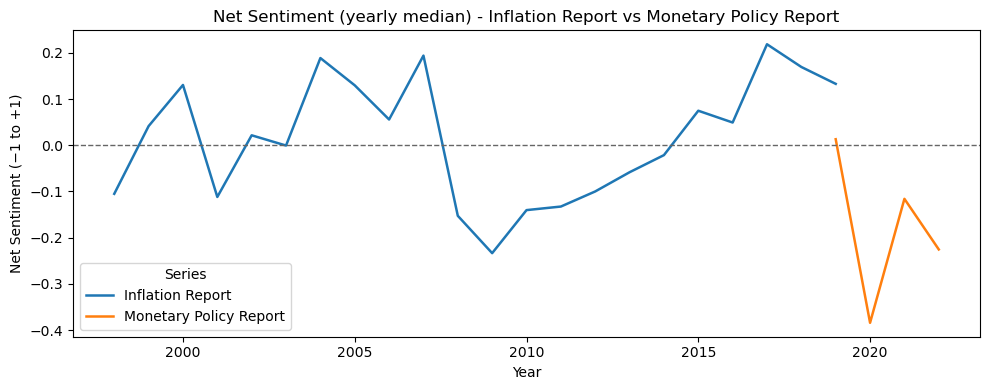

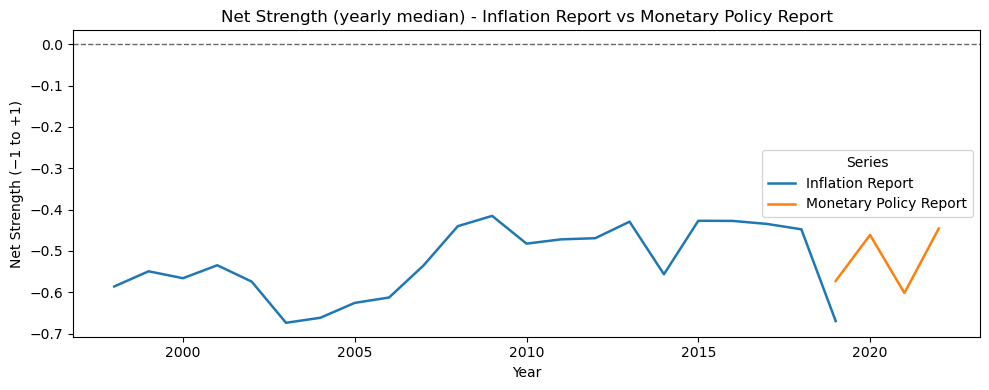

Charts saved to:
 - outputs/infl_mpr_net_sent_yearly_median_by_series.png
 - outputs/infl_mpr_net_strength_yearly_median_by_series.png


In [13]:
OUT_DIR = Path("outputs")
MERGED  = OUT_DIR / "infl_mpr_documents_summary_with_vader.csv"

# Load merged dataset
df_models = pd.read_csv(MERGED)

# Guard: ensure 'series' exists
if "series" not in df_models.columns:
    raise ValueError("Column 'series' not found. Ensure filename parsing (Step 5) created the series field.")

# Yearly medians by series
yr_series = (df_models.dropna(subset=["year", "series"])
             .groupby(["year", "series"], as_index=False)[["net_sent_index", "net_strength_index"]]
             .median()
             .sort_values(["year", "series"]))

# Pivot for plotting
pivot_ns  = yr_series.pivot(index="year", columns="series", values="net_sent_index")
pivot_str = yr_series.pivot(index="year", columns="series", values="net_strength_index")

# Net Sentiment by series
fig, ax = plt.subplots(figsize=(10, 4))
pivot_ns.plot(ax=ax, lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Net Sentiment (yearly median) - Inflation Report vs Monetary Policy Report")
ax.set_xlabel("Year")
ax.set_ylabel("Net Sentiment (−1 to +1)")
ax.legend(title="Series")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_net_sent_yearly_median_by_series.png", dpi=300)
plt.show()

# Net Strength by series
fig, ax = plt.subplots(figsize=(10, 4))
pivot_str.plot(ax=ax, lw=1.8)
ax.axhline(0, ls="--", color="0.4", lw=1)
ax.set_title("Net Strength (yearly median) - Inflation Report vs Monetary Policy Report")
ax.set_xlabel("Year")
ax.set_ylabel("Net Strength (−1 to +1)")
ax.legend(title="Series")
fig.tight_layout()
fig.savefig(OUT_DIR / "infl_mpr_net_strength_yearly_median_by_series.png", dpi=300)
plt.show()

print("Charts saved to:")
print(" -", OUT_DIR / "infl_mpr_net_sent_yearly_median_by_series.png")
print(" -", OUT_DIR / "infl_mpr_net_strength_yearly_median_by_series.png")

>**Transition and continuity**  
>The transition from the *Inflation Report* (IR) to the *Monetary Policy Report* (MPR) in 2019 marks an important shift in format, but the underlying communication style remains recognisably BoE: cautious, measured, and grounded in transparency.  
>The two lines together show that while the structure and branding changed, the overall sentiment logic did not.

>**Net Sentiment (top chart)**  
>The *Inflation Report* series (blue line) shows a cyclical pattern.  
Sentiment improves steadily through the early 2000s, dips sharply around the financial crisis, and then rises again through the recovery years, peaking around 2016–17.  
>This upturn aligns with a period of relative macroeconomic stability and predictable inflation dynamics.

>The *Monetary Policy Report* (orange line) continues the story, but in a very different context: the pandemic, global supply shocks, and renewed inflationary pressure.  
>Unsurprisingly, the first MPRs are sharply more negative.  
>That drop doesn’t signal a change in communication style; it reflects the economic reality of 2020-21, when policy discussions became dominated by uncertainty, trade-offs, and risk management.  
>By 2022, sentiment begins to recover modestly, mirroring a shift from crisis response to policy recalibration.

>**Net Strength (bottom chart)**  
>The Net Strength line reinforces the same story in tone.  
>Across both series, it stays comfortably below zero, showing that the Bank’s language remains cautious and conditional, favouring “could,” “may,” and “might” over “will” or “must.”  
>The small uptick under the MPR period suggests slightly firmer communication, likely reflecting the Bank’s need to signal decisive policy action amid rapidly rising inflation.

>**What this tells us**  
>The continuity between the two lines is striking: the tone of the MPRs didn’t depart from the style established by the IRs; it simply inherited it in a more volatile world.  
>Both reports serve the same purpose: to explain, reassure, and maintain credibility during uncertainty.  
>The data shows that while the *content* of communication became more urgent after 2019, the *style* (fact-based, careful, and deliberately unemotional) remains at the heart of the Bank’s public voice.

>**In short**  
>> The MPRs didn’t replace the Inflation Reports in tone; they extended them into a tougher era, keeping the same discipline of cautious optimism that defines the Bank’s communication DNA.

<div class="alert alert-block alert-info">
Notebook End

## **6. MPC Voting Analysis**

***

<div class="alert alert-block alert-info">
Notebook Start

**Bank of England: Analysis of Monetary Policy Committee (MPC) Voting on Bank Rate**

**Purpose:**
- Analyse voting trends of the MPC on Bank Rate
- Analyse unaninimity of each vote (especially during crisis periods)

**Scope:**
- Files: xlsx file for mpc voting on bank rate decisions
- Date range: 1998-2022 in a monthly format
- Outputs: dataframe of mpc voting record in a monthly format stored as csv file and charts illustrating trends stored as png files

**Method:**
1. Import libraries and define folder structure
2. Load mpcvoting.xlsx into pandas dataframe
3. Clean dataframe so there are 9 vote columns per month with no missing values
4. Add columns for vote to increase/maintain/decrease bank rate and majority as percentage of total
5. Visualise outputs

#### Outputs from this section:
- 

**Step 1: Import libraries and define folder structure**

In [3]:
# Imports done at the start of master notebook

In [2]:
# Build file paths
root = Path(".")
xlsx_folder = root / "data"
xlsx_file = xlsx_folder / "mpcvoting.xlsx"
out_dir = root / "data" / "mpc_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

**Step 2: Load mpcvoting.xlsx into pandas dataframe**

In [8]:
# Load the mpc_voting.xlsx file into a pandas dataframe only taking necessary sheet and rows
mpcvoting_df = pd.read_excel(
    xlsx_file,
    sheet_name="Bank Rate Decisions",
    usecols="B:L, N:BC",
    skiprows=18,
    nrows=300,
    header=None)

# New names for first 11 columns
new_names = ["Date",
             "Bank Rate",
             "Vote 1",
             "Vote 2",
             "Vote 3",
             "Vote 4",
             "Vote 5",
             "Vote 6",
             "Vote 7",
             "Vote 8",
             "Vote 9"]

# Apply the new names ONLY to the first 11 columns
mpcvoting_df.columns = new_names + list(mpcvoting_df.columns[11:])

In [9]:
# Preview the dataframe
print(mpcvoting_df.head())
print(mpcvoting_df.tail())
print(mpcvoting_df.shape)

        Date  Bank Rate  Vote 1  Vote 2  Vote 3  Vote 4  Vote 5  Vote 6  \
0 1998-01-08     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   
1 1998-02-05     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   
2 1998-03-05     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   
3 1998-04-09     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   
4 1998-05-07     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   

   Vote 7  Vote 8  ...  45  46  47  48  49  50  51  52  53  54  
0     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
1     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
2     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
3     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
4     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  

[5 rows x 53 columns]
          Date  Bank Rate  Vote 1  Vote 2  Vote 3  Vote 4  Vote 5  Vote 6  \
295 2025-03-20     0.0450  0.0450  0.0450  0.0425  0.0450  

**Results of step 2:**
- Only rows and columns containing votes loaded into pandas dataframe
- Initial dataframe shows 300 rows and 53 columns
- Names added to first 11 columns which will be populated on cleaning, other 42 columns will be deleted after cleaning

**Step 3: Clean dataframe so there are 9 vote columns per month with no missing values**

In [10]:
# Identify all vote columns from file
vote_columns = mpcvoting_df.columns[2:]

In [11]:
# Define a function to collapse all votes into 9 columns
def collapse_votes(row):
    # extract all vote values from the many MPC-member columns
    votes = [v for v in row[vote_columns].tolist() if pd.notna(v)]
    votes = votes[:9]  # keep only the first 9
    
    # pad if fewer than 9 votes (rare)
    votes += [None] * (9 - len(votes))
    
    return pd.Series(votes, index=[f"vote {i}" for i in range(1, 10)])

In [12]:
# Apply the function to each row
new_votes_df = mpcvoting_df.apply(collapse_votes, axis=1)

In [14]:
# Create the final clean data frame
final_df = pd.concat(
    [mpcvoting_df[["Date", "Bank Rate"]], new_votes_df],
    axis=1)

In [15]:
# Rename the final data frame
mpcvoting_clean = final_df

# Preview the clean data frame
print(mpcvoting_clean.head())
print(mpcvoting_clean.tail())
print(mpcvoting_clean.shape)
print(mpcvoting_clean.dtypes)

        Date  Bank Rate    vote 1    vote 2  vote 3  vote 4    vote 5  \
0 1998-01-08     0.0725  Increase  Increase  0.0725  0.0725  Increase   
1 1998-02-05     0.0725  Increase  Increase  0.0725  0.0725  Increase   
2 1998-03-05     0.0725  Increase  Increase  0.0725  0.0725  Increase   
3 1998-04-09     0.0725  Increase  Increase  0.0725  0.0725    0.0725   
4 1998-05-07     0.0725    0.0725  Increase  0.0725  0.0725    0.0725   

     vote 6    vote 7  vote 8  vote 9  
0    0.0725    0.0725  0.0725     NaN  
1    0.0725  Increase  0.0725     NaN  
2    0.0725  Increase  0.0725     NaN  
3    0.0725  Increase  0.0725     NaN  
4  Decrease    0.0725  0.0725     NaN  
          Date  Bank Rate  vote 1  vote 2  vote 3  vote 4  vote 5  vote 6  \
295 2025-03-20     0.0450   0.045   0.045  0.0425  0.0450   0.045   0.045   
296 2025-05-08     0.0425  0.0425  0.0425  0.0400  0.0425  0.0425   0.045   
297 2025-06-19     0.0425  0.0425  0.0425  0.0400  0.0425  0.0425  0.0425   
298 2025-08-0

In [16]:
# Replace missing values with bank rate at the time
vote_cols = [f"vote {i}" for i in range(1, 10)]

for col in vote_cols:
    mpcvoting_clean[col] = mpcvoting_clean[col].fillna(mpcvoting_clean["Bank Rate"])

In [17]:
# Preview the clean data frame
print(mpcvoting_clean.head())

        Date  Bank Rate    vote 1    vote 2  vote 3  vote 4    vote 5  \
0 1998-01-08     0.0725  Increase  Increase  0.0725  0.0725  Increase   
1 1998-02-05     0.0725  Increase  Increase  0.0725  0.0725  Increase   
2 1998-03-05     0.0725  Increase  Increase  0.0725  0.0725  Increase   
3 1998-04-09     0.0725  Increase  Increase  0.0725  0.0725    0.0725   
4 1998-05-07     0.0725    0.0725  Increase  0.0725  0.0725    0.0725   

     vote 6    vote 7  vote 8  vote 9  
0    0.0725    0.0725  0.0725  0.0725  
1    0.0725  Increase  0.0725  0.0725  
2    0.0725  Increase  0.0725  0.0725  
3    0.0725  Increase  0.0725  0.0725  
4  Decrease    0.0725  0.0725  0.0725  


In [18]:
# Convert "Increase" and "Decrease" to numeric values
def normalize_vote(vote, bank_rate):
    if pd.isna(vote):
        return vote  # leave NaN for now (you already handle NaNs later)

    if isinstance(vote, str):
        if vote.strip().lower() == "increase":
            return bank_rate + 0.0025
        elif vote.strip().lower() == "decrease":
            return bank_rate - 0.0025
        elif vote.strip().lower() in ["maintain", "hold"]:
            return bank_rate
        else:
            # If it is a number stored as a string, convert it
            try:
                return float(vote)
            except:
                return vote  # unexpected string, leave unchanged
        
    # If it is already numeric, return as is
    return vote

In [20]:
# Apply to all rows
for col in vote_cols:
    mpcvoting_clean[col] = mpcvoting_clean.apply(
        lambda row: normalize_vote(row[col], row["Bank Rate"]),
        axis=1)

In [21]:
# View the data frame
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725


In [23]:
# Filter out dates on or after 2023-01-01 so that only values for pre-established date range are included
cutoff_date = pd.Timestamp("2023-01-01")
mpcvoting_clean = mpcvoting_clean[mpcvoting_clean["Date"] < cutoff_date]

In [24]:
# View last 5 rows
mpcvoting_clean.tail()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9
273,2022-06-16,0.0125,0.0125,0.0150,0.0125,0.0125,0.0125,0.0125,0.0150,0.0150,0.0125
274,2022-08-04,0.0175,0.0175,0.0175,0.0175,0.0175,0.0175,0.0175,0.0175,0.0175,0.0150
275,2022-09-22,0.0225,0.0225,0.0200,0.0250,0.0225,0.0250,0.0225,0.0225,0.0250,0.0225
276,2022-11-03,0.0300,0.0300,0.0275,0.0300,0.0300,0.0300,0.0300,0.0300,0.0300,0.0250
277,2022-12-15,0.0350,0.0350,0.0300,0.0375,0.0350,0.0350,0.0350,0.0350,0.0350,0.0300


**Results of step 3:**
- Voting columns were established and function was defined to collapse all votes into 9 columns
- For months where there were fewer than 9 members of the MPC, missing votes were assumed to be bank rate at the time
- Where votes were labled as "Increase"/"Decrease"/"Maintain"/"Hold" an increase/decrease of the bank rate was assumed to be 0.25% and maintain was set as the current bank rate
- Any votes held on or after 1st January 2023 were filtered out to correspond with pre-established date range
- Data frame was saved to csv file

**Step 4: Add columns for vote to increase/maintain/decrease bank rate and majority as percentage of total**

In [7]:
# Specify vote columns
vote_cols = mpcvoting_clean.columns[2:]

# View vote_cols
vote_cols

Index(['vote 1', 'vote 2', 'vote 3', 'vote 4', 'vote 5', 'vote 6', 'vote 7',
       'vote 8', 'vote 9'],
      dtype='object')

In [8]:
# Calculate the mode of vote_cols for every row and add to new majority_vote column
mpcvoting_clean["majority_vote"] = (mpcvoting_clean[vote_cols].mode(axis=1).iloc[:, 0])

# Preview first 5 rows
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725


In [15]:
# Add new decision column based on majority_vote and Bank Rate of previous row
prev_bank_rate = mpcvoting_clean["Bank Rate"].shift(1)

conditions = [
    mpcvoting_clean["majority_vote"] > prev_bank_rate,
    mpcvoting_clean["majority_vote"] == prev_bank_rate,
    mpcvoting_clean["majority_vote"] < prev_bank_rate
]

choices = ["increase", "maintain", "decrease"]

mpcvoting_clean["decision"] = np.select(conditions, choices, default="maintain")

# View first 5 rows
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote,decision,majority_vote_pct
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725,maintain,66.666667
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,66.666667
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725,maintain,77.777778


In [16]:
# Calculate majority_vote as percentage of total votes to determine unanimity of vote
vote_count = len(vote_cols)

mpcvoting_clean["majority_vote_pct"] = (
    (mpcvoting_clean[vote_cols]
        .eq(mpcvoting_clean["majority_vote"], axis=0)
        .sum(axis=1)
      / vote_count) 
    * 100)

# View first 5 rows
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote,decision,majority_vote_pct
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725,maintain,66.666667
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,66.666667
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725,maintain,77.777778


In [22]:
# Convert the decision to a numeric value
decision_map = {"increase": 1, "maintain": 0, "decrease": -1}
mpcvoting_clean["decision_numeric"] = mpcvoting_clean["decision"].map(decision_map)

# View the first 5 rows
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote,decision,majority_vote_pct,decision_numeric
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725,maintain,66.666667,0
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556,0
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556,0
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,66.666667,0
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725,maintain,77.777778,0


In [23]:
# Save the dataframe to a csv file
# Ensure the folder exists
out_dir.mkdir(parents=True, exist_ok=True)

# Define the CSV file path
output_file = out_dir / "mpcvoting_clean.csv"

# Save the DataFrame
mpcvoting_clean.to_csv(output_file, index=False)

**Results of step 4:**
- The majority vote for each month was calculated using the mode of columns containing votes
- The decision to increase/maintain/decrease the bank rate was calculated using a comparison of the majority vote and the bank rate of the previous month and stored as a numeric value (1 to -1)
- The majority as a percentage of the total vote was calculated for each month to determine the unanimity of each vote

**Step 5: Visualise outputs**

In [3]:
# Import libraries
import matplotlib.pyplot as plt

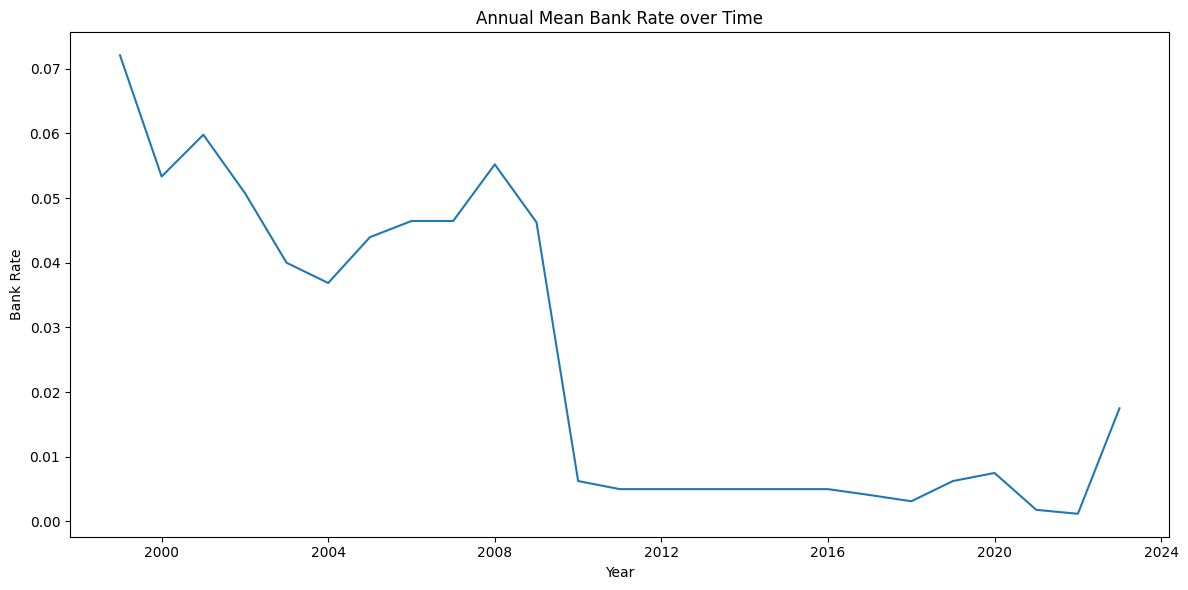

In [28]:
# Ensure Date column is datetime
mpcvoting_clean["Date"] = pd.to_datetime(mpcvoting_clean["Date"])

# Filter out dates after 31st Dec 2022
mask = (mpcvoting_clean["Date"] <= "2022-12-31")
mpcvoting_22 = mpcvoting_clean.loc[mask].sort_values("Date")

# Set Date as index
mpcvoting_22 = mpcvoting_22.set_index("Date")

# Compute annual mean
annual_mean_bankrate = mpcvoting_22.resample("YE")["Bank Rate"].mean()

# Define plot size
plt.figure(figsize=(12, 6))

# Plot points
plt.plot(annual_mean_bankrate.index, annual_mean_bankrate.values)

# Labels
plt.xlabel("Year")
plt.ylabel("Bank Rate")
plt.title("Annual Mean Bank Rate over Time")

plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(out_dir / "annual_mean_bank_rate.png", dpi=300)

# Print the plot
plt.show()

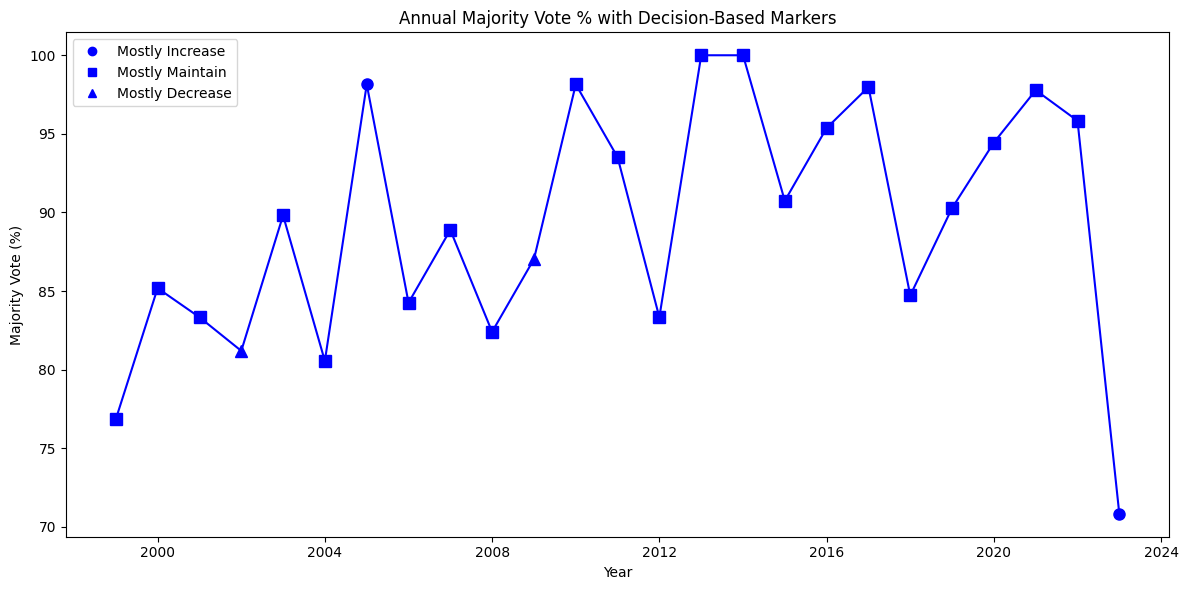

In [27]:
# Convert index to datetime if needed
mpcvoting_clean.index = pd.to_datetime(mpcvoting_clean.index, errors="coerce")

# Compute annual mean
annual_mean = mpcvoting_clean.resample("YE")[["majority_vote_pct", "decision_numeric"]].mean()

# Define marker based on decision_numeric thresholds
def decision_marker(value):
    if value > 0.33:
        return "o"   # mostly increase
    elif value < -0.33:
        return "^"   # mostly decrease
    else:
        return "s"   # mostly maintain

# Define plot size
plt.figure(figsize=(12, 6))

# Plot each point individually with its marker
for date, row in annual_mean.iterrows():
    plt.plot(
        date,
        row["majority_vote_pct"],
        marker=decision_marker(row["decision_numeric"]),
        markersize=8,
        color="blue",
        linestyle="-"
    )

# Connect points with a line
plt.plot(annual_mean.index, annual_mean["majority_vote_pct"], color="blue", linestyle="-")

# Labels and formatting
plt.xlabel("Year")
plt.ylabel("Majority Vote (%)")
plt.title("Annual Majority Vote % with Decision-Based Markers")

# Create a custom legend for the markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="blue", label="Mostly Increase", linestyle=""),
    Line2D([0], [0], marker="s", color="blue", label="Mostly Maintain", linestyle=""),
    Line2D([0], [0], marker="^", color="blue", label="Mostly Decrease", linestyle="")
]
plt.legend(handles=legend_elements)
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(out_dir / "mpcvote_unanimity.png", dpi=300)

# Print the plot
plt.show()

In [17]:
# Reload old version of mpcvoting_clean.csv with Date column rather than date as index
mpcvoting_clean = pd.read_csv(output_file)

# Check that csv file has been loaded correctly
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote,decision,majority_vote_pct,decision_numeric
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725,maintain,66.666667,0
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556,0
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556,0
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,66.666667,0
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725,maintain,77.777778,0


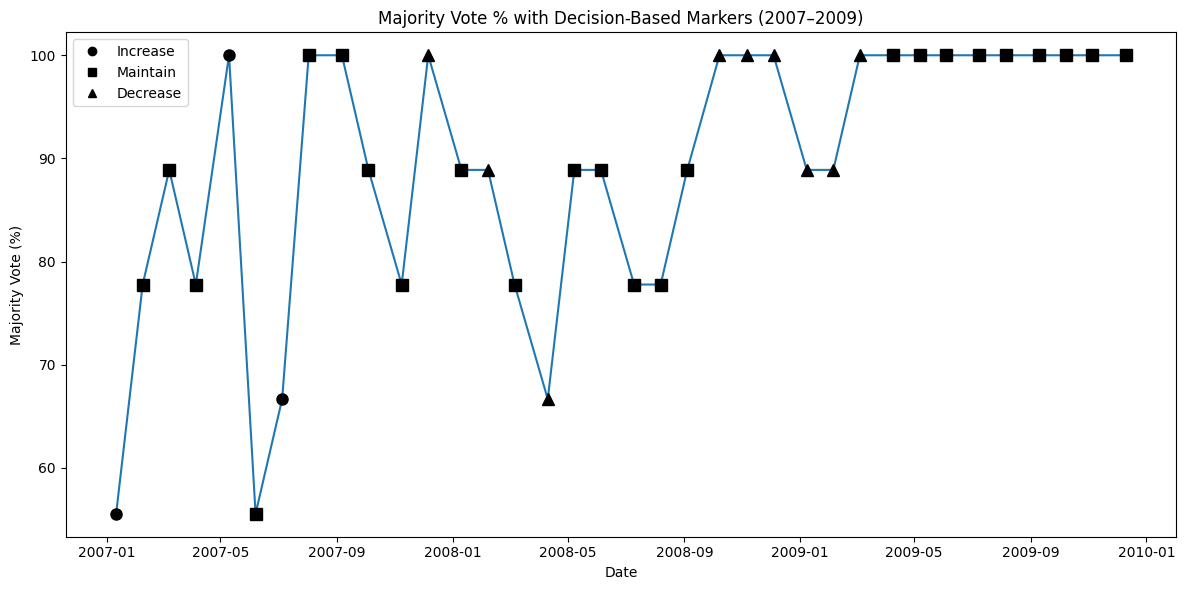

In [11]:
# Ensure Date is datetime
mpcvoting_clean["Date"] = pd.to_datetime(mpcvoting_clean["Date"], errors="coerce")

# Filter for 2007–2009
mask = (mpcvoting_clean["Date"] >= "2007-01-01") & (mpcvoting_clean["Date"] <= "2009-12-31")
df_0709 = mpcvoting_clean.loc[mask].sort_values("Date")

# Map decisions to markers
marker_map = {
    "increase": "o",   # circle
    "maintain": "s",   # square
    "decrease": "^"    # triangle
}

# Define plot size
plt.figure(figsize=(12, 6))

# Plot the line first (without markers)
plt.plot(df_0709["Date"], df_0709["majority_vote_pct"], linestyle="-")

# Scatter individual points with decision-based markers
for _, row in df_0709.iterrows():
    plt.plot(
        row["Date"],
        row["majority_vote_pct"],
        marker=marker_map.get(row["decision"], "o"), 
        markersize=8,
        linestyle="",
        color="black"
    )

# Labels and formatting
plt.xlabel("Date")
plt.ylabel("Majority Vote (%)")
plt.title("Majority Vote % with Decision-Based Markers (2007–2009)")

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='black', linestyle='', label='Increase'),
    Line2D([0], [0], marker='s', color='black', linestyle='', label='Maintain'),
    Line2D([0], [0], marker='^', color='black', linestyle='', label='Decrease')
]
plt.legend(handles=legend_elements)
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(out_dir / "mpcvote0709_unanimity.png", dpi=300)

# Print the plot
plt.show()

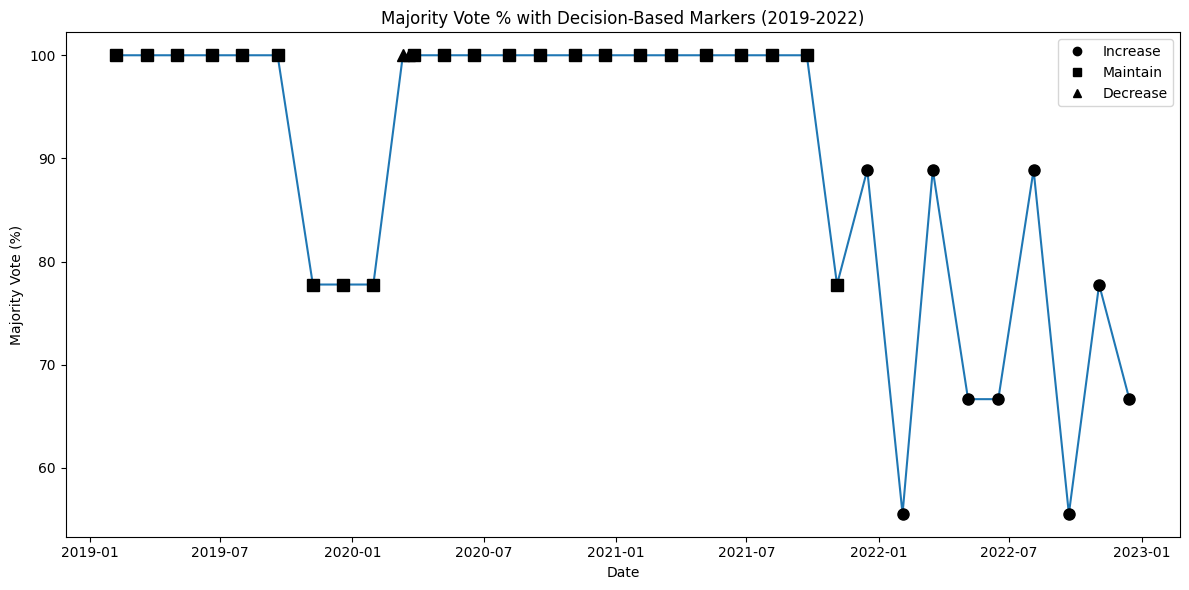

In [12]:
# Filter for 2019–2022
mask = (mpcvoting_clean["Date"] >= "2019-01-01") & (mpcvoting_clean["Date"] <= "2022-12-31")
df_1922 = mpcvoting_clean.loc[mask].sort_values("Date")

# Map decisions to markers
marker_map = {
    "increase": "o",   # circle
    "maintain": "s",   # square
    "decrease": "^"    # triangle
}

# Define plot size
plt.figure(figsize=(12, 6))

# Plot the line first (without markers)
plt.plot(df_1922["Date"], df_1922["majority_vote_pct"], linestyle="-")

# Scatter individual points with decision-based markers
for _, row in df_1922.iterrows():
    plt.plot(
        row["Date"],
        row["majority_vote_pct"],
        marker=marker_map.get(row["decision"], "o"), 
        markersize=8,
        linestyle="",
        color="black"
    )

# Labels and formatting
plt.xlabel("Date")
plt.ylabel("Majority Vote (%)")
plt.title("Majority Vote % with Decision-Based Markers (2019-2022)")

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='black', linestyle='', label='Increase'),
    Line2D([0], [0], marker='s', color='black', linestyle='', label='Maintain'),
    Line2D([0], [0], marker='^', color='black', linestyle='', label='Decrease')
]
plt.legend(handles=legend_elements)
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(out_dir / "mpcvote1922_unanimity.png", dpi=300)

# Print the plot
plt.show()

**Results of stage 5:**
- 1st graph showing annual mean bank rate over time drawn by calculating annual mean bank rate and plotting against year
- 2nd graph showing annual majority vote drawn by calculating average majority vote percentage and avergae decision for each year
- 3rd graph focusing on 2007-09, around the GFC, drawn by creating subset of data frame and plotting majority vote percentage against date with decision as marker
- 4th graph focusing on 2019-22, around COVID pandemic, drawn using same method as 3rd graph

**Conclusions drawn from analysis:**
- The bank rate was historically high, had a big decrease after the peak of the GFC and remained low until after the height of the COVID pandemic, where it has begun to rise again
- When looking at yearly averages of majority vote as a percentage of total votes, there is always at least a 70% majority and a 100% majority in 2 consecutive years
- In 21 out of the 25 years, the average decision was to maintain the bank rate. This shows that the mpc prefer to keep the bank rate steady within any given year
- When focusing on the period around the GFC, the unanimity of the vote varies greatly and the decision of the vote is less consistent. At the beginning of the crisis in 2007, the unanimity fluctuates from low points of 55% to high points of 100%, with the decision being to either maintain or increase the bank rate. During the peak of the crisis in 2008 the unanimity of the vote is more certain, ranging between 70% and 100%, with the decision being either to maintain or decrease the bank rate. After the peak of the crisis in 2009 the majority was much more stable, hitting 100% from March onwards, and the decision to maintain the bank rate was consistent from April onwards.
- When focusing on the period around the COVID pandemic, the unanimity shows little variation until the recovery period after the easing of lockdown restrictions. The bank voted unanimously to maintain the bank rate for the majority of 2019. There was a decrease at the beginning of the first lockdown in March 2020, and then the bank voted unanimously to maintain the bank rate for the rest of 2020 and until after the easing of lockdown restrictions in mid 2021. From the summer of 2021 to the end of 2022, as the UK recovered from the various lockdown restrictions, the majority of the mpc's vote was less certain ranging from 55% to 90%, but the decision to increase the bank rate again was consistent
- The mpc's reactions to the two crisis periods was different, the unanimity varies in one whereas it was very stable in another. Their decisions tend to be to maintain the bank rate during a crisis period, only increasing it as the economy begins to recover afterwards

<div class="alert alert-block alert-info">
Notebook End

## **7. Latent Dirichlet Allocation (LDA) Topic Modelling for communications during GFC and COVID**

***

<div class="alert alert-block alert-info">
Notebook Start

#### ***Exploring GFC (2007-2009) and Covid-19 (2019-2022) datasets for:***
- Inflation Report (IR) & Monetary Policy Report (MPR)
- Financial Stability Report (FSR)
- Monetary Policy Committee - Meeting Minutes

#### Outputs from this section:
- 

#### Installing and importing packages/libraries

In [ ]:
# !pip install PyPDF2 gensim nltk scikit-learn
# !pip install pdfplumber
# pip install pyLDAvis
# pip install pycryptodome

### Defining Functions

#### Extract text from PDFs function
PDF Plumber appears to be the best library to extract text. Other libraries like Fitz (MyMuPDF) and PyPDF would return words like "nance", "nancial", "signi", "ned", etc.


In [1]:
# Function to extract text using PDF Plumber
import pdfplumber

def extract_text_from_pdf(pdf_path):
    text = ""
    # Open the PDF with pdfplumber
    with pdfplumber.open(pdf_path) as pdf:
        # Iterate through pages
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:   # avoid None
                text += page_text + " "
    return text

#### Cleaning function
Stop words list had to be extended to capture "noise" words. Need to decide with the team if finance/policy filler words need to be added to the stop words list.

##### Cleaning Function Summary
This function prepares raw PDF‑extracted text for NLP tasks (e.g., topic modeling):

1. **Normalize case** → converts all text to lowercase.  
2. **Fix artifacts** → removes hyphenated line breaks, normalizes whitespace, and merges “non‑” prefixes.  
3. **Remove non‑alphabetic characters** → strips out numbers, punctuation, and symbols.  
4. **Tokenize** → splits text into individual words.  
5. **POS tagging + lemmatization** → uses NLTK’s WordNet lemmatizer with part‑of‑speech tags to reduce words to their dictionary form (e.g., *running → run*, *policies → policy*).  
6. **Filter noise** → removes stopwords and very short tokens (≤ 2 characters).  

Output: a clean list of meaningful, normalized tokens ready for topic modeling or sentiment analysis.


In [11]:
# Create stop words before cleaning datasets
# Base stopwords as a set
stop_words = set(stopwords.words('english'))

# Domain-specific stopwords
domain_stopwords = {
    "could", "would", "should", "might", "may", "must",
    "also", "since", "however", "therefore", "thus", "within", "among", "across",
    "figure", "table", "report", "section", "appendix", "percent", "number",
    "january", "february", "march", "april", "may", "june",
    "july", "august", "september", "october", "november", "december", "around", "year", "end", "bank", "england",
    "financial", "economic", "finance", "percentage"
}   

# Merge sets

# Update stop words to include domain stopwords and reduce "noise" words.
stop_words.update(domain_stopwords)

In [12]:
# New Cleaning Function 
# Download the POS tagger and WordNet resources
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')   # optional, improves lemmatization coverage

from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet


# Initialize lemmatiser
lemmatiser = WordNetLemmatizer()

# Helper: map NLTK POS tags to WordNet POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

def clean_text(text):
    # 1. Normalize case
    text = text.lower()
    
    # 2. Fix hyphenated line breaks and normalize whitespace
    text = re.sub(r'-\s*\n', '', text)   # remove hyphen + newline
    text = re.sub(r'\n', ' ', text)      # replace newlines with space
    text = re.sub(r'\bnon[\s-]+', 'non', text)  # merge "non " or "non-" into "non"
    
    # 3. Remove non-alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # 4. Tokenize
    tokens = text.split()
    
    # 5. POS tagging + lemmatization
    pos_tags = pos_tag(tokens)
    
   
    lemmatised = []
    for word, tag in pos_tags:
        lemma = lemmatiser.lemmatize(word, get_wordnet_pos(tag))
        if lemma not in stop_words and len(lemma) > 2:
            lemmatised.append(lemma)

    return lemmatised


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Medin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Medin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Medin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### Specify datasets, extract text from PDFs and build dictionary and corpus for each dataset. 

In [14]:
# Specifying datasets
datasets = {
    "FSR_Covid": "FSR - Covid",
    "FSR_GFC": "FSR - GFC",
    "IR_MPR_Covid": "IR - MPR - Covid",
    "IR_GFC": "IR - GFC",
    "MPC_Meeting_Covid": "MPC Meeting - Covid",
    "MPC_Meeting_GFC": "MPC Meeting - GFC"
}

# Extract, clean and build dictionary/corpus
from gensim import corpora

all_cleaned = {}
all_dicts = {}
all_corpora = {}

for name, folder_path in datasets.items():
    documents = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".pdf"):
            pdf_path = os.path.join(folder_path, filename)
            text = extract_text_from_pdf(pdf_path)
            documents.append(text)
    
    # Clean documents
    cleaned_docs = [clean_text(doc) for doc in documents]
    all_cleaned[name] = cleaned_docs
    
    # Create dictionary & corpus
    dictionary = corpora.Dictionary(cleaned_docs)
    dictionary.filter_extremes(no_below=2, no_above=0.9)  # optional filtering
    corpus = [dictionary.doc2bow(doc) for doc in cleaned_docs]
    
    all_dicts[name] = dictionary
    all_corpora[name] = corpus
    
    print(f"{name}: Dictionary size {len(dictionary)}, Corpus size {len(corpus)}")


FSR_Covid: Dictionary size 2583, Corpus size 9


Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P1' is an invalid float value


FSR_GFC: Dictionary size 2291, Corpus size 6


Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBB

IR_MPR_Covid: Dictionary size 2512, Corpus size 17
IR_GFC: Dictionary size 1888, Corpus size 12
MPC_Meeting_Covid: Dictionary size 1786, Corpus size 26
MPC_Meeting_GFC: Dictionary size 1789, Corpus size 36


### Determine best number of topics per dataset, run LDA and export HMTL visualisation and CSV files

##### How the optimal number of topics is selected

##### The workflow trains multiple LDA models with varying numbers of topics (from `start` to `limit` in steps).  For each model, a **coherence score** (`c_v`) is calculated, which measures how interpretable and semantically consistent the topics are with respect to the input texts. The number of topics that yields the **highest coherence score** is chosen as the optimal value.  
 
##### - Iterate over candidate topic counts  
##### - Compute coherence for each model  
##### - Select the topic count with the maximum coherence score


In [16]:
# Define function to determine best number of topics per dataset
from gensim.models import LdaModel, CoherenceModel

def compute_coherence_values(dictionary, corpus, texts, start=2, limit=10, step=1):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            alpha='auto',
            per_word_topics=True
        )
        model_list.append(model)
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values

# Function to pick the best number of topics
def get_optimal_num_topics(dictionary, corpus, texts, start=2, limit=15, step=1):
    model_list, coherence_values = compute_coherence_values(
        dictionary=dictionary,
        corpus=corpus,
        texts=texts,
        start=start,
        limit=limit,
        step=step
    )
    x = list(range(start, limit, step))
    best_index = coherence_values.index(max(coherence_values))
    best_num_topics = x[best_index]
    return best_num_topics, coherence_values

In [17]:
# Importing libraries for visualisation, LDA model and pandas.
import pyLDAvis
import pyLDAvis.gensim
import pandas as pd
from gensim.models import LdaModel

# Determine the best number of models, then run LDA topic model on each dataset --> Export HTML visualisation and CSV files for each dataset.
lda_models = {}

for name in datasets.keys():
    dictionary = all_dicts[name]
    corpus = all_corpora[name]
    texts = all_cleaned[name]
    
    # Find optimal number of topics
    best_num_topics, coherence_values = get_optimal_num_topics(
        dictionary, corpus, texts, start=2, limit=15, step=1
    )
    
    print(f"{name}: Optimal number of topics = {best_num_topics}")
    
    # Train LDA model
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=best_num_topics,
        passes=15,
        random_state=42
    )
    lda_models[name] = lda_model
    
    # --- HTML Visualization ---
    lda_vis = pyLDAvis.gensim.prepare(lda_model, corpus, dictionary)
    html_filename = f"{name}_LDA_Topics_Visualisation.html"
    pyLDAvis.save_html(lda_vis, html_filename)
    print(f"{name}: LDA visualization saved as {html_filename}")
    
    # --- CSV Export ---
    topic_data = []
    for topic_id in range(best_num_topics):
        terms = lda_model.show_topic(topic_id, topn=20)  # top 20 words per topic
        for rank, (word, weight) in enumerate(terms, start=1):
            topic_data.append({
                "Dataset": name,
                "Topic": topic_id,
                "Rank": rank,
                "Word": word,
                "Weight": weight
            })
    
    df_topics = pd.DataFrame(topic_data)
    csv_filename = f"{name}_LDA_topics.csv"
    df_topics.to_csv(csv_filename, index=False)
    print(f"{name}: LDA topics exported to {csv_filename}")


FSR_Covid: Optimal number of topics = 8
FSR_Covid: LDA visualization saved as FSR_Covid_LDA_Topics_Visualisation.html
FSR_Covid: LDA topics exported to FSR_Covid_LDA_topics.csv
FSR_GFC: Optimal number of topics = 2
FSR_GFC: LDA visualization saved as FSR_GFC_LDA_Topics_Visualisation.html
FSR_GFC: LDA topics exported to FSR_GFC_LDA_topics.csv
IR_MPR_Covid: Optimal number of topics = 4
IR_MPR_Covid: LDA visualization saved as IR_MPR_Covid_LDA_Topics_Visualisation.html
IR_MPR_Covid: LDA topics exported to IR_MPR_Covid_LDA_topics.csv
IR_GFC: Optimal number of topics = 7
IR_GFC: LDA visualization saved as IR_GFC_LDA_Topics_Visualisation.html
IR_GFC: LDA topics exported to IR_GFC_LDA_topics.csv
MPC_Meeting_Covid: Optimal number of topics = 3
MPC_Meeting_Covid: LDA visualization saved as MPC_Meeting_Covid_LDA_Topics_Visualisation.html
MPC_Meeting_Covid: LDA topics exported to MPC_Meeting_Covid_LDA_topics.csv
MPC_Meeting_GFC: Optimal number of topics = 2
MPC_Meeting_GFC: LDA visualization save

#### Export terms saliency on each dataset

Term → the word itself

Freq → frequency in the corpus

Total → total occurrences

loglift → distinctiveness of the term

logprob → probability of the term in topics

Category → whether the term is “Default” or belongs to a specific topic

The formula to calculate "saliency" combines term frequency and distinctiveness (lift) to rank saliency --> Saliency(w) = Freq(w) × Distinctiveness(w)


In [19]:
# Import gensin_models
import pyLDAvis.gensim_models

# Calculate and export top salient terms for each dataset
for name, lda_model in lda_models.items():
    # Prepare pyLDAvis visualization for this dataset
    lda_vis = pyLDAvis.gensim_models.prepare(lda_model, all_corpora[name], all_dicts[name])

    # Copy the topic_info DataFrame
    term_data = lda_vis.topic_info.copy()

    # Compute saliency manually (Freq × loglift)
    term_data['saliency'] = term_data['Freq'] * term_data['loglift']

    # Sort by saliency and take top 30
    top_salient = term_data.sort_values(by='saliency', ascending=False).head(30)

    # Export to CSV
    csv_filename = f"{name}_LDA_salient_terms.csv"
    top_salient.to_csv(csv_filename, index=False)

    print(f"{name}: Top 30 salient terms exported to {csv_filename}")


FSR_Covid: Top 30 salient terms exported to FSR_Covid_LDA_salient_terms.csv
FSR_GFC: Top 30 salient terms exported to FSR_GFC_LDA_salient_terms.csv
IR_MPR_Covid: Top 30 salient terms exported to IR_MPR_Covid_LDA_salient_terms.csv
IR_GFC: Top 30 salient terms exported to IR_GFC_LDA_salient_terms.csv
MPC_Meeting_Covid: Top 30 salient terms exported to MPC_Meeting_Covid_LDA_salient_terms.csv
MPC_Meeting_GFC: Top 30 salient terms exported to MPC_Meeting_GFC_LDA_salient_terms.csv


<div class="alert alert-block alert-info">
Notebook End